In [57]:
# ======================================================
# Core libraries for respiration + social behavior analysis
# ======================================================

# --- Core Python ---
import os
import h5py
import re

# --- Numerical & data analysis ---
import numpy as np
import pandas as pd

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Signal processing ---
from scipy.signal import butter, filtfilt, resample_poly, find_peaks

# --- Statistics ---
from scipy.stats import wilcoxon

# --- Machine learning & metrics ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold

# --- Specialized neurophysiology tools ---
import neurokit2 as nk

# --- Pandas display settings ---
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 1000)

print("Libraries loaded successfully")


Libraries loaded successfully


In [15]:
# # --- Core Python ---
# import os
# import h5py


# # --- Numerical & Data Analysis ---
# import numpy as np
# import pandas as pd

# # --- Plotting ---
# import matplotlib.pyplot as plt
# import seaborn as sns
# import re

# # --- Signal Processing ---
# from scipy.signal import butter, filtfilt, resample, resample_poly, find_peaks

# # --- Statistics ---
# from scipy.stats import wilcoxon

# # --- Specialized Neuro Tools ---
# import neurokit2 as nk

# print("Imports loaded")

# # --- Pandas display settings (optional) ---
# pd.set_option("display.max_rows", 50)
# pd.set_option("display.max_columns", 50)
# pd.set_option("display.width", 1000)

In [16]:
# ======================================================
# Define file paths and rank map
# ======================================================

# --- Define social rank map for all subjects ---
rank_map = {
    "1_1": "Subordinate",
    "1_2": "Dominant",
    "2_3": "Subordinate",
    "2_4": "Dominant",
    "3_5": "Subordinate",
    "3_6": "Dominant",
    "4_7": "Subordinate",
    "4_8": "Dominant"
}

# ======================================================
# Respiration + BORIS paths (valence and cagemate sets)
# ======================================================

# --- Valence (RI1, RI2, BLRI) ---
resp_paths = {
    "RI1_3_6": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5",
    "RI2_3_6": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_6_p5_3_nRB3_20250621_131158_merged.h5",
    "RI1_4_7": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_7_p5_2_nRB3_20250621_150707_merged.h5",
    "RI2_4_7": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_7_p5_2_nRB3_20250621_152519_merged.h5",
    "RI1_2_3": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_3_p5_3_nRB3_20250622_104059_merged (1).h5",
    "RI2_2_3": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_3_p5_3_nRB3_20250622_110216_merged.h5",
    "RI1_4_8": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_8_p5_1_nRB3_20250621_165214_merged.h5",
    "RI2_4_8": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_8_p5_1_nRB3_20250621_171318_merged.h5",
    "RI1_1_1": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_1_p5_2_nRB6_20250622_143958_merged.h5",
    "RI2_1_1": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_1_p5_2_nRB6_20250622_150457_merged.h5",
    "RI1_1_2": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_2_p5_1_nRB6_20250622_170742_merged.h5",
    "RI2_1_2": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_2_p5_1_nRB6_20250622_173049_merged.h5",
    "RI1_2_4": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_4_p5_4_nRB3_20250622_123424_merged.h5",
    "RI2_2_4": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_4_p5_4_nRB3_20250622_125648_merged.h5",
    "RI1_3_5": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.h5",
    "RI2_3_5": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_5_p5_4_nRB3_20250621_112618_merged.h5",
    # Baseline recordings (pre-valence)
    "BLRI_1_1": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s1_1_p5_2_nRB6_20250622_141846_merged.h5",
    "BLRI_1_2": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s1_2_p5_1_nRB6_20250622_164833_merged.h5",
    "BLRI_2_3": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s2_3_p5_3_nRB3_20250622_101813_merged.h5",
    "BLRI_2_4": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s2_4_p5_4_nRB3_20250622_121708_merged.h5",
    "BLRI_3_6": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s3_6_p5_3_nRB3_20250621_123634_merged.h5",
    "BLRI_4_7": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_7_p5_2_nRB3_20250621_144806_merged.h5",
    "BLRI_4_8": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_8_p5_1_nRB3_20250621_163506_merged.h5",
}

boris_paths = {
    "RI1_3_6": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s3_6_p5_3_nRB3_HEEPS.csv",
    "RI2_3_6": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_6_p_5_3_nRB3_2025062.csv",
    "RI1_4_7": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_7_p5_2_nRB3_HEEPS.csv",
    "RI2_4_7": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_7_p5_2_nRB3_HEEPS.csv",
    "RI1_2_3": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_3_p5_3_nRB3_20250622_104059.1.csv",
    "RI2_2_3": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_3_p5_3_nRB3_20250622_1102116.1.csv",
    "RI1_4_8": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_8_p5_1_nRB3_HEEPS.csv",
    "RI2_4_8": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_8_p5_1_nRB3_20250621_HEEPS.csv",
    "RI1_1_1": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_1_p5_2_nRB6_20250622_143958.1.csv",
    "RI2_1_1": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_1_p5_2_nRB6_20250622_150457.1.csv",
    "RI1_1_2": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_2_p5_1_nRB6_20250622_170742.1.csv",
    "RI2_1_2": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_2_p5_1_nRB6_20250622_173049.1.csv",
    "RI1_2_4": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_4_p5_4_nRB3_20250622_123424.1.csv",
    "RI2_2_4": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_4_p5_4_nRB3_20250622_125648.1.csv",
    "RI2_3_5": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_5_p5_4_nRB3_20250621.csv",
}

# --- Cagemate interaction (CM) ---

# --- Respiration file paths (.h5) --- # Baseline recordings
resp_paths_bl = {
    "BL_1_1_d1_2": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s1_1_d1_2_20250623_103713_merged.h5",
    "BL_1_2_sub1_1": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s1_2_sub_1_1_20250623_120135_merged.h5",
    "BL_2_3_d2_4": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s2_3_d2_4_20250623_145448_merged.h5",
    "BL_2_4_sub2_3": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s2_4_sub2_3_20250623_141419_merged.h5",
    "BL_3_5_d3_6": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s3_5_d3_6_20250623_154154_merged.h5",
    "BL_3_6_sub3_5": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s3_6_sub3_5_20250623_172635_merged.h5",
    "BL_4_7_d4_8": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s4_7_d4_8_20250623_185042_merged.h5",
    "BL_4_8_sub4_7": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s4_8_sub4_7_20250623_180810_merged.h5"
}
resp_paths_cm = {
    "CM_1_1_d1_2": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s1_1_d1_2_20250623_111352_merged.h5",
    "CM_1_2_sub1_1": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s1_2_sub1_1_20250623_133932_merged.h5",
    "CM_2_3_d2_4": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s2_3_d2_4_20250623_151153_merged.h5",
    "CM_2_4_sub2_3": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s2_4_sub2_3_20250623_143348_merged.h5",
    "CM_3_5_d3_6": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s3_5_d3_6_20250623_170708_merged.h5",
    "CM_3_6_sub3_5": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s3_6_sub3_5_20250623_174348_merged.h5",
    "CM_4_7_d4_8": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s4_7_d4_8_20250623_193718_merged.h5",
    "CM_4_8_sub4_7": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s4_8_sub4_7_20250623_182649_merged.h5",
}

boris_paths_cm = {
    "CM_1_1_d1_2": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s1_1_d1_2_20250623_111352.1.csv",
    "CM_1_2_sub1_1": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s1_2_sub1_1_20250623_133932.1_VT.csv",
    "CM_2_3_d2_4": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s2_3_d2_4_20250623_151153.1.csv",
    "CM_2_4_sub2_3": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s2_4_sub2_3_20250623_143348.1_VT.csv",
    "CM_3_5_d3_6": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s3_5_d3_6_20250623_160001.csv",
    "CM_3_6_sub3_5": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s3_6_sub3_5_20250623_174348.csv",
    "CM_4_7_d4_8": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s4_7_d4_8_20250623_193718.csv",
    "CM_4_8_sub4_7": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s4_8_sub4_7_20250623_182649.1_VT.csv",
}

# ======================================================
# Summary check
# ======================================================

def summarize_paths(resp_dict, boris_dict, label):
    resp_set = set(resp_dict.keys())
    boris_set = set(boris_dict.keys())
    missing = resp_set - boris_set
    print(f"\n {label} summary")
    print(f"Resp files: {len(resp_set)} | BORIS files: {len(boris_set)} | No (non-social) BORIS: {len(missing)}")
    if missing:
        print("Missing trials:", ", ".join(sorted(missing)))

summarize_paths(resp_paths, boris_paths, "Valence (RI1/RI2/BLRI)")
summarize_paths(resp_paths_cm, boris_paths_cm, "Cagemate (CM)")



 Valence (RI1/RI2/BLRI) summary
Resp files: 23 | BORIS files: 15 | No (non-social) BORIS: 8
Missing trials: BLRI_1_1, BLRI_1_2, BLRI_2_3, BLRI_2_4, BLRI_3_6, BLRI_4_7, BLRI_4_8, RI1_3_5

 Cagemate (CM) summary
Resp files: 8 | BORIS files: 8 | No (non-social) BORIS: 0


In [17]:
# ======================================================
# Define file paths and rank map
# ======================================================

# --- Define social rank map for all subjects ---
rank_map = {
    "1_1": "Subordinate",
    "1_2": "Dominant",
    "2_3": "Subordinate",
    "2_4": "Dominant",
    "3_5": "Subordinate",
    "3_6": "Dominant",
    "4_7": "Subordinate",
    "4_8": "Dominant"
}

# ======================================================
# Respiration + BORIS paths (valence and cagemate sets)
# ======================================================

# --- Valence (RI1, RI2, BLRI) ---
resp_paths = {
    "RI1_3_6": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5",
    "RI2_3_6": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_6_p5_3_nRB3_20250621_131158_merged.h5",
    "RI1_4_7": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_7_p5_2_nRB3_20250621_150707_merged.h5",
    "RI2_4_7": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_7_p5_2_nRB3_20250621_152519_merged.h5",
    "RI1_2_3": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_3_p5_3_nRB3_20250622_104059_merged (1).h5",
    "RI2_2_3": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_3_p5_3_nRB3_20250622_110216_merged.h5",
    "RI1_4_8": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_8_p5_1_nRB3_20250621_165214_merged.h5",
    "RI2_4_8": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_8_p5_1_nRB3_20250621_171318_merged.h5",
    "RI1_1_1": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_1_p5_2_nRB6_20250622_143958_merged.h5",
    "RI2_1_1": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_1_p5_2_nRB6_20250622_150457_merged.h5",
    "RI1_1_2": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_2_p5_1_nRB6_20250622_170742_merged.h5",
    "RI2_1_2": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_2_p5_1_nRB6_20250622_173049_merged.h5",
    "RI1_2_4": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_4_p5_4_nRB3_20250622_123424_merged.h5",
    "RI2_2_4": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_4_p5_4_nRB3_20250622_125648_merged.h5",
    "RI1_3_5": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.h5",
    "RI2_3_5": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_5_p5_4_nRB3_20250621_112618_merged.h5",
    # Baseline recordings (pre-valence)
    "BLRI_1_1": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s1_1_p5_2_nRB6_20250622_141846_merged.h5",
    "BLRI_1_2": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s1_2_p5_1_nRB6_20250622_164833_merged.h5",
    "BLRI_2_3": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s2_3_p5_3_nRB3_20250622_101813_merged.h5",
    "BLRI_2_4": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s2_4_p5_4_nRB3_20250622_121708_merged.h5",
    "BLRI_3_6": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s3_6_p5_3_nRB3_20250621_123634_merged.h5",
    "BLRI_4_7": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_7_p5_2_nRB3_20250621_144806_merged.h5",
    "BLRI_4_8": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_8_p5_1_nRB3_20250621_163506_merged.h5",
}

boris_paths = {
    "RI1_3_6": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s3_6_p5_3_nRB3_HEEPS.csv",
    "RI2_3_6": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_6_p_5_3_nRB3_2025062.csv",
    "RI1_4_7": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_7_p5_2_nRB3_HEEPS.csv",
    "RI2_4_7": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_7_p5_2_nRB3_HEEPS.csv",
    "RI1_2_3": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_3_p5_3_nRB3_20250622_104059.1.csv",
    "RI2_2_3": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_3_p5_3_nRB3_20250622_1102116.1.csv",
    "RI1_4_8": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_8_p5_1_nRB3_HEEPS.csv",
    "RI2_4_8": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_8_p5_1_nRB3_20250621_HEEPS.csv",
    "RI1_1_1": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_1_p5_2_nRB6_20250622_143958.1.csv",
    "RI2_1_1": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_1_p5_2_nRB6_20250622_150457.1.csv",
    "RI1_1_2": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_2_p5_1_nRB6_20250622_170742.1.csv",
    "RI2_1_2": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_2_p5_1_nRB6_20250622_173049.1.csv",
    "RI1_2_4": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_4_p5_4_nRB3_20250622_123424.1.csv",
    "RI2_2_4": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_4_p5_4_nRB3_20250622_125648.1.csv",
    "RI2_3_5": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_5_p5_4_nRB3_20250621.csv",
}

# --- Cagemate interaction (CM) and baselines (BL) ---

resp_paths_bl = {
    "BL_1_1_d1_2": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s1_1_d1_2_20250623_103713_merged.h5",
    "BL_1_2_sub1_1": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s1_2_sub_1_1_20250623_120135_merged.h5",
    "BL_2_3_d2_4": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s2_3_d2_4_20250623_145448_merged.h5",
    "BL_2_4_sub2_3": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s2_4_sub2_3_20250623_141419_merged.h5",
    "BL_3_5_d3_6": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s3_5_d3_6_20250623_154154_merged.h5",
    "BL_3_6_sub3_5": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s3_6_sub3_5_20250623_172635_merged.h5",
    "BL_4_7_d4_8": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s4_7_d4_8_20250623_185042_merged.h5",
    "BL_4_8_sub4_7": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s4_8_sub4_7_20250623_180810_merged.h5"
}

resp_paths_cm = {
    "CM_1_1_d1_2": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s1_1_d1_2_20250623_111352_merged.h5",
    "CM_1_2_sub1_1": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s1_2_sub1_1_20250623_133932_merged.h5",
    "CM_2_3_d2_4": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s2_3_d2_4_20250623_151153_merged.h5",
    "CM_2_4_sub2_3": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s2_4_sub2_3_20250623_143348_merged.h5",
    "CM_3_5_d3_6": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s3_5_d3_6_20250623_170708_merged.h5",
    "CM_3_6_sub3_5": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s3_6_sub3_5_20250623_174348_merged.h5",
    "CM_4_7_d4_8": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s4_7_d4_8_20250623_193718_merged.h5",
    "CM_4_8_sub4_7": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s4_8_sub4_7_20250623_182649_merged.h5",
}

boris_paths_cm = {
    "CM_1_1_d1_2": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s1_1_d1_2_20250623_111352.1.csv",
    "CM_1_2_sub1_1": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s1_2_sub1_1_20250623_133932.1_VT.csv",
    "CM_2_3_d2_4": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s2_3_d2_4_20250623_151153.1.csv",
    "CM_2_4_sub2_3": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s2_4_sub2_3_20250623_143348.1_VT.csv",
    "CM_3_5_d3_6": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s3_5_d3_6_20250623_160001.csv",
    "CM_3_6_sub3_5": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s3_6_sub3_5_20250623_174348.csv",
    "CM_4_7_d4_8": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s4_7_d4_8_20250623_193718.csv",
    "CM_4_8_sub4_7": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s4_8_sub4_7_20250623_182649.1_VT.csv",
}

# ======================================================
# Summary check
# ======================================================

def summarize_paths(resp_dict, boris_dict, label):
    resp_set = set(resp_dict.keys())
    boris_set = set(boris_dict.keys())
    missing = resp_set - boris_set
    print(f"\n {label} summary")
    print(f"Resp files: {len(resp_set)} | BORIS files: {len(boris_set)} | No BORIS: {len(missing)}")
    if missing:
        print("Missing trials:", ", ".join(sorted(missing)))

# ======================================================
# Organized summaries by experiment type
# ======================================================

# --- Split out subsets for clarity ---
resp_paths_valence = {k: v for k, v in resp_paths.items() if k.startswith(("RI1", "RI2"))}
resp_paths_blri = {k: v for k, v in resp_paths.items() if k.startswith("BLRI")}
resp_paths_cm_only = {k: v for k, v in resp_paths_cm.items() if k.startswith("CM")}
resp_paths_bl_only = {k: v for k, v in resp_paths_bl.items() if k.startswith("BL")}

# Filter BORIS dicts by matching prefixes
boris_paths_valence = {k: v for k, v in boris_paths.items() if k.startswith(("RI1", "RI2"))}
boris_paths_blri = {k: v for k, v in boris_paths.items() if k.startswith("BLRI")}
boris_paths_cm_only = {k: v for k, v in boris_paths_cm.items() if k.startswith("CM")}
boris_paths_bl_only = {k: v for k, v in boris_paths_cm.items() if k.startswith("BL")}

summarize_paths(resp_paths_valence, boris_paths_valence, "Valence (RI1/RI2)")
summarize_paths(resp_paths_blri, boris_paths_blri, "Pre-Valence Baseline (BLRI)")
summarize_paths(resp_paths_cm_only, boris_paths_cm_only, "Cagemate (CM)")
summarize_paths(resp_paths_bl_only, boris_paths_bl_only, "Pre-Cagemate Baseline (BL)")


# ======================================================
# Combine all for unified processing later
# ======================================================
all_resp_paths = {**resp_paths_valence, **resp_paths_blri, **resp_paths_cm_only, **resp_paths_bl_only}
all_boris_paths = {**boris_paths, **boris_paths_cm}

print(f"\n Combined respiration files total: {len(all_resp_paths)}")
print(f" Combined BORIS files total: {len(all_boris_paths)}")

missing_boris = [k for k in all_resp_paths if k not in all_boris_paths]
print(f" Respiration-only trials (no BORIS): {len(missing_boris)}")
if missing_boris:
    print(', '.join(sorted(missing_boris)))




 Valence (RI1/RI2) summary
Resp files: 16 | BORIS files: 15 | No BORIS: 1
Missing trials: RI1_3_5

 Pre-Valence Baseline (BLRI) summary
Resp files: 7 | BORIS files: 0 | No BORIS: 7
Missing trials: BLRI_1_1, BLRI_1_2, BLRI_2_3, BLRI_2_4, BLRI_3_6, BLRI_4_7, BLRI_4_8

 Cagemate (CM) summary
Resp files: 8 | BORIS files: 8 | No BORIS: 0

 Pre-Cagemate Baseline (BL) summary
Resp files: 8 | BORIS files: 0 | No BORIS: 8
Missing trials: BL_1_1_d1_2, BL_1_2_sub1_1, BL_2_3_d2_4, BL_2_4_sub2_3, BL_3_5_d3_6, BL_3_6_sub3_5, BL_4_7_d4_8, BL_4_8_sub4_7

 Combined respiration files total: 39
 Combined BORIS files total: 23
 Respiration-only trials (no BORIS): 16
BLRI_1_1, BLRI_1_2, BLRI_2_3, BLRI_2_4, BLRI_3_6, BLRI_4_7, BLRI_4_8, BL_1_1_d1_2, BL_1_2_sub1_1, BL_2_3_d2_4, BL_2_4_sub2_3, BL_3_5_d3_6, BL_3_6_sub3_5, BL_4_7_d4_8, BL_4_8_sub4_7, RI1_3_5


In [18]:
# # --- Respiration file paths (.h5) --- # Baseline recordings
# resp_paths_bl = {
#     "BL_1_1_d1_2": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s1_1_d1_2_20250623_103713_merged.h5",
#     "BL_1_2_sub1_1": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s1_2_sub_1_1_20250623_120135_merged.h5",
#     "BL_2_3_d2_4": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s2_3_d2_4_20250623_145448_merged.h5",
#     "BL_2_4_sub2_3": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s2_4_sub2_3_20250623_141419_merged.h5",
#     "BL_3_5_d3_6": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s3_5_d3_6_20250623_154154_merged.h5",
#     "BL_3_6_sub3_5": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s3_6_sub3_5_20250623_172635_merged.h5",
#     "BL_4_7_d4_8": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s4_7_d4_8_20250623_185042_merged.h5",
#     "BL_4_8_sub4_7": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s4_8_sub4_7_20250623_180810_merged.h5"
# }
# resp_paths_cm = {
#     "CM_1_1_d1_2": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s1_1_d1_2_20250623_111352_merged.h5",
#     "CM_1_2_sub1_1": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s1_2_sub1_1_20250623_133932_merged.h5",
#     "CM_2_3_d2_4": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s2_3_d2_4_20250623_151153_merged.h5",
#     "CM_2_4_sub2_3": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s2_4_sub2_3_20250623_143348_merged.h5",
#     "CM_3_5_d3_6": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s3_5_d3_6_20250623_170708_merged.h5",
#     "CM_3_6_sub3_5": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s3_6_sub3_5_20250623_174348_merged.h5",
#     "CM_4_7_d4_8": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s4_7_d4_8_20250623_193718_merged.h5",
#     "CM_4_8_sub4_7": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s4_8_sub4_7_20250623_182649_merged.h5",
# }
# # --- BORIS annotation file paths (.csv) --- # Baseline recordings
# boris_paths_cm = {
#     "CM_1_1_d1_2": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s1_1_d1_2_20250623_111352.1.csv",
#     "CM_1_2_sub1_1": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s1_2_sub1_1_20250623_133932.1_VT.csv",
#     "CM_2_3_d2_4": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s2_3_d2_4_20250623_151153.1.csv",
#     "CM_2_4_sub2_3": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s2_4_sub2_3_20250623_143348.1_VT.csv",
#     "CM_3_5_d3_6": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s3_5_d3_6_20250623_160001.csv",
#     "CM_3_6_sub3_5": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s3_6_sub3_5_20250623_174348.csv",
#     "CM_4_7_d4_8": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s4_7_d4_8_20250623_193718.csv",
#     "CM_4_8_sub4_7": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s4_8_sub4_7_20250623_182649.1_VT.csv",
# }
# print(f"Resp files: {len(resp_paths_cm)} trials")
# print(f"Resp files: {len(resp_paths_bl)} trials")
# print(f"BORIS files: {len(boris_paths_cm)} trials")

In [19]:
# # --- Respiration file paths (.h5) ---
# resp_paths = {
#     "RI1_3_6": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5",
#     "RI2_3_6": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_6_p5_3_nRB3_20250621_131158_merged.h5",
#     "RI1_4_7": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_7_p5_2_nRB3_20250621_150707_merged.h5",
#     "RI2_4_7": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_7_p5_2_nRB3_20250621_152519_merged.h5",
#     "RI1_2_3": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_3_p5_3_nRB3_20250622_104059_merged (1).h5",
#     "RI2_2_3": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_3_p5_3_nRB3_20250622_110216_merged.h5",
#     "RI1_4_8": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_8_p5_1_nRB3_20250621_165214_merged.h5",
#     "RI2_4_8": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_8_p5_1_nRB3_20250621_171318_merged.h5",
#     "RI1_1_1": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_1_p5_2_nRB6_20250622_143958_merged.h5",
#     "RI2_1_1": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_1_p5_2_nRB6_20250622_150457_merged.h5",
#     "RI1_1_2": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_2_p5_1_nRB6_20250622_170742_merged.h5",
#     "RI2_1_2": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_2_p5_1_nRB6_20250622_173049_merged.h5",
#     "RI1_2_4": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_4_p5_4_nRB3_20250622_123424_merged.h5",
#     "RI2_2_4": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_4_p5_4_nRB3_20250622_125648_merged.h5",
#     "RI1_3_5": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.h5",
#     "RI2_3_5": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_5_p5_4_nRB3_20250621_112618_merged.h5",
#     # Baseline recordings
#     "BLRI_1_1": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s1_1_p5_2_nRB6_20250622_141846_merged.h5",
#     "BLRI_1_2": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s1_2_p5_1_nRB6_20250622_164833_merged.h5",
#     "BLRI_2_3": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s2_3_p5_3_nRB3_20250622_101813_merged.h5",
#     "BLRI_2_4": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s2_4_p5_4_nRB3_20250622_121708_merged.h5",
#     "BLRI_3_6": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s3_6_p5_3_nRB3_20250621_123634_merged.h5",
#     "BLRI_4_7": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_7_p5_2_nRB3_20250621_144806_merged.h5",
#     "BLRI_4_8": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_8_p5_1_nRB3_20250621_163506_merged.h5",
# }

# # --- BORIS annotation file paths (.csv) ---
# boris_paths = {
#     "RI1_3_6": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s3_6_p5_3_nRB3_HEEPS.csv",
#     "RI2_3_6": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_6_p_5_3_nRB3_2025062.csv",
#     "RI1_4_7": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_7_p5_2_nRB3_HEEPS.csv",
#     "RI2_4_7": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_7_p5_2_nRB3_HEEPS.csv",
#     "RI1_2_3": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_3_p5_3_nRB3_20250622_104059.1.csv",
#     "RI2_2_3": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_3_p5_3_nRB3_20250622_1102116.1.csv",
#     "RI1_4_8": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_8_p5_1_nRB3_HEEPS.csv",
#     "RI2_4_8": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_8_p5_1_nRB3_20250621_HEEPS.csv",
#     "RI1_1_1": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_1_p5_2_nRB6_20250622_143958.1.csv",
#     "RI2_1_1": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_1_p5_2_nRB6_20250622_150457.1.csv",
#     "RI1_1_2": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_2_p5_1_nRB6_20250622_170742.1.csv",
#     "RI2_1_2": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_2_p5_1_nRB6_20250622_173049.1.csv",
#     "RI1_2_4": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_4_p5_4_nRB3_20250622_123424.1.csv",
#     "RI2_2_4": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_4_p5_4_nRB3_20250622_125648.1.csv",
#     "RI2_3_5": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_5_p5_4_nRB3_20250621.csv",
# }

# print(f"Resp files: {len(resp_paths)} trials")
# print(f"BORIS files: {len(boris_paths)} trials")

In [20]:
import pandas as pd

def load_clean_boris(csv_path):
    """
    Load a BORIS CSV file and standardize columns for behavior alignment.

    Returns
    -------
    df : DataFrame
        Columns: ['Behavior', 'Subject', 'Start', 'Stop', 'Duration']
        Keeps only 'subject' rows and social behaviors.
    """
    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        print(f"⚠️ Could not load {csv_path}: {e}")
        return pd.DataFrame()

    # --- Detect and rename possible column variants ---
    rename_map = {
        "Behavior": "Behavior",
        "Subject": "Subject",
        "Start (s)": "Start",
        "Stop (s)": "Stop",
        "Duration (s)": "Duration",
        "Start": "Start",
        "Stop": "Stop",
        "Duration": "Duration"
    }
    df = df.rename(columns=rename_map)

    # --- Keep essential columns only ---
    keep_cols = [c for c in ["Behavior", "Subject", "Start", "Stop", "Duration"] if c in df.columns]
    df = df[keep_cols].copy()

    # --- Clean ---
    df = df.dropna(subset=["Behavior", "Subject", "Start", "Stop"])
    df["Behavior"] = df["Behavior"].str.lower().str.strip()
    df["Subject"] = df["Subject"].str.lower().str.strip()

    # --- Keep only subject-initiated behaviors ---
    df = df[df["Subject"] == "subject"]

    # --- Focus on relevant social behaviors ---
    behaviors_keep = ["facial sniffing", "body sniffing", "anogenital sniffing"]
    df = df[df["Behavior"].isin(behaviors_keep)]

    # --- Sort chronologically ---
    df = df.sort_values("Start").reset_index(drop=True)

    return df


In [21]:
boris_path = r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_2_p5_1_nRB6_20250622_170742.1.csv"
boris_df = load_clean_boris(boris_path)

print(boris_df.head())


              Behavior  Subject   Start    Stop  Duration
0        body sniffing  subject  16.155  18.200     2.045
1        body sniffing  subject  19.300  21.767     2.467
2        body sniffing  subject  23.833  25.100     1.267
3  anogenital sniffing  subject  25.567  26.867     1.300
4        body sniffing  subject  27.233  27.833     0.600


In [22]:
def load_clean_resp_signal(h5_file, target_rate=100):
    """
    Loads, filters, downsamples respiration from .h5, returns cleaned signal, time vector, and metadata.
    """
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()

            # Load metadata if available
            metadata = {}
            if 'resp_metadata' in f:
                metadata.update(dict(f['resp_metadata'].attrs))
            if 'ekg_metadata' in f:
                metadata.update(dict(f['ekg_metadata'].attrs))
            if 'metadata' in f:
                metadata.update(dict(f['metadata'].attrs))

            # Estimate sampling frequency
            if 'sampling_frequency' in metadata:
                fs = metadata['sampling_frequency']
            else:
                duration_sec = metadata.get('duration_sec', None)
                fs = len(resp) / duration_sec if duration_sec else 20000.0

            duration_sec = metadata.get('duration_sec', len(resp) / fs)

    except Exception as e:
        print(f"Error loading {h5_file}: {e}")
        return None, None, None, None

    # Pre-filter before downsampling
    nyquist = fs / 2
    norm_cutoff = (target_rate / 2) / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # Downsample
    downsample_factor = int(fs // target_rate)
    downsampled = resample_poly(filtered_resp, up=1, down=downsample_factor)

    # Bandpass filter with neurokit
    rsp_cleaned = nk.signal_filter(
        downsampled,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # Generate matching time vector
    time_vector = np.arange(len(rsp_cleaned)) / target_rate

    return rsp_cleaned, time_vector, target_rate, metadata


In [23]:
def get_sniff_respiratory_rate(signal, time, sniff_start, sniff_end, sampling_rate=100):
    # mask the signal window
    sniff_mask = (time >= sniff_start) & (time < sniff_end)
    signal_sniff = signal[sniff_mask]
    time_sniff = time[sniff_mask]

    # detect peaks with a tighter minimum distance 12 Hz max rate)
    peaks, _ = find_peaks(signal_sniff, distance=sampling_rate * 0.0833)  # 0.0833 s = 12 Hz
    peak_times = time_sniff[peaks]

    # need at least 2 peaks to compute IBI
    if len(peak_times) < 2:
        return np.nan

    # compute IBI
    ibi = np.diff(peak_times)  # seconds

    # instantaneous rate
    inst_rate = 1.0 / ibi      # Hz

    # return average instantaneous rate (one number, same format as old code)
    avg_rate = np.mean(inst_rate)

    return avg_rate


In [24]:
def get_instantaneous_resp_rate(signal, time, sampling_rate=100):
    """
    Computes inter-breath intervals (IBI) and instantaneous respiration rate (Hz).

    Parameters
    ----------
    signal : np.ndarray
        Cleaned respiration trace (filtered and downsampled).
    time : np.ndarray
        Time vector (seconds).
    sampling_rate : float, default=100
        Sampling rate of respiration signal (Hz).

    Returns
    -------
    ibi : np.ndarray
        Inter-breath intervals (seconds).
    inst_rate : np.ndarray
        Instantaneous respiration rate (Hz = 1 / IBI).
    inst_time : np.ndarray
        Time vector aligned to each instantaneous rate (midpoint between consecutive peaks).
    peaks : np.ndarray
        Indices of detected peaks.
    """
    min_distance = int(sampling_rate * 0.0833)  # 12 Hz upper cutoff
    peaks, _ = find_peaks(signal, distance=min_distance)

    if len(peaks) < 2:
        print("Warning: insufficient peaks for IBI calculation")
        return np.array([]), np.array([]), np.array([]), peaks

    peak_times = time[peaks]
    ibi = np.diff(peak_times)
    inst_rate = 1.0 / ibi
    inst_time = peak_times[:-1] + ibi / 2

    return ibi, inst_rate, inst_time, peaks


In [25]:
import matplotlib.pyplot as plt

def plot_instantaneous_resp(signal, time, inst_time, inst_rate, peaks=None, title="Instantaneous Respiration Rate"):
    """
    Plots respiration signal with detected peaks and instantaneous rate over time.

    Parameters
    ----------
    signal : np.ndarray
        Cleaned respiration trace.
    time : np.ndarray
        Time vector (seconds).
    inst_time : np.ndarray
        Midpoints of inter-breath intervals (s).
    inst_rate : np.ndarray
        Instantaneous respiration rate (Hz = 1/IBI).
    peaks : np.ndarray or None
        Optional indices of detected inhalation peaks.
    title : str
        Figure title.
    """
    fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                           gridspec_kw={'height_ratios': [2, 1]})

    # --- Top: respiration signal ---
    ax[0].plot(time, signal, color="gray", lw=1.0)
    if peaks is not None and len(peaks) > 0:
        ax[0].plot(time[peaks], signal[peaks], "r.", markersize=4)
    ax[0].set_ylabel("Amplitude (a.u.)")
    ax[0].set_title(title)
    ax[0].grid(True, linestyle=":", alpha=0.5)

    # --- Bottom: instantaneous rate ---
    ax[1].plot(inst_time, inst_rate, color="teal", lw=1.5)
    ax[1].set_xlabel("Time (s)")
    ax[1].set_ylabel("Rate (Hz)")
    ax[1].grid(True, linestyle=":", alpha=0.5)

    plt.tight_layout()
    plt.show()


In [26]:
# --- Pick one session to test ---
trial_key = "CM_2_4_sub2_3"
resp_path = resp_paths_cm[trial_key]

# --- Load respiration ---
resp_signal, time, fs, meta = load_clean_resp_signal(resp_path)

# --- Compute session-wide respiration rate ---
sniff_start = time[0]
sniff_end = time[-1]

avg_rate = get_sniff_respiratory_rate(
    signal=resp_signal,
    time=time,
    sniff_start=sniff_start,
    sniff_end=sniff_end,
    sampling_rate=fs
)

# --- Extract identifiers automatically ---
condition = trial_key.split("_")[0]              # e.g., "CM"
subject_id = "_".join(trial_key.split("_")[1:3]) # e.g., "2_4"

# --- Print summary ---
print(f"Session: {condition} | Subject: {subject_id}")
print(f"Average respiration rate: {avg_rate:.2f} Hz")
print(f"Sampling rate: {fs:.0f} Hz | Duration: {time[-1]:.1f} sec")


Session: CM | Subject: 2_4
Average respiration rate: 7.49 Hz
Sampling rate: 100 Hz | Duration: 622.0 sec


In [27]:
def process_all_trials(resp_paths, boris_paths, rank_map, duration_threshold=0.5):
    """
    Loops through respiration & BORIS files, computes mean respiration per bout,
    and preserves sessions even when BORIS is missing (resp-only baseline).
    """
    all_trials = []

    for trial, h5_path in resp_paths.items():
        print(f"Processing {trial}...")

        # --- Load respiration ---
        signal, time, fs, meta = load_clean_resp_signal(h5_path)
        if signal is None:
            print(f"❌ Resp load failed for {trial}")
            continue

        # --- Compute session-wide rate ---
        session_rate = get_sniff_respiratory_rate(
            signal=signal,
            time=time,
            sniff_start=time[0],
            sniff_end=time[-1],
            sampling_rate=fs
        )
        print(f"Session-wide respiratory rate for {trial}: {session_rate:.3f} Hz")

        # --- Determine subject, condition, rank ---
        subj = "_".join(trial.split("_")[1:3])
        condition = trial.split("_")[0]
        rank = rank_map.get(subj, np.nan)

        # --- Try loading BORIS ---
        if trial in boris_paths:
            boris_df = load_clean_boris(boris_paths[trial])
        else:
            boris_df = pd.DataFrame()  # missing BORIS entirely

        # --- Handle missing BORIS (resp-only) ---
        if boris_df.empty:
            print(f"⚠️ No BORIS data for {trial} — saving respiration-only session")
            all_trials.append(pd.DataFrame([{
                "Behavior": np.nan,
                "Start": np.nan,
                "Stop": np.nan,
                "Duration": np.nan,
                "MeanRate": np.nan,
                "Trial": trial,
                "Subject": subj,
                "Condition": condition,
                "Rank": rank,
                "SessionRate": session_rate,
                "Type": "Baseline"
            }]))
            continue

        # --- Compute respiration rate per behavior window ---
        boris_df["MeanRate"] = boris_df.apply(
            lambda row: get_sniff_respiratory_rate(
                signal, time, row["Start"], row["Stop"], sampling_rate=fs
            ),
            axis=1
        )

        # --- Filter short bouts ---
        pre_len = len(boris_df)
        boris_df = boris_df[boris_df["Duration"] >= duration_threshold].copy()
        post_len = len(boris_df)
        if pre_len != post_len:
            print(f"   → Filtered {pre_len - post_len} short bouts (<{duration_threshold}s)")

        # --- Add metadata ---
        boris_df["Trial"] = trial
        boris_df["Subject"] = subj
        boris_df["Condition"] = condition
        boris_df["Rank"] = rank
        boris_df["SessionRate"] = session_rate
        boris_df["Type"] = "Interaction"

        all_trials.append(boris_df)

    # --- Combine everything ---
    if not all_trials:
        print("⚠️ No valid trials processed.")
        return pd.DataFrame()

    master_df = pd.concat(all_trials, ignore_index=True)
    print(f"✅ Combined {len(master_df)} behavior windows across {len(all_trials)} trials.")
    print("Unique session types:", master_df["Type"].unique())
    return master_df


In [28]:
# ======================================================
# Process all trial sets (Valence, Cagemate, Baseline)
# ======================================================

print("\n==============================")
print("Processing Valence (RI1/RI2/BLRI)")
print("==============================")
master_df_valence = process_all_trials(resp_paths, boris_paths, rank_map)

print("\n==============================")
print("Processing Cagemate (CM)")
print("==============================")
master_df_cm = process_all_trials(resp_paths_cm, boris_paths_cm, rank_map)

print("\n==============================")
print("Processing Pre-Cagemate Baseline (BL)")
print("==============================")
master_df_bl = process_all_trials(resp_paths_bl, {}, rank_map)

# --- Combine all into one master DataFrame ---
print("\n==============================")
print("Combining all master DataFrames")
print("==============================")

master_df = pd.concat(
    [master_df_valence, master_df_cm, master_df_bl],
    ignore_index=True
)

print(f" Final combined dataset: {len(master_df)} rows total")
print("Unique conditions:", master_df['Condition'].unique())
print("Unique ranks:", master_df['Rank'].unique())



Processing Valence (RI1/RI2/BLRI)
Processing RI1_3_6...
Session-wide respiratory rate for RI1_3_6: 8.079 Hz
   → Filtered 4 short bouts (<0.5s)
Processing RI2_3_6...
Session-wide respiratory rate for RI2_3_6: 6.513 Hz
   → Filtered 12 short bouts (<0.5s)
Processing RI1_4_7...
Session-wide respiratory rate for RI1_4_7: 8.339 Hz
   → Filtered 3 short bouts (<0.5s)
Processing RI2_4_7...
Session-wide respiratory rate for RI2_4_7: 7.029 Hz
   → Filtered 1 short bouts (<0.5s)
Processing RI1_2_3...
Session-wide respiratory rate for RI1_2_3: 8.207 Hz
Processing RI2_2_3...
Session-wide respiratory rate for RI2_2_3: 7.352 Hz
Processing RI1_4_8...
Session-wide respiratory rate for RI1_4_8: 8.211 Hz
   → Filtered 8 short bouts (<0.5s)
Processing RI2_4_8...
Session-wide respiratory rate for RI2_4_8: 6.226 Hz
   → Filtered 1 short bouts (<0.5s)
Processing RI1_1_1...
Session-wide respiratory rate for RI1_1_1: 8.204 Hz
   → Filtered 4 short bouts (<0.5s)
Processing RI2_1_1...
Session-wide respiratory

For each behavior window:

It extracts only the part of the respiration signal between Start and Stop.

It detects inhalation peaks only within that window.

Computes:

{MeanRate} = # of sniff cycles in that window\length of window in seconds

Why this is different from session rate

SessionRate uses all sniff cycles across the entire recording (e.g., 6 minutes).

MeanRate (bout-level) uses only the sniff cycles occurring during a behavior window (e.g., 1.2 seconds of nose-to-nose sniffing).

This means:

Measure	What it represents	Duration used
SessionRate	baseline/arousal for entire session	full recording
MeanRate	respiration during that specific behavior	behavior window only

They will almost never be the same, because the distribution of sniffs changes depending on whether the mouse is investigating, grooming, still, stressed, etc.

Example to make this intuitive

Suppose the trial is 180 seconds long and the mouse sniffs 450 times total:

Session rate ≈ 450 / 180 = 2.5 Hz

Now look at a BORIS behavior:

Behavior window: 1.0–2.2 sec (duration 1.2 sec)

Sniffs in that window: 5

MeanRate = 5 / 1.2 = 4.17 Hz

These are both respiration rates, but they describe different times.

In [29]:
master_df


,Behavior,Subject,Start,Stop,Duration,MeanRate,Trial,Condition,Rank,SessionRate,Type
0,facial sniffing,3_6,11.966,13.000,1.034,8.814815,RI1_3_6,RI1,Dominant,8.078920,Interaction
1,anogenital sniffing,3_6,14.483,16.690,2.207,9.704521,RI1_3_6,RI1,Dominant,8.078920,Interaction
2,anogenital sniffing,3_6,25.034,27.552,2.518,9.152463,RI1_3_6,RI1,Dominant,8.078920,Interaction
3,body sniffing,3_6,27.793,28.448,0.655,10.040404,RI1_3_6,RI1,Dominant,8.078920,Interaction
4,anogenital sniffing,3_6,28.862,29.861,0.999,9.180884,RI1_3_6,RI1,Dominant,8.078920,Interaction
...,...,...,...,...,...,...,...,...,...,...,...
476,NaN,2_4,NaN,NaN,NaN,NaN,BL_2_4_sub2_3,BL,Dominant,8.471447,Baseline
477,NaN,3_5,NaN,NaN,NaN,NaN,BL_3_5_d3_6,BL,Subordinate,8.381803,Baseline
478,NaN,3_6,NaN,NaN,NaN,NaN,BL_3_6_sub3_5,BL,Dominant,6.000826,Baseline
479,NaN,4_7,NaN,NaN,NaN,NaN,BL_4_7_d4_8,BL,Subordinate,8.282217,Baseline


In [30]:
master_df

,Behavior,Subject,Start,Stop,Duration,MeanRate,Trial,Condition,Rank,SessionRate,Type
0,facial sniffing,3_6,11.966,13.000,1.034,8.814815,RI1_3_6,RI1,Dominant,8.078920,Interaction
1,anogenital sniffing,3_6,14.483,16.690,2.207,9.704521,RI1_3_6,RI1,Dominant,8.078920,Interaction
2,anogenital sniffing,3_6,25.034,27.552,2.518,9.152463,RI1_3_6,RI1,Dominant,8.078920,Interaction
3,body sniffing,3_6,27.793,28.448,0.655,10.040404,RI1_3_6,RI1,Dominant,8.078920,Interaction
4,anogenital sniffing,3_6,28.862,29.861,0.999,9.180884,RI1_3_6,RI1,Dominant,8.078920,Interaction
...,...,...,...,...,...,...,...,...,...,...,...
476,NaN,2_4,NaN,NaN,NaN,NaN,BL_2_4_sub2_3,BL,Dominant,8.471447,Baseline
477,NaN,3_5,NaN,NaN,NaN,NaN,BL_3_5_d3_6,BL,Subordinate,8.381803,Baseline
478,NaN,3_6,NaN,NaN,NaN,NaN,BL_3_6_sub3_5,BL,Dominant,6.000826,Baseline
479,NaN,4_7,NaN,NaN,NaN,NaN,BL_4_7_d4_8,BL,Subordinate,8.282217,Baseline


In [31]:
# ======================================================
# Session Coverage Summary
# ======================================================

# Ensure we only count one entry per unique session
session_summary = (
    master_df.groupby(["Subject", "Condition"])
    .size()
    .reset_index(name="n_rows")
    .pivot(index="Subject", columns="Condition", values="n_rows")
    .fillna(0)
)

# Add rank info for clarity
session_summary["Rank"] = session_summary.index.map(rank_map)

# Sort by rank and subject
session_summary = session_summary.reset_index().sort_values(by=["Rank", "Subject"])

print("\n==============================")
print(" Session coverage per subject")
print("==============================")
display(session_summary)

# --- Count how many recordings per condition type ---
print("\n==============================")
print(" Summary by Condition")
print("==============================")
print(master_df["Condition"].value_counts())

# --- Check how many per rank ---
print("\n==============================")
print(" Summary by Rank")
print("==============================")
print(master_df["Rank"].value_counts())



 Session coverage per subject


Condition,Subject,BL,BLRI,CM,RI1,RI2,Rank
1,1_2,1.0,1.0,9.0,62.0,1.0,Dominant
3,2_4,1.0,1.0,29.0,42.0,4.0,Dominant
5,3_6,1.0,1.0,1.0,12.0,12.0,Dominant
7,4_8,1.0,1.0,25.0,21.0,0.0,Dominant
0,1_1,1.0,1.0,14.0,84.0,3.0,Subordinate
2,2_3,1.0,1.0,33.0,23.0,14.0,Subordinate
4,3_5,1.0,0.0,32.0,1.0,1.0,Subordinate
6,4_7,1.0,1.0,15.0,27.0,1.0,Subordinate



 Summary by Condition
Condition
RI1     272
CM      158
RI2      36
BL        8
BLRI      7
Name: count, dtype: int64

 Summary by Rank
Rank
Subordinate    255
Dominant       226
Name: count, dtype: int64


In [32]:
master_df.groupby("Trial").size().sort_values()


Trial
BLRI_1_1          1
RI2_3_5           1
RI2_1_2           1
RI1_3_5           1
CM_3_6_sub3_5     1
BL_4_8_sub4_7     1
BL_4_7_d4_8       1
BL_3_6_sub3_5     1
BL_3_5_d3_6       1
BL_2_4_sub2_3     1
RI2_4_7           1
BL_1_2_sub1_1     1
BL_1_1_d1_2       1
BLRI_4_8          1
BLRI_4_7          1
BLRI_2_4          1
BLRI_2_3          1
BLRI_1_2          1
BL_2_3_d2_4       1
BLRI_3_6          1
RI2_1_1           3
RI2_2_4           4
CM_1_2_sub1_1     9
RI2_3_6          12
RI1_3_6          12
RI2_2_3          14
CM_1_1_d1_2      14
CM_4_7_d4_8      15
RI1_4_8          21
RI1_2_3          23
CM_4_8_sub4_7    25
RI1_4_7          27
CM_2_4_sub2_3    29
CM_3_5_d3_6      32
CM_2_3_d2_4      33
RI1_2_4          42
RI1_1_2          62
RI1_1_1          84
dtype: int64

You start with a DataFrame where each row = one behavior bout
(from BORIS, with its own MeanRate, Duration, etc.).

This function collapses all bouts belonging to the same trial
into one row per trial, summarizing respiration across the entire interaction session.

In [33]:
def aggregate_session_features(df):
    """
    Aggregates respiration features from bout-level (BORIS) data to session-level.
    Each session (Trial) becomes one row with summary statistics.
    """

    if df.empty:
        print(" Input DataFrame is empty. Returning empty session summary.")
        return pd.DataFrame()

    # --- Compute aggregate statistics per Trial ---
    agg = (
        df.groupby("Trial").agg(
            MeanRate_mean=("MeanRate", "mean"),
            MeanRate_std=("MeanRate", "std"),
            SessionRate_mean=("SessionRate", "mean"),
            Duration_mean=("Duration", "mean"),
            Duration_sum=("Duration", "sum"),
            N_bouts=("Behavior", lambda x: x.notna().sum())
        )
        .reset_index()
    )

    # --- Add back metadata (Subject, Condition, Rank, Type) ---
    meta_cols = ["Subject", "Condition", "Rank", "Type"]
    meta = (
        df.groupby("Trial")[meta_cols]
        .first()
        .reset_index()
    )

    session_df = pd.merge(meta, agg, on="Trial", how="left")

    # --- Compute delta features (change from session mean) ---
    session_df["DeltaRate_mean"] = (
        session_df["MeanRate_mean"] - session_df["SessionRate_mean"]
    )

    # --- Final sorting ---
    session_df = session_df.sort_values(["Rank", "Subject", "Condition"]).reset_index(drop=True)

    print(f" Aggregated to {len(session_df)} session-level entries.")
    print("Conditions:", session_df["Condition"].value_counts().to_dict())
    print("Ranks:", session_df["Rank"].value_counts().to_dict())

    return session_df


In [34]:
# Aggregate all sessions
session_df = aggregate_session_features(master_df)

# Quick preview
print("\nPreview of aggregated session_df:")
display(session_df.head())

# Double-check unique sessions
print("\nUnique session count:", session_df["Trial"].nunique())


 Aggregated to 38 session-level entries.
Conditions: {'BL': 8, 'CM': 8, 'RI1': 8, 'BLRI': 7, 'RI2': 7}
Ranks: {'Dominant': 19, 'Subordinate': 19}

Preview of aggregated session_df:


,Trial,Subject,Condition,Rank,Type,MeanRate_mean,MeanRate_std,SessionRate_mean,Duration_mean,Duration_sum,N_bouts,DeltaRate_mean
0,BL_1_2_sub1_1,1_2,BL,Dominant,Baseline,NaN,NaN,8.191257,NaN,0.000,0,NaN
1,BLRI_1_2,1_2,BLRI,Dominant,Baseline,NaN,NaN,8.614298,NaN,0.000,0,NaN
2,CM_1_2_sub1_1,1_2,CM,Dominant,Interaction,6.459110,1.539029,7.031393,1.440778,12.967,9,-0.572283
3,RI1_1_2,1_2,RI1,Dominant,Interaction,7.758126,1.206269,8.294828,2.154000,133.548,62,-0.536702
4,RI2_1_2,1_2,RI2,Dominant,Interaction,9.901961,NaN,7.207646,0.999000,0.999,1,2.694315



Unique session count: 38


In [35]:
# ======================================================
# 🧠 Split into Valence (RI1/RI2) and Rank (CM+Baseline) datasets
# ======================================================

# --- 1️⃣ Valence (Positive vs Negative) ---
valence_df = session_df[session_df["Condition"].isin(["RI1", "RI2"])].copy()
valence_df["ValenceLabel"] = (valence_df["Condition"] == "RI1").astype(int)

# --- 2️⃣ Rank (Dominant vs Subordinate) ---
# Include CM and both baselines (BL + BLRI) for richer training
rank_df = session_df[session_df["Condition"].isin(["CM", "BL", "BLRI"])].copy()
rank_df["RankLabel"] = (rank_df["Rank"] == "Dominant").astype(int)

# --- Report summary ---
print(f"Valence sessions: {valence_df.shape[0]}")
print(valence_df["Condition"].value_counts())
print()

print(f"Rank sessions: {rank_df.shape[0]}")
print(rank_df["Condition"].value_counts())
print(rank_df["Rank"].value_counts())


Valence sessions: 15
Condition
RI1    8
RI2    7
Name: count, dtype: int64

Rank sessions: 23
Condition
BL      8
CM      8
BLRI    7
Name: count, dtype: int64
Rank
Dominant       12
Subordinate    11
Name: count, dtype: int64


In [36]:
import numpy as np
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# --- Define Dominant–Subordinate pair groups ---
pair_groups = [
    ["1_1", "1_2"],
    ["2_3", "2_4"],
    ["3_5", "3_6"],
    ["4_7", "4_8"]
]

# --- Prepare data ---
features = ["SessionRate_mean", "DeltaRate_mean", "Duration_mean"]
df_rank = session_df.dropna(subset=features).copy()

X = df_rank[features].to_numpy()
y = (df_rank["Rank"] == "Dominant").astype(int).to_numpy()
subjects = df_rank["Subject"].to_numpy()

# --- Leave-One-Pair-Out loop ---
aucs = []
print(f"Running Leave-One-Pair-Out CV on {len(pair_groups)} pairs...\n")

for pair in pair_groups:
    test_mask = np.isin(subjects, pair)
    train_mask = ~test_mask

    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]

    # Skip if one class is missing
    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        print(f"⚠️ Skipping pair {pair} (missing class in train/test)")
        continue

    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(C=0.1, penalty="l2", solver="liblinear")
    )
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_pred)
    aucs.append(auc)
    print(f"Pair {pair}: AUC = {auc:.2f}")

# --- Summarize results ---
if aucs:
    auc_mean = np.mean(aucs)
    auc_sem = np.std(aucs) / np.sqrt(len(aucs))
    print("\n🏆 Leave-One-Pair-Out Rank AUCs:", np.round(aucs, 3))
    print(f"Mean Rank AUC: {auc_mean:.2f} ± {auc_sem:.2f}")
else:
    print("⚠️ No valid folds contained both classes.")


Running Leave-One-Pair-Out CV on 4 pairs...



Pair ['1_1', '1_2']: AUC = 0.56
Pair ['2_3', '2_4']: AUC = 0.67
Pair ['3_5', '3_6']: AUC = 0.50
Pair ['4_7', '4_8']: AUC = 0.67

🏆 Leave-One-Pair-Out Rank AUCs: [0.556 0.667 0.5   0.667]
Mean Rank AUC: 0.60 ± 0.04


In [37]:
import numpy as np
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# --- Define Dominant–Subordinate pair groups ---
pair_groups = [
    ["1_1", "1_2"],
    ["2_3", "2_4"],
    ["3_5", "3_6"],
    ["4_7", "4_8"]
]

# --- Prepare data ---
features = ["SessionRate_mean", "DeltaRate_mean", "Duration_mean"]

# Filter valid rows (ensures all arrays have same length)
df_rank = session_df.dropna(subset=features).copy()

X = df_rank[features].to_numpy()
y = (df_rank["Rank"] == "Dominant").astype(int).to_numpy()
subjects = df_rank["Subject"].astype(str).to_numpy()  # ✅ ensure alignment + string comparison

print(f"Shapes → X: {X.shape}, y: {y.shape}, subjects: {subjects.shape}")

# --- Leave-One-Pair-Out loop ---
aucs = []
print(f"Running Leave-One-Pair-Out CV on {len(pair_groups)} pairs...\n")

for pair in pair_groups:
    test_mask = np.isin(subjects, pair)
    train_mask = ~test_mask

    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]

    # Skip if one class is missing
    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        print(f" Skipping pair {pair} (missing class in train/test)")
        continue

    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(C=0.1, penalty="l2", solver="liblinear")
    )
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_pred)
    aucs.append(auc)
    print(f"Pair {pair}: AUC = {auc:.2f}")

# --- Summarize results ---
if aucs:
    auc_mean = np.mean(aucs)
    auc_sem = np.std(aucs) / np.sqrt(len(aucs))
    print("\n Leave-One-Pair-Out Rank AUCs:", np.round(aucs, 3))
    print(f"Mean Rank AUC: {auc_mean:.2f} ± {auc_sem:.2f}")
else:
    print(" No valid folds contained both classes.")


Shapes → X: (21, 3), y: (21,), subjects: (21,)
Running Leave-One-Pair-Out CV on 4 pairs...

Pair ['1_1', '1_2']: AUC = 0.56
Pair ['2_3', '2_4']: AUC = 0.67
Pair ['3_5', '3_6']: AUC = 0.50
Pair ['4_7', '4_8']: AUC = 0.67

 Leave-One-Pair-Out Rank AUCs: [0.556 0.667 0.5   0.667]
Mean Rank AUC: 0.60 ± 0.04


Running Leave-One-Pair-Out CV on 4 pairs...

Pair ['1_1', '1_2']: AUC = 0.56 | Coefs = {'SessionRate_mean': 0.027, 'DeltaRate_mean': -0.026, 'Duration_mean': -0.14}
Pair ['2_3', '2_4']: AUC = 0.67 | Coefs = {'SessionRate_mean': 0.068, 'DeltaRate_mean': -0.046, 'Duration_mean': -0.04}
Pair ['3_5', '3_6']: AUC = 0.50 | Coefs = {'SessionRate_mean': 0.021, 'DeltaRate_mean': 0.022, 'Duration_mean': -0.159}
Pair ['4_7', '4_8']: AUC = 0.67 | Coefs = {'SessionRate_mean': 0.019, 'DeltaRate_mean': 0.013, 'Duration_mean': -0.144}

 Leave-One-Pair-Out Rank AUCs: [0.556 0.667 0.5   0.667]
Mean Rank AUC: 0.60 ± 0.04


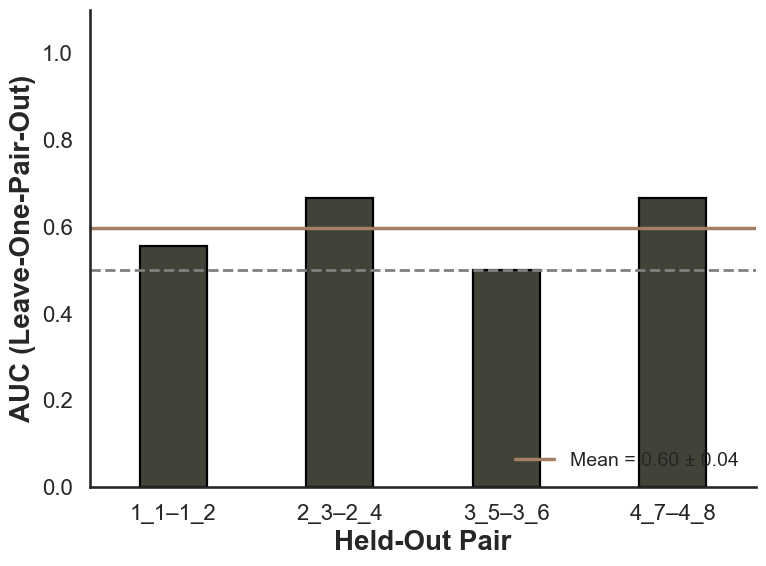

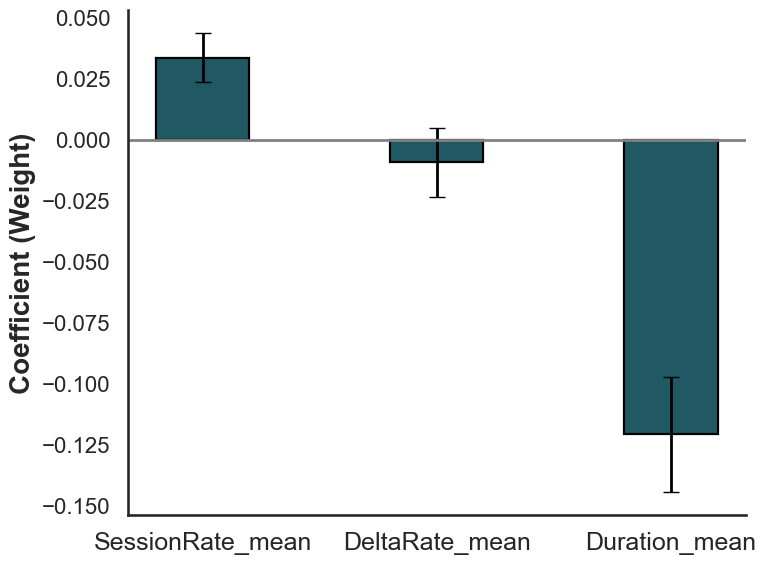

In [38]:
# --- 1️⃣ Collect AUCs + Coefficients per fold ---
aucs = []
pair_labels = []
coefs = []

print(f"Running Leave-One-Pair-Out CV on {len(pair_groups)} pairs...\n")

for pair in pair_groups:
    test_mask = np.isin(subjects, pair)
    train_mask = ~test_mask

    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]

    # Skip invalid folds
    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        print(f" Skipping pair {pair} (missing class in train/test)")
        continue

    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(C=0.1, penalty="l2", solver="liblinear")
    )
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred)
    aucs.append(auc)
    pair_labels.append(f"{pair[0]}–{pair[1]}")

    # Extract coefficients
    lr = model.named_steps['logisticregression']
    coefs.append(lr.coef_.flatten())

    print(f"Pair {pair}: AUC = {auc:.2f} | Coefs = {dict(zip(features, np.round(lr.coef_.flatten(), 3)))}")

# --- Summary ---
auc_mean = np.mean(aucs)
auc_sem = np.std(aucs) / np.sqrt(len(aucs))
print(f"\n Leave-One-Pair-Out Rank AUCs: {np.round(aucs, 3)}")
print(f"Mean Rank AUC: {auc_mean:.2f} ± {auc_sem:.2f}")

# --- 2️⃣ Plot AUC per fold ---
auc_df = pd.DataFrame({"Pair": pair_labels, "AUC": aucs})
sns.set(style="white", context="talk")
plt.figure(figsize=(8,6))

ax = sns.barplot(
    data=auc_df,
    x="Pair", y="AUC",
    color="#414535",   # Padilla lab neutral gray
    width=0.4, edgecolor="black", linewidth=1.6
)
ax.axhline(0.5, ls="--", color="gray", lw=2)
ax.axhline(auc_mean, color="#A37F64", lw=2.5,
           label=f"Mean = {auc_mean:.2f} ± {auc_sem:.2f}")
ax.legend(fontsize=14, frameon=False, loc="lower right")
ax.set_ylim(0, 1.1)
ax.set_ylabel("AUC (Leave-One-Pair-Out)", fontsize=20, fontweight="bold")
ax.set_xlabel("Held-Out Pair", fontsize=20, fontweight="bold")
ax.tick_params(axis="x", labelsize=16)
ax.tick_params(axis="y", labelsize=16)
sns.despine()
plt.tight_layout()
plt.show()

# --- 3️⃣ Plot average coefficient weights across folds ---
coefs = np.array(coefs)
coef_mean = coefs.mean(axis=0)
coef_sem = coefs.std(axis=0) / np.sqrt(len(coefs))

coef_df = pd.DataFrame({"Feature": features, "Weight": coef_mean, "SEM": coef_sem})
plt.figure(figsize=(8,6))

ax = sns.barplot(
    data=coef_df,
    x="Feature", y="Weight",
    color="#15616F",   # Padilla lab deep teal
    width=0.4, edgecolor="black", linewidth=1.6
)
ax.errorbar(x=np.arange(len(features)), y=coef_mean, yerr=coef_sem,
            fmt="none", ecolor="black", capsize=6, lw=2)
ax.axhline(0, color="gray", lw=2)
ax.set_ylabel("Coefficient (Weight)", fontsize=20, fontweight="bold")
ax.set_xlabel("", fontsize=18)
ax.tick_params(axis="x", labelsize=18)
ax.tick_params(axis="y", labelsize=16)
sns.despine()
plt.tight_layout()
plt.show()


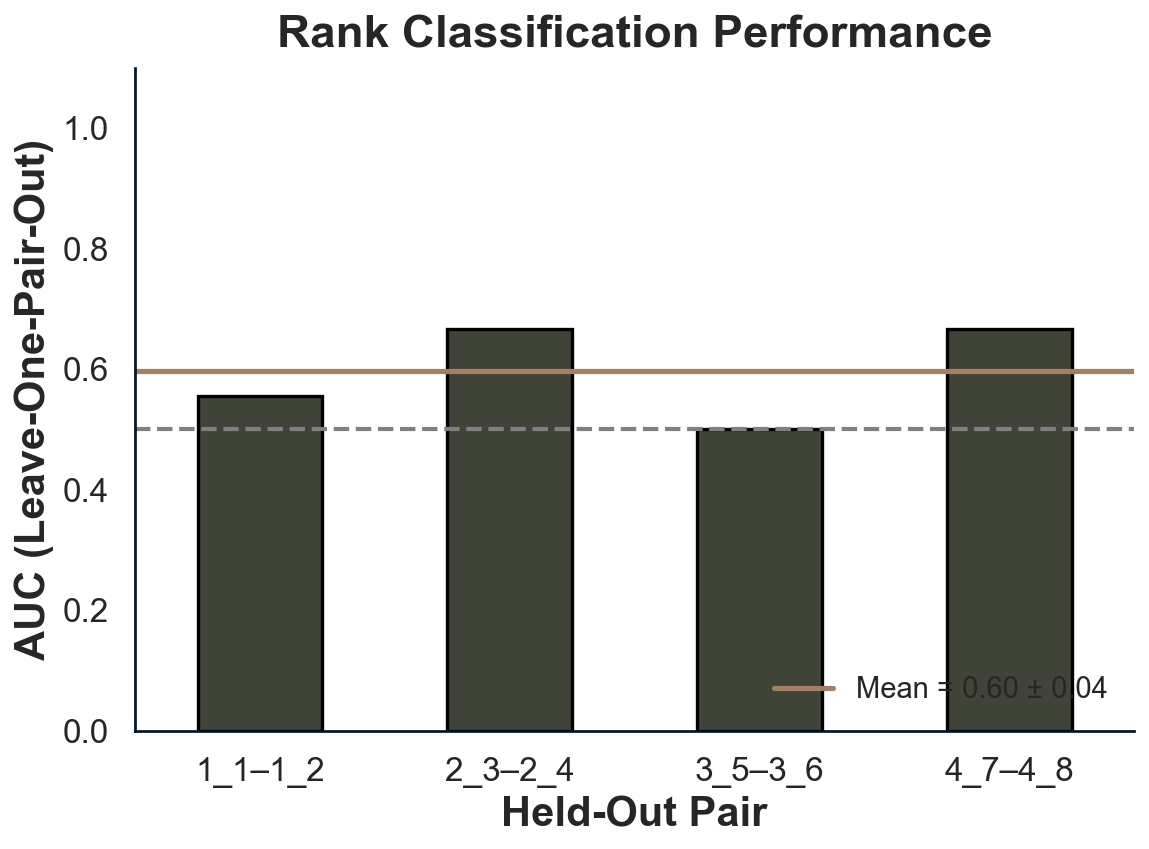

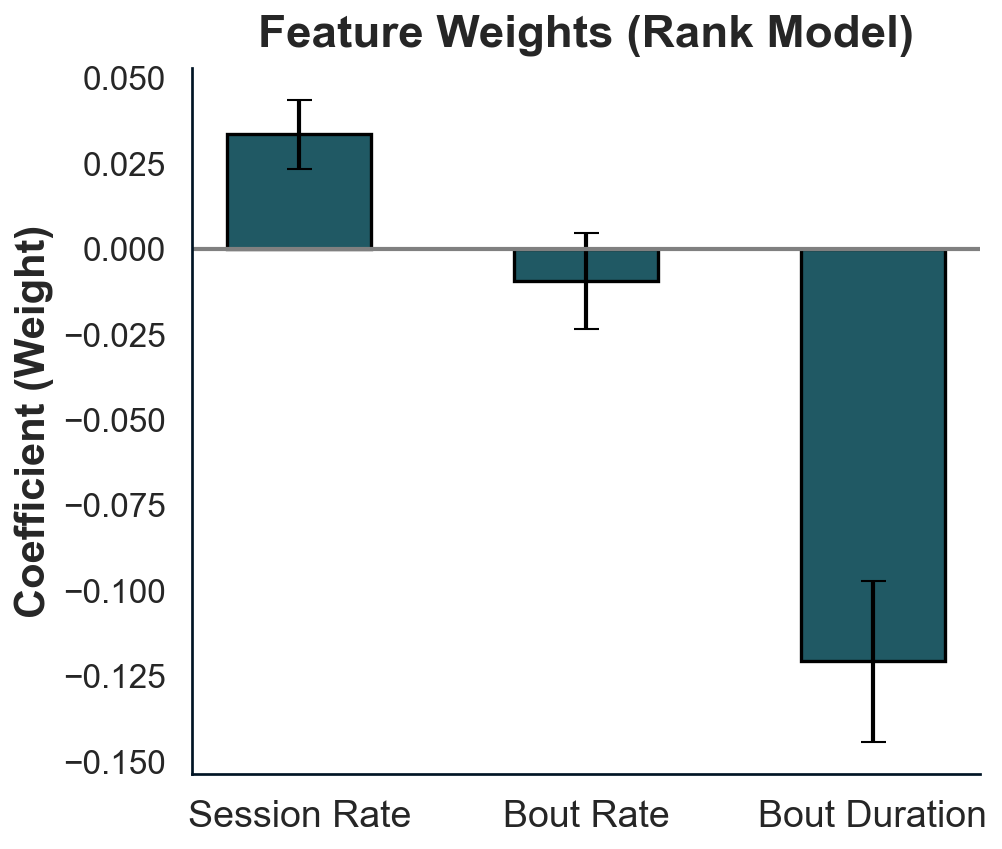

In [39]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =====================================================
# 🧠 1. AUC Bar Plot per Pair
# =====================================================

# --- Unified Padilla Lab Style ---
sns.set(style="white", context="talk")
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.3,
    "axes.edgecolor": "#001424",
    "figure.dpi": 150,
})

# --- Build AUC DataFrame ---
auc_df = pd.DataFrame({"Pair": pair_labels, "AUC": aucs})

plt.figure(figsize=(8,6))
ax = sns.barplot(
    data=auc_df,
    x="Pair", y="AUC",
    color="#414535",     # neutral gray tone
    width=0.5,
    edgecolor="black",
    linewidth=1.6
)

# --- Reference lines ---
ax.axhline(0.5, ls="--", color="gray", lw=2)
ax.axhline(
    auc_mean, color="#A37F64", lw=2.5,
    label=f"Mean = {auc_mean:.2f} ± {auc_sem:.2f}"
)

# --- Legend & labels ---
ax.legend(fontsize=14, frameon=False, loc="lower right")
ax.set_ylim(0, 1.1)
ax.set_ylabel("AUC (Leave-One-Pair-Out)", fontsize=20, fontweight="bold")
ax.set_xlabel("Held-Out Pair", fontsize=20, fontweight="bold")
ax.tick_params(axis="x", labelsize=16)
ax.tick_params(axis="y", labelsize=16)
ax.set_title("Rank Classification Performance", fontsize=22, fontweight="bold", pad=10)

sns.despine()
plt.tight_layout()
plt.show()


# =====================================================
# ⚙️ 2. Average Coefficient Weights (Poster Style)
# =====================================================

# --- Custom x-axis labels for features ---
new_labels = ["Session Rate", "Bout Rate", "Bout Duration"]
assert len(features) == len(new_labels), "Number of feature names must match!"

# --- Compute coefficient means and SEMs ---
coefs = np.array(coefs)
coef_mean = coefs.mean(axis=0)
coef_sem = coefs.std(axis=0) / np.sqrt(len(coefs))

coef_df = pd.DataFrame({
    "Feature": new_labels,
    "Weight": coef_mean,
    "SEM": coef_sem
})

# --- Plot mean ± SEM coefficients ---
plt.figure(figsize=(7,6))
ax = sns.barplot(
    data=coef_df,
    x="Feature", y="Weight",
    color="#15616F",           # deep Padilla teal
    width=0.5,
    edgecolor="black",
    linewidth=1.6
)
ax.errorbar(
    x=np.arange(len(coef_df)),
    y=coef_df["Weight"],
    yerr=coef_df["SEM"],
    fmt="none", ecolor="black", capsize=6, lw=2
)

# --- Reference line & labels ---
ax.axhline(0, color="gray", lw=2)
ax.set_ylabel("Coefficient (Weight)", fontsize=20, fontweight="bold")
ax.set_xlabel("", fontsize=18, fontweight="bold")
ax.set_title("Feature Weights (Rank Model)", fontsize=22, fontweight="bold", pad=10)
ax.tick_params(axis="x", labelsize=18)
ax.tick_params(axis="y", labelsize=16)

sns.despine()
plt.tight_layout()
plt.show()


In [40]:
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import numpy as np

# --- Filter valence data (RI1 = Positive, RI2 = Negative) ---
valence_df = session_df[session_df["Condition"].isin(["RI1", "RI2"])].dropna(subset=features).copy()
X = valence_df[features].to_numpy()
y = (valence_df["Condition"] == "RI1").astype(int).to_numpy()  # 1 = positive valence
groups = valence_df["Subject"].to_numpy()

# --- Leave-One-Subject-Out (GroupKFold with n_splits = #subjects) ---
unique_subjects = np.unique(groups)
cv = GroupKFold(n_splits=len(unique_subjects))
aucs = []

print(f"Running Leave-One-Subject-Out Valence CV on {len(unique_subjects)} subjects...\n")

for train_idx, test_idx in cv.split(X, y, groups):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Skip if one class missing in test
    if len(np.unique(y_test)) < 2:
        print("Skipping fold (test set has only one valence)")
        continue

    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(C=0.1, penalty="l2", solver="liblinear")
    )
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred)
    aucs.append(auc)

    subj = np.unique(groups[test_idx])[0]
    print(f"Subject {subj}: AUC = {auc:.2f}")

# --- Summarize ---
auc_valence_mean = np.mean(aucs)
auc_valence_sem = np.std(aucs) / np.sqrt(len(aucs))
print(f"\n Valence (RI1 vs RI2) AUCs: {np.round(aucs, 3)}")
print(f"Mean Valence AUC: {auc_valence_mean:.2f} ± {auc_valence_sem:.2f}")


Running Leave-One-Subject-Out Valence CV on 8 subjects...

Subject 4_7: AUC = 1.00
Subject 3_6: AUC = 1.00
Subject 2_4: AUC = 1.00
Subject 2_3: AUC = 1.00
Subject 1_2: AUC = 1.00
Subject 1_1: AUC = 1.00
Skipping fold (test set has only one valence)
Skipping fold (test set has only one valence)

 Valence (RI1 vs RI2) AUCs: [1. 1. 1. 1. 1. 1.]
Mean Valence AUC: 1.00 ± 0.00


Running Leave-One-Subject-Out Valence CV on 8 subjects...

Subject 4_7: AUC = 1.00 | Coefs = {'SessionRate_mean': 0.382, 'DeltaRate_mean': -0.307, 'Duration_mean': 0.014}
Subject 3_6: AUC = 1.00 | Coefs = {'SessionRate_mean': 0.381, 'DeltaRate_mean': -0.325, 'Duration_mean': -0.027}
Subject 2_4: AUC = 1.00 | Coefs = {'SessionRate_mean': 0.387, 'DeltaRate_mean': -0.304, 'Duration_mean': 0.017}
Subject 2_3: AUC = 1.00 | Coefs = {'SessionRate_mean': 0.388, 'DeltaRate_mean': -0.317, 'Duration_mean': 0.041}
Subject 1_2: AUC = 1.00 | Coefs = {'SessionRate_mean': 0.388, 'DeltaRate_mean': -0.303, 'Duration_mean': -0.062}
Subject 1_1: AUC = 1.00 | Coefs = {'SessionRate_mean': 0.371, 'DeltaRate_mean': -0.333, 'Duration_mean': -0.077}
⚠️ Skipping subject 4_8 (only one valence in test)
⚠️ Skipping subject 3_5 (only one valence in test)

🏆 Valence AUCs: [1. 1. 1. 1. 1. 1.]
Mean Valence AUC: 1.00 ± 0.00


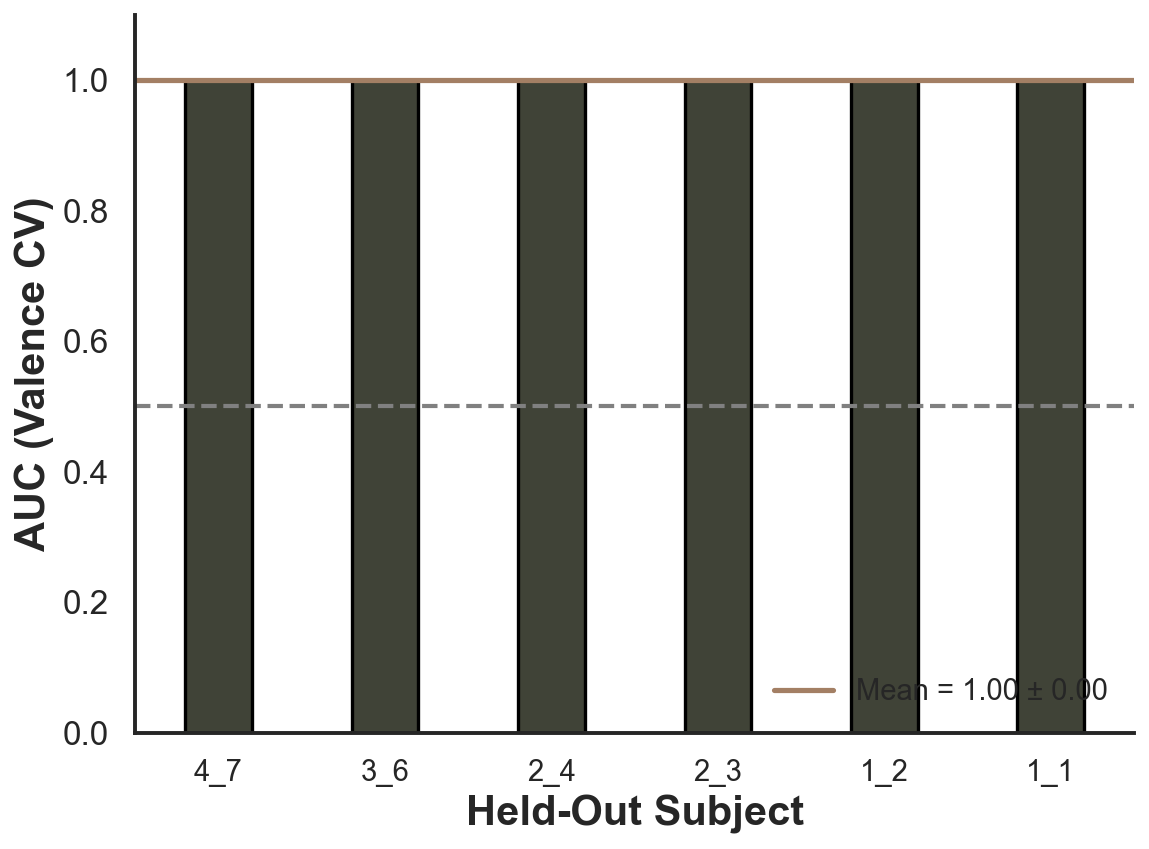

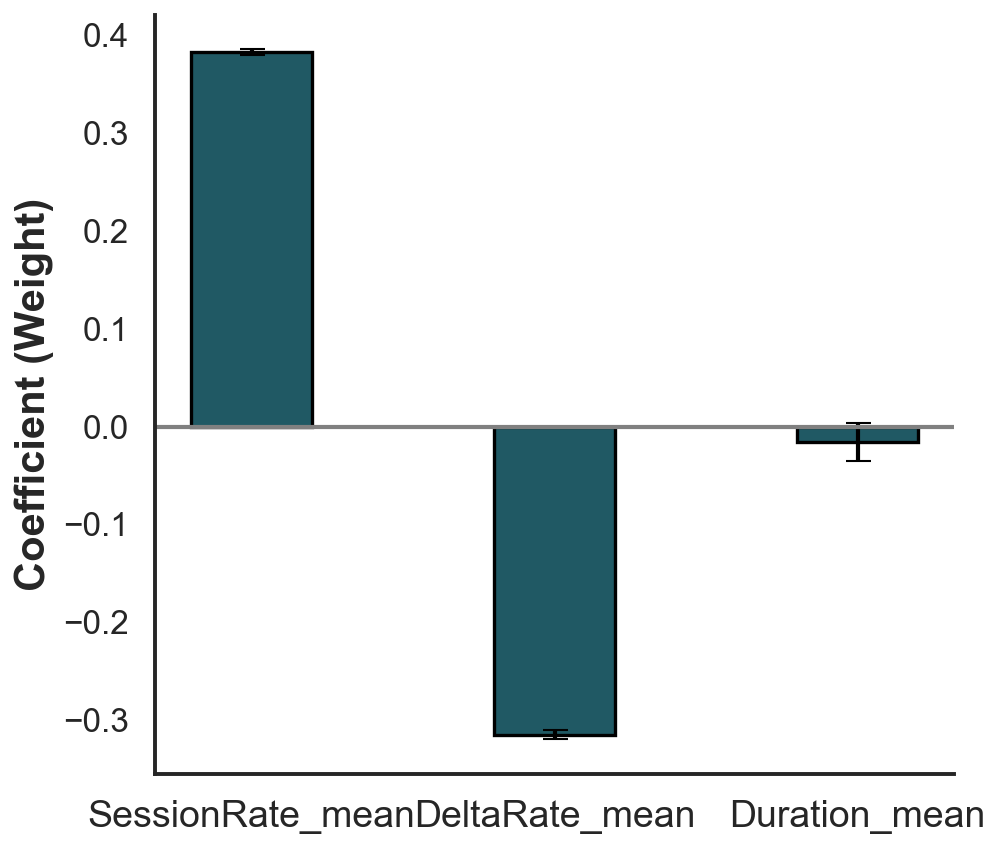

In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# --- Prepare data ---
features = ["SessionRate_mean", "DeltaRate_mean", "Duration_mean"]
valence_df = session_df[session_df["Condition"].isin(["RI1", "RI2"])].dropna(subset=features).copy()

X = valence_df[features].to_numpy()
y = (valence_df["Condition"] == "RI1").astype(int).to_numpy()  # 1 = positive valence
groups = valence_df["Subject"].to_numpy()

# --- Leave-One-Subject-Out CV ---
unique_subjects = np.unique(groups)
cv = GroupKFold(n_splits=len(unique_subjects))

aucs, subj_labels, coefs = [], [], []

print(f"Running Leave-One-Subject-Out Valence CV on {len(unique_subjects)} subjects...\n")

for train_idx, test_idx in cv.split(X, y, groups):
    subj_test = np.unique(groups[test_idx])[0]
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Skip invalid folds
    if len(np.unique(y_test)) < 2:
        print(f"⚠️ Skipping subject {subj_test} (only one valence in test)")
        continue

    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(C=0.1, penalty="l2", solver="liblinear")
    )
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred)
    aucs.append(auc)
    subj_labels.append(subj_test)

    # Save coefficients
    lr = model.named_steps["logisticregression"]
    coefs.append(lr.coef_.flatten())

    print(f"Subject {subj_test}: AUC = {auc:.2f} | Coefs = {dict(zip(features, np.round(lr.coef_.flatten(), 3)))}")

# --- Summary ---
auc_valence_mean = np.mean(aucs)
auc_valence_sem = np.std(aucs, ddof=1) / np.sqrt(len(aucs))
print(f"\n🏆 Valence AUCs: {np.round(aucs, 3)}")
print(f"Mean Valence AUC: {auc_valence_mean:.2f} ± {auc_valence_sem:.2f}")

# =====================================================
# 📊 1. AUC Bar Plot per Subject
# =====================================================
auc_df = pd.DataFrame({"Subject": subj_labels, "AUC": aucs})
sns.set(style="white", context="talk")
plt.figure(figsize=(8,6))

ax = sns.barplot(
    data=auc_df,
    x="Subject", y="AUC",
    color="#414535", width=0.4, edgecolor="black", linewidth=1.6
)
ax.axhline(0.5, ls="--", color="gray", lw=2)
ax.axhline(auc_valence_mean, color="#A37F64", lw=2.5,
           label=f"Mean = {auc_valence_mean:.2f} ± {auc_valence_sem:.2f}")
ax.legend(fontsize=14, frameon=False, loc="lower right")
ax.set_ylim(0, 1.1)
ax.set_ylabel("AUC (Valence CV)", fontsize=20, fontweight="bold")
ax.set_xlabel("Held-Out Subject", fontsize=20, fontweight="bold")
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=16)
sns.despine()
plt.tight_layout()
plt.show()

# =====================================================
# ⚙️ 2. Average Coefficient Weights
# =====================================================
coefs = np.array(coefs)
coef_mean = coefs.mean(axis=0)
coef_sem = coefs.std(axis=0, ddof=1) / np.sqrt(len(coefs))

coef_df = pd.DataFrame({"Feature": features, "Weight": coef_mean, "SEM": coef_sem})

plt.figure(figsize=(7,6))
ax = sns.barplot(
    data=coef_df,
    x="Feature", y="Weight",
    color="#15616F", width=0.4, edgecolor="black", linewidth=1.6
)
ax.errorbar(x=np.arange(len(features)), y=coef_mean, yerr=coef_sem,
            fmt="none", ecolor="black", capsize=6, lw=2)
ax.axhline(0, color="gray", lw=2)
ax.set_ylabel("Coefficient (Weight)", fontsize=20, fontweight="bold")
ax.set_xlabel("", fontsize=18)
ax.tick_params(axis="x", labelsize=18)
ax.tick_params(axis="y", labelsize=16)
sns.despine()
plt.tight_layout()
plt.show()


In [42]:
print(df_rank.columns.tolist())



['Trial', 'Subject', 'Condition', 'Rank', 'Type', 'MeanRate_mean', 'MeanRate_std', 'SessionRate_mean', 'Duration_mean', 'Duration_sum', 'N_bouts', 'DeltaRate_mean']


In [43]:
# --- Subset to cagemate (rank-related) trials ---
df_rank_resp = df[df["Condition"] == "CM"].copy()

# --- Map rank based on subject ---
rank_map = {
    "1_1": "Subordinate", "1_2": "Dominant",
    "2_3": "Subordinate", "2_4": "Dominant",
    "3_5": "Subordinate", "3_6": "Dominant",
    "4_7": "Subordinate", "4_8": "Dominant"
}
df_rank_resp["Rank"] = df_rank_resp["Subject"].map(rank_map)
df_rank_resp["RankLabel"] = (df_rank_resp["Rank"] == "Dominant").astype(int)

# --- Define features ---
features = ["SessionRate", "DeltaRate"]
X = df_rank_resp[features].to_numpy()
y = df_rank_resp["RankLabel"].to_numpy()

print(f"Rank dataset shape: {X.shape}")
print(df_rank_resp["Rank"].value_counts())


NameError: name 'df' is not defined

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import numpy as np

df_rank_resp = df_rank_resp.dropna(subset=["SessionRate", "DeltaRate"]).copy()


# --- Define features and labels ---
X = df_rank_resp[["SessionRate", "DeltaRate"]].to_numpy()
y = df_rank_resp["RankLabel"].to_numpy()

# --- Shuffle & 5-fold CV ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
aucs = []

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(C=0.1, penalty="l2", solver="liblinear")
    )
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred)
    aucs.append(auc)

print(f"\nMean AUC: {np.mean(aucs):.2f} ± {np.std(aucs)/np.sqrt(len(aucs)):.2f}")


NameError: name 'df_rank_resp' is not defined

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# ======================================================
# 🧹 1️⃣ Clean NaNs and prepare data
# ======================================================
df_rank_resp = df_rank_resp.dropna(subset=["SessionRate", "DeltaRate"]).copy()
X = df_rank_resp[["SessionRate", "DeltaRate"]].to_numpy()
y = df_rank_resp["RankLabel"].to_numpy()

# ======================================================
# 🔁 2️⃣ Shuffle-based Stratified 5-Fold CV
# ======================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
aucs = []
coefs = []

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(C=0.1, penalty="l2", solver="liblinear")
    )
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_pred)
    aucs.append(auc)

    # Save coefficients (after scaling)
    coefs.append(model.named_steps["logisticregression"].coef_[0])

auc_mean = np.mean(aucs)
auc_sem = np.std(aucs) / np.sqrt(len(aucs))

print(f"Mean AUC: {auc_mean:.2f} ± {auc_sem:.2f}")

# ======================================================
# 📊 3️⃣ Plot AUCs per fold (poster-ready)
# ======================================================
sns.set(style="white", context="talk")
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.3,
    "axes.edgecolor": "#001424",
    "figure.dpi": 150,
})

auc_df = pd.DataFrame({"Fold": np.arange(1, len(aucs)+1), "AUC": aucs})

plt.figure(figsize=(7,6))
ax = sns.barplot(
    data=auc_df,
    x="Fold", y="AUC",
    color="#414535",   # neutral gray tone
    width=0.5,
    edgecolor="black",
    linewidth=1.4
)
ax.axhline(0.5, ls="--", color="gray", lw=2)
ax.axhline(auc_mean, color="#A37F64", lw=2.5,
           label=f"Mean = {auc_mean:.2f} ± {auc_sem:.2f}")
ax.legend(fontsize=13, frameon=False, loc="lower right")

ax.set_ylim(0, 1.05)
ax.set_ylabel("AUC (Shuffle 5-Fold CV)", fontsize=18, fontweight="bold")
ax.set_xlabel("Fold", fontsize=18, fontweight="bold")
ax.set_title("Rank Classification Performance", fontsize=20, fontweight="bold", pad=10)
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)
sns.despine()
plt.tight_layout()
plt.show()

# ======================================================
# ⚙️ 4️⃣ Plot mean ± SEM of coefficient weights
# ======================================================
features = ["SessionRate", "DeltaRate"]
new_labels = ["Session Rate", "ΔRate (Bout–Session)"]

coefs = np.array(coefs)
coef_mean = coefs.mean(axis=0)
coef_sem = coefs.std(axis=0) / np.sqrt(len(coefs))

coef_df = pd.DataFrame({"Feature": new_labels, "Weight": coef_mean, "SEM": coef_sem})

plt.figure(figsize=(6,6))
ax = sns.barplot(
    data=coef_df,
    x="Feature", y="Weight",
    color="#15616F",  # deep Padilla teal
    width=0.5,
    edgecolor="black",
    linewidth=1.4
)
ax.errorbar(
    x=np.arange(len(coef_df)),
    y=coef_df["Weight"],
    yerr=coef_df["SEM"],
    fmt="none", ecolor="black", capsize=6, lw=2
)

ax.axhline(0, color="gray", lw=2)
ax.set_ylabel("Coefficient (Weight)", fontsize=18, fontweight="bold")
ax.set_xlabel("", fontsize=18, fontweight="bold")
ax.set_title("Feature Weights (Rank Model)", fontsize=20, fontweight="bold", pad=10)
ax.tick_params(axis="x", labelsize=16)
ax.tick_params(axis="y", labelsize=14)
sns.despine()
plt.tight_layout()
plt.show()


NameError: name 'df_rank_resp' is not defined

Mean AUC: 0.75 ± 0.04


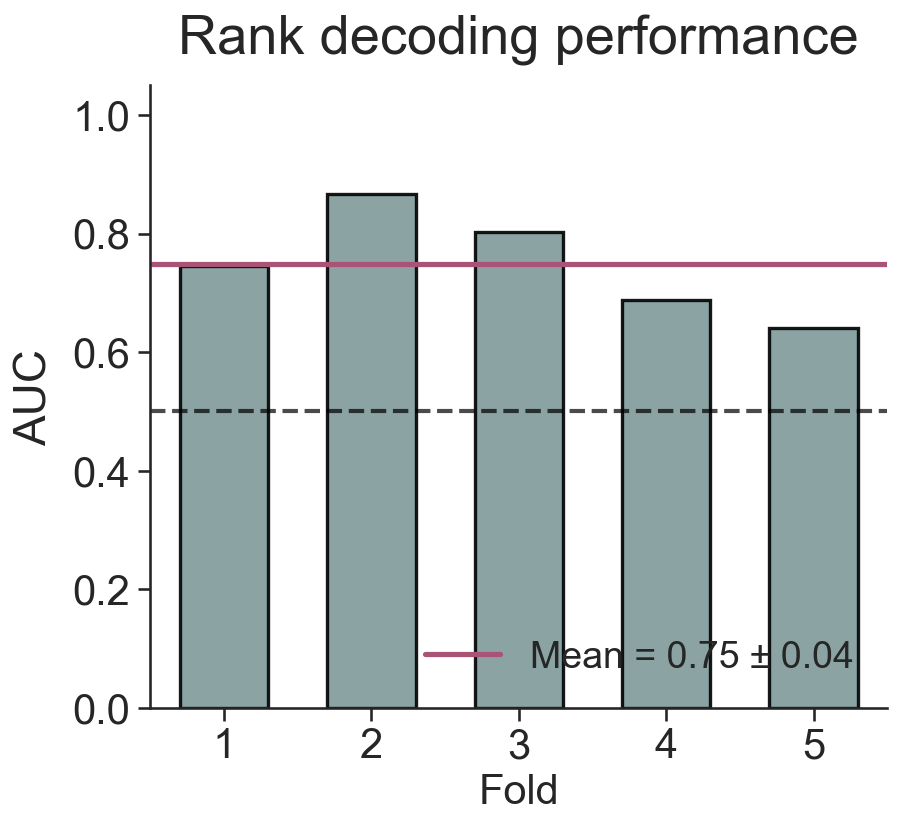

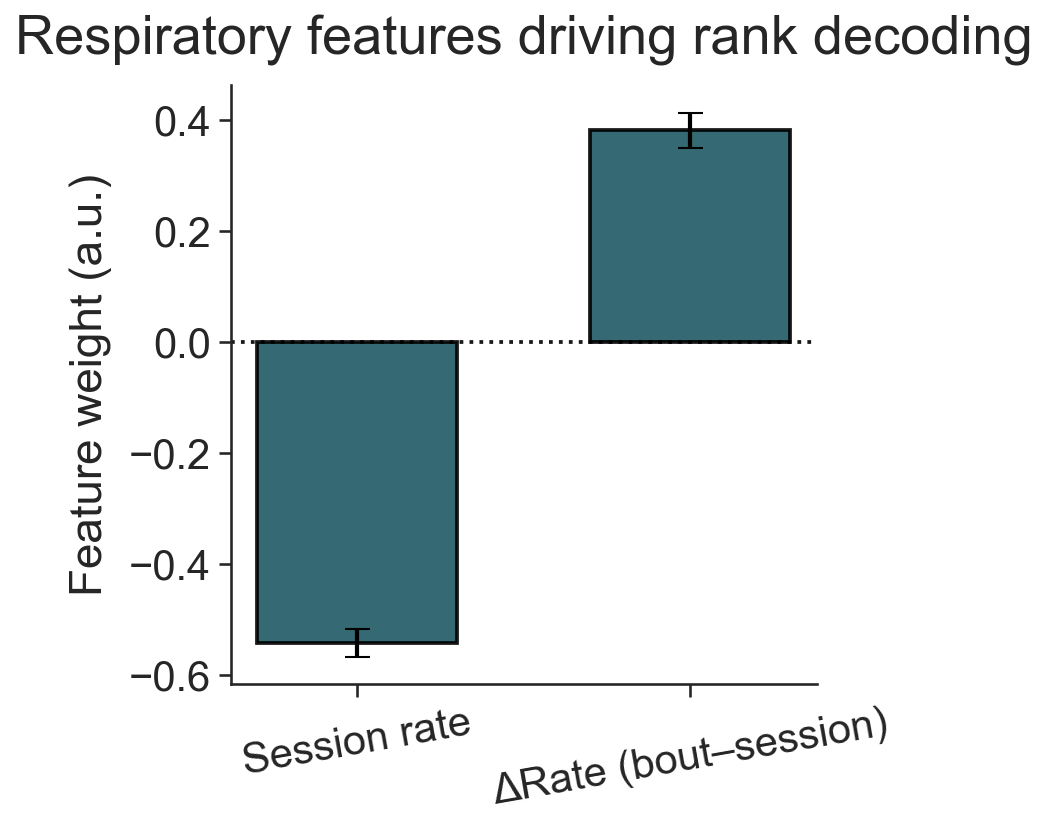

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# ======================================================
# 1️⃣ Prepare and train logistic regression (Rank decoding)
# ======================================================
df_rank_resp = df_rank_resp.dropna(subset=["SessionRate", "DeltaRate"]).copy()
X = df_rank_resp[["SessionRate", "DeltaRate"]].to_numpy()
y = df_rank_resp["RankLabel"].to_numpy()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
aucs, coefs = [], []

for train_idx, test_idx in skf.split(X, y):
    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(C=0.1, penalty="l2", solver="liblinear")
    )
    model.fit(X[train_idx], y[train_idx])
    y_pred = model.predict_proba(X[test_idx])[:, 1]
    aucs.append(roc_auc_score(y[test_idx], y_pred))
    coefs.append(model.named_steps["logisticregression"].coef_[0])

auc_mean = np.mean(aucs)
auc_sem = np.std(aucs) / np.sqrt(len(aucs))
print(f"Mean AUC: {auc_mean:.2f} ± {auc_sem:.2f}")

# ======================================================
# 2️⃣ Poster-style: AUC per fold
# ======================================================
sns.set(style="ticks", font_scale=1.9)
fig, ax = plt.subplots(figsize=(6.5, 6))
fig.patch.set_alpha(0.0)
ax.set_facecolor("none")

auc_df = pd.DataFrame({"Fold": np.arange(1, len(aucs) + 1), "AUC": aucs})

# --- Bars ---
sns.barplot(
    data=auc_df, x="Fold", y="AUC",
    color="#7A9E9F", edgecolor="black", linewidth=1.6,
    width=0.6, alpha=0.9, ax=ax
)

# --- Mean and chance lines ---
ax.axhline(0.5, ls="--", color="black", lw=2, alpha=0.7)
ax.axhline(auc_mean, color="#A95376", lw=2.5, label=f"Mean = {auc_mean:.2f} ± {auc_sem:.2f}")

# --- Style ---
ax.set_ylim(0, 1.05)
ax.set_ylabel("AUC", fontsize=22, labelpad=8)
ax.set_xlabel("Fold", fontsize=20)
ax.set_title("Rank decoding performance", fontsize=26, pad=15, weight="normal")
ax.legend(frameon=False, fontsize=18, loc="lower right")
ax.tick_params(axis="x", labelsize=20)
ax.tick_params(axis="y", labelsize=20)
sns.despine()
plt.tight_layout()
plt.show()

# ======================================================
# 3️⃣ Poster-style: Coefficient weights
# ======================================================
features = ["SessionRate", "DeltaRate"]
new_labels = ["Session rate", "ΔRate (bout–session)"]

coefs = np.array(coefs)
coef_mean = coefs.mean(axis=0)
coef_sem = coefs.std(axis=0) / np.sqrt(len(coefs))
coef_df = pd.DataFrame({"Feature": new_labels, "Weight": coef_mean, "SEM": coef_sem})

fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_alpha(0.0)
ax.set_facecolor("none")

# --- Bars (centered around zero) ---
sns.barplot(
    data=coef_df,
    x="Feature", y="Weight",
    color="#15616F", edgecolor="black", linewidth=1.8,
    width=0.6, alpha=0.9, ax=ax
)

# --- Error bars ---
ax.errorbar(
    x=np.arange(len(coef_df)), y=coef_df["Weight"], yerr=coef_df["SEM"],
    fmt="none", ecolor="black", elinewidth=2, capsize=6
)

# --- Baseline ---
ax.axhline(0, color="black", lw=1.8, linestyle="dotted", alpha=0.9)

# --- Axes ---
ax.set_ylabel("Feature weight (a.u.)", fontsize=22, labelpad=8)
ax.set_xlabel("", fontsize=20)
ax.set_title("Respiratory features driving rank decoding", fontsize=26, pad=15, weight="normal")
ax.tick_params(axis="x", labelrotation=10, labelsize=20)
ax.tick_params(axis="y", labelsize=20)
sns.despine()
plt.tight_layout()
plt.show()


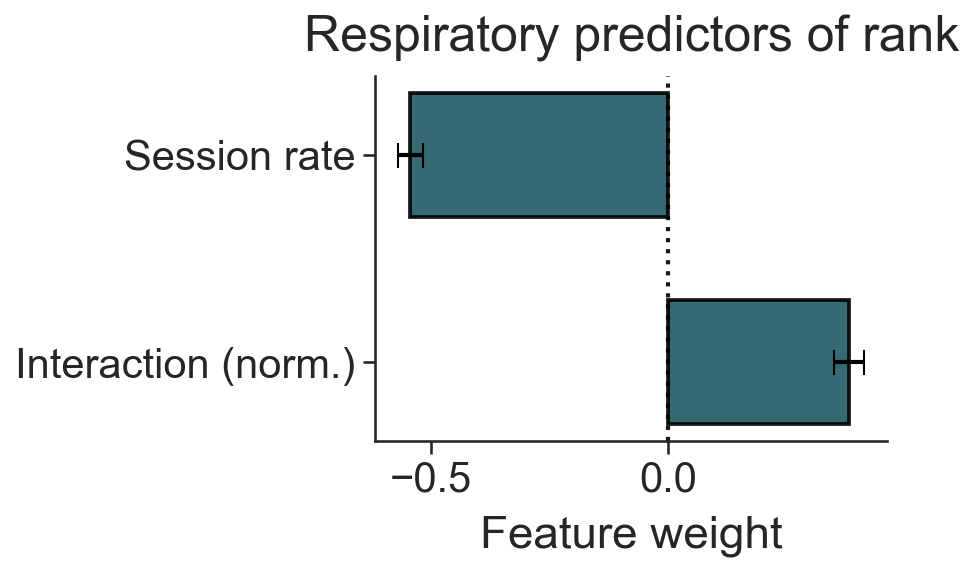

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ======================================================
# 🧩 Poster-style Coefficient Plot (compact labels)
# ======================================================
features = ["SessionRate", "DeltaRate"]
new_labels = ["Session rate", "Interaction (norm.)"]  # shorter & balanced

coefs = np.array(coefs)
coef_mean = coefs.mean(axis=0)
coef_sem = coefs.std(axis=0) / np.sqrt(len(coefs))

coef_df = pd.DataFrame({
    "Feature": new_labels,
    "Weight": coef_mean,
    "SEM": coef_sem
})

# --- Unified poster visual style ---
sns.set(style="ticks", font_scale=1.9)
fig, ax = plt.subplots(figsize=(6.5, 4.3))
fig.patch.set_alpha(0.0)
ax.set_facecolor("none")

# --- Horizontal barplot ---
sns.barplot(
    data=coef_df,
    y="Feature", x="Weight",
    color="#15616F", edgecolor="black",
    linewidth=1.8, orient="h", width=0.6, alpha=0.9, ax=ax
)

# --- Error bars ---
ax.errorbar(
    y=np.arange(len(coef_df)),
    x=coef_df["Weight"],
    xerr=coef_df["SEM"],
    fmt="none", ecolor="black",
    elinewidth=2, capsize=6
)

# --- Vertical zero line ---
ax.axvline(0, color="black", lw=2, linestyle="dotted", alpha=0.9)

# --- Clean, concise labels ---
ax.set_xlabel("Feature weight", fontsize=22, labelpad=8)
ax.set_ylabel("", fontsize=20)
ax.set_title("Respiratory predictors of rank", fontsize=24, pad=12, weight="normal")

# --- Ticks ---
ax.tick_params(axis="x", labelsize=20)
ax.tick_params(axis="y", labelsize=20)

sns.despine()
plt.tight_layout()
plt.show()


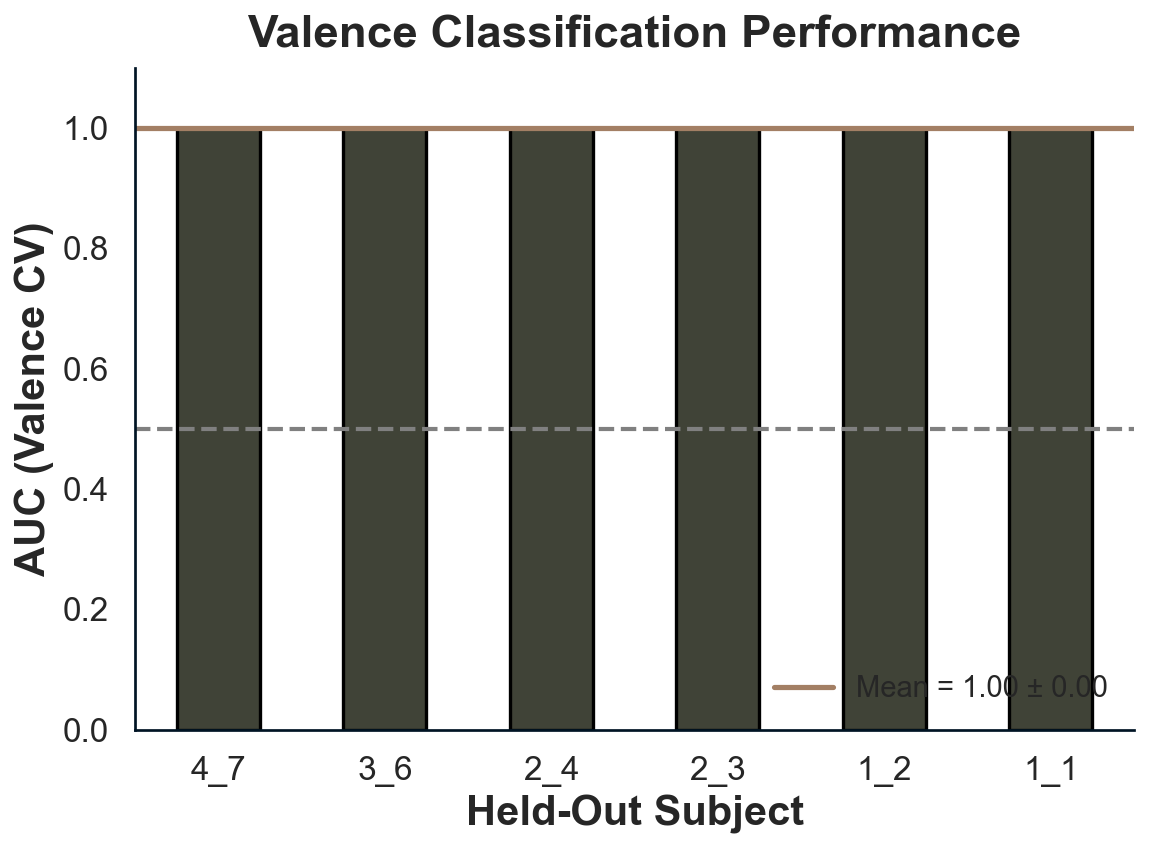

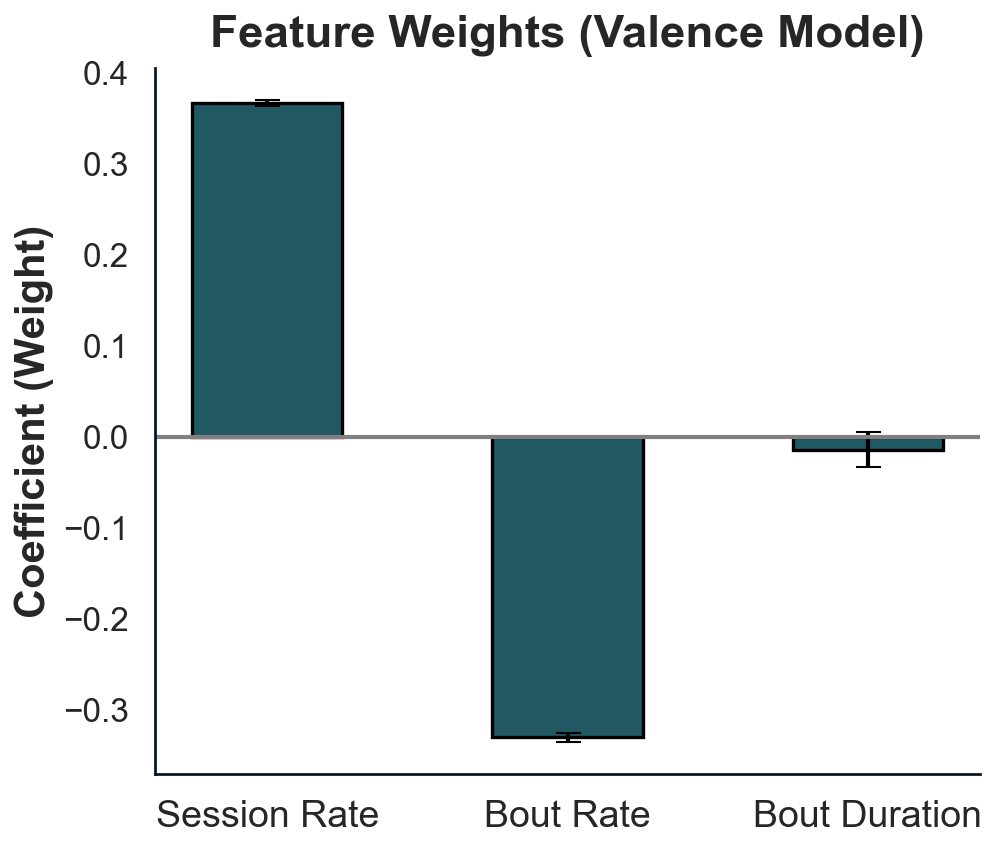

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =====================================================
# 📊 1. AUC Bar Plot per Subject — Padilla Style
# =====================================================

# --- Shared style (matching your poster plots) ---
sns.set(style="white", context="talk")
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.3,
    "axes.edgecolor": "#001424",
    "figure.dpi": 150,
})

# --- Build AUC DataFrame ---
auc_df = pd.DataFrame({"Subject": subj_labels, "AUC": aucs})

plt.figure(figsize=(8,6))
ax = sns.barplot(
    data=auc_df,
    x="Subject", y="AUC",
    color="#414535",          # neutral gray tone
    width=0.5,
    edgecolor="black",
    linewidth=1.6
)

# --- Reference & mean lines ---
ax.axhline(0.5, ls="--", color="gray", lw=2)
ax.axhline(
    auc_valence_mean, color="#A37F64", lw=2.5,
    label=f"Mean = {auc_valence_mean:.2f} ± {auc_valence_sem:.2f}"
)

# --- Legend & labels ---
ax.legend(fontsize=14, frameon=False, loc="lower right")
ax.set_ylim(0, 1.1)
ax.set_ylabel("AUC (Valence CV)", fontsize=20, fontweight="bold")
ax.set_xlabel("Held-Out Subject", fontsize=20, fontweight="bold")
ax.tick_params(axis="x", labelsize=16)
ax.tick_params(axis="y", labelsize=16)
ax.set_title("Valence Classification Performance", fontsize=22, fontweight="bold", pad=10)

sns.despine()
plt.tight_layout()
plt.show()


# =====================================================
# ⚙️ 2. Average Coefficient Weights — Padilla Style
# =====================================================

# --- Custom feature display names ---
new_labels = ["Session Rate", "Bout Rate", "Bout Duration"]
assert len(features) == len(new_labels), "Feature label mismatch!"

# --- Build coefficient DataFrame ---
coefs = np.array(coefs)
coef_mean = coefs.mean(axis=0)
coef_sem = coefs.std(axis=0, ddof=1) / np.sqrt(len(coefs))

coef_df = pd.DataFrame({
    "Feature": new_labels,
    "Weight": coef_mean,
    "SEM": coef_sem
})

# --- Plot mean ± SEM coefficients ---
plt.figure(figsize=(7,6))
ax = sns.barplot(
    data=coef_df,
    x="Feature", y="Weight",
    color="#15616F",           # deep Padilla teal
    width=0.5,
    edgecolor="black",
    linewidth=1.6
)
ax.errorbar(
    x=np.arange(len(coef_df)),
    y=coef_df["Weight"],
    yerr=coef_df["SEM"],
    fmt="none", ecolor="black", capsize=6, lw=2
)

# --- Reference line & labels ---
ax.axhline(0, color="gray", lw=2)
ax.set_ylabel("Coefficient (Weight)", fontsize=20, fontweight="bold")
ax.set_xlabel("", fontsize=18, fontweight="bold")
ax.set_title("Feature Weights (Valence Model)", fontsize=22, fontweight="bold", pad=10)
ax.tick_params(axis="x", labelsize=18)
ax.tick_params(axis="y", labelsize=16)

sns.despine()
plt.tight_layout()
plt.show()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_16632\665984581.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\sjs93\AppData\Local\Temp\ipykernel_16632\665984581.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
C:\Users\sjs93\AppData\Local\Temp\ipykernel_16632\665984581.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\sjs93\AppData\Local\Temp\ipykernel_16632\665984581.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue

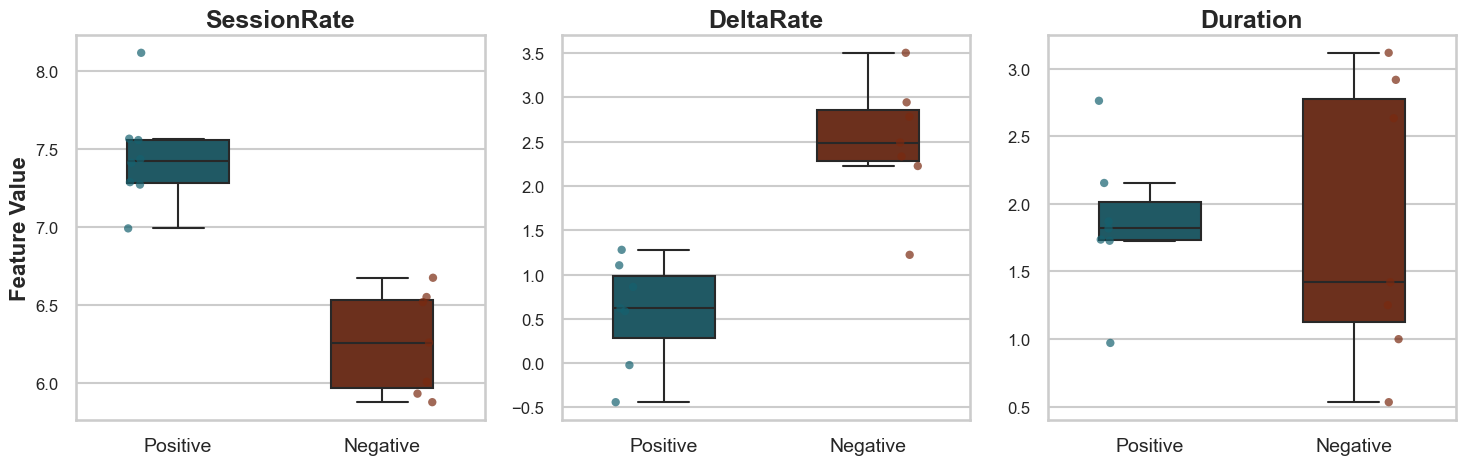

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Subset valence data ---
valence_df = session_df[session_df["Condition"].isin(["RI1", "RI2"])].copy()
valence_df["Valence"] = valence_df["Condition"].replace({"RI1": "Positive", "RI2": "Negative"})

features = ["SessionRate_mean", "DeltaRate_mean", "Duration_mean"]

# --- Padilla Lab colors (distinct from Pos/Neg used elsewhere) ---
palette = {"Positive": "#15616F", "Negative": "#792910"}  # teal & rust

sns.set(style="whitegrid", context="talk")

# --- Create 1x3 layout ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, feat in zip(axes, features):
    sns.boxplot(
        data=valence_df,
        x="Valence", y=feat,
        palette=palette,
        width=0.5, fliersize=0, linewidth=1.5, ax=ax
    )
    sns.stripplot(
        data=valence_df,
        x="Valence", y=feat,
        palette=palette,
        dodge=True, size=6, alpha=0.7, ax=ax
    )
    ax.set_title(feat.replace("_mean", "").replace("_", " "), fontsize=18, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", labelsize=14)
    ax.tick_params(axis="y", labelsize=12)

axes[0].set_ylabel("Feature Value", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.utils import Bunch

# --- Store fold coefficients ---
coef_list = []
feature_names = features

print("\n📊 Fold-wise logistic regression coefficients (Valence model):\n")

for train_idx, test_idx in cv.split(X, y, groups):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Skip folds missing one class
    if len(np.unique(y_test)) < 2:
        continue

    pipe = make_pipeline(
        StandardScaler(),
        LogisticRegression(C=0.1, penalty="l2", solver="liblinear")
    )
    pipe.fit(X_train, y_train)

    # Get coefficients (from logistic regression step)
    lr = pipe.named_steps['logisticregression']
    coef = lr.coef_.flatten()
    coef_list.append(coef)

    subj = np.unique(groups[test_idx])[0]
    print(f"Subject {subj}: {dict(zip(feature_names, np.round(coef, 3)))}")

# --- Average weights across folds ---
if coef_list:
    coef_mean = np.mean(coef_list, axis=0)
    coef_sem = np.std(coef_list, axis=0) / np.sqrt(len(coef_list))

    coef_summary = pd.DataFrame({
        "Feature": feature_names,
        "Mean Weight": coef_mean,
        "SEM": coef_sem
    })

    print("\n🏁 Mean Logistic Regression Coefficients Across Subjects:")
    print(coef_summary.to_string(index=False, float_format="%.3f"))
else:
    print("\n⚠️ No valid folds to compute coefficients.")



📊 Fold-wise logistic regression coefficients (Valence model):

Subject 4_7: {'SessionRate_mean': 0.368, 'DeltaRate_mean': -0.322, 'Duration_mean': 0.016}
Subject 3_6: {'SessionRate_mean': 0.368, 'DeltaRate_mean': -0.336, 'Duration_mean': -0.024}
Subject 2_4: {'SessionRate_mean': 0.373, 'DeltaRate_mean': -0.318, 'Duration_mean': 0.018}
Subject 2_3: {'SessionRate_mean': 0.374, 'DeltaRate_mean': -0.331, 'Duration_mean': 0.04}
Subject 1_2: {'SessionRate_mean': 0.37, 'DeltaRate_mean': -0.325, 'Duration_mean': -0.06}
Subject 1_1: {'SessionRate_mean': 0.353, 'DeltaRate_mean': -0.351, 'Duration_mean': -0.074}

🏁 Mean Logistic Regression Coefficients Across Subjects:
         Feature  Mean Weight   SEM
SessionRate_mean        0.368 0.003
  DeltaRate_mean       -0.331 0.004
   Duration_mean       -0.014 0.017


In [ ]:
# --- Build clean AUC dataframe ---
valid_subjects = []
for train_idx, test_idx in cv.split(X, y, groups):
    y_test = y[test_idx]
    subj = np.unique(groups[test_idx])[0]
    if len(np.unique(y_test)) < 2:
        continue  # skipped folds
    valid_subjects.append(subj)

auc_df = pd.DataFrame({
    "Subject": valid_subjects,
    "AUC": aucs
})

print("\n✅ AUC summary table:")
print(auc_df)



✅ AUC summary table:
  Subject  AUC
0     4_7  1.0
1     3_6  1.0
2     2_4  1.0
3     2_3  1.0
4     1_2  1.0
5     1_1  1.0


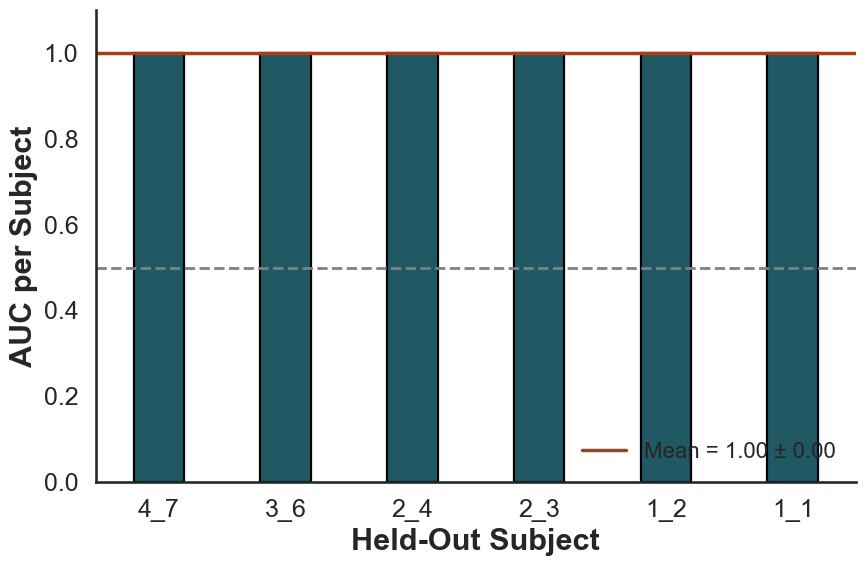

In [ ]:
# --- 2️⃣ Plot settings ---
sns.set(style="white", context="talk")
plt.figure(figsize=(9, 6))

# --- 3️⃣ Plot subject-wise AUCs ---
ax = sns.barplot(
    data=auc_df,
    x="Subject",
    y="AUC",
    color="#15616F",  # Padilla lab deep teal
    width=0.4,
    edgecolor="black",
    linewidth=1.6
)

# --- 4️⃣ Add chance line and mean ± SEM ---
mean_auc = np.mean(auc_df["AUC"])
sem_auc = np.std(auc_df["AUC"]) / np.sqrt(len(auc_df))

ax.axhline(0.5, ls="--", color="gray", lw=2)
ax.axhline(mean_auc, color="#9C4221", lw=2.5, label=f"Mean = {mean_auc:.2f} ± {sem_auc:.2f}")
ax.legend(fontsize=16, frameon=False, loc="lower right")

# --- 5️⃣ Format ---
ax.set_ylim(0, 1.1)
ax.set_ylabel("AUC per Subject", fontsize=22, fontweight="bold")
ax.set_xlabel("Held-Out Subject", fontsize=22, fontweight="bold")
ax.tick_params(axis="x", labelsize=18)
ax.tick_params(axis="y", labelsize=18)
sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
# --- Features to use (consistent across models) ---
features = ["SessionRate_mean", "DeltaRate_mean", "Duration_mean"]

# --- 1️⃣ Train on Valence (RI1 vs RI2) ---
train_df = session_df[session_df["Condition"].isin(["RI1", "RI2"])].dropna(subset=features).copy()
X_train = train_df[features].to_numpy()
y_train = (train_df["Condition"] == "RI1").astype(int).to_numpy()  # 1 = Positive valence

# --- 2️⃣ Test on Rank conditions (CM, BL, BLRI) ---
test_df = session_df[session_df["Condition"].isin(["CM", "BL", "BLRI"])].dropna(subset=features).copy()
X_test = test_df[features].to_numpy()
y_test = (test_df["Rank"] == "Dominant").astype(int).to_numpy()  # 1 = Dominant rank

# --- 3️⃣ Standardize using *valence* stats ---
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 4️⃣ Train base model ---
model = LogisticRegression(C=0.1, penalty="l2", solver="liblinear")
model.fit(X_train_scaled, y_train)

# --- 5️⃣ Predict rank (dominant vs subordinate) ---
y_pred = model.predict_proba(X_test_scaled)[:, 1]
auc_transfer = roc_auc_score(y_test, y_pred)

print(f"🎯 Single Valence → Rank transfer AUC: {auc_transfer:.2f}")

# --- 6️⃣ Compute SEM via bootstrap resampling ---
n_boot = 1000
aucs_boot = []

rng = np.random.default_rng(42)
for _ in range(n_boot):
    idx = rng.integers(0, len(y_test), len(y_test))
    y_true_bs = y_test[idx]
    y_pred_bs = y_pred[idx]
    # only compute if both classes present in bootstrap sample
    if len(np.unique(y_true_bs)) == 2:
        aucs_boot.append(roc_auc_score(y_true_bs, y_pred_bs))

auc_transfer_mean = np.mean(aucs_boot)
auc_transfer_sem = np.std(aucs_boot, ddof=1) / np.sqrt(len(aucs_boot))

print(f"🏆 Bootstrapped Mean AUC: {auc_transfer_mean:.2f} ± {auc_transfer_sem:.2f} (SEM, n={len(aucs_boot)})")


🎯 Single Valence → Rank transfer AUC: 0.25
🏆 Bootstrapped Mean AUC: 0.25 ± 0.01 (SEM, n=979)


Running Leave-One-Subject-Out Valence→Rank CV on 8 subjects...

Subject 4_7: Valence AUC = 1.00, Transfer AUC = 0.17
Subject 3_6: Valence AUC = 1.00, Transfer AUC = 0.33
Subject 2_4: Valence AUC = 1.00, Transfer AUC = 0.17
Subject 2_3: Valence AUC = 1.00, Transfer AUC = 0.17
Subject 1_2: Valence AUC = 1.00, Transfer AUC = 0.42
Subject 1_1: Valence AUC = 1.00, Transfer AUC = 0.42
⚠️ Skipping subject 4_8 (only one valence in test set)
⚠️ Skipping subject 3_5 (only one valence in test set)

🏆 Results Summary
Valence (RI1 vs RI2): 1.00 ± 0.00
Valence→Rank transfer: 0.28 ± 0.05


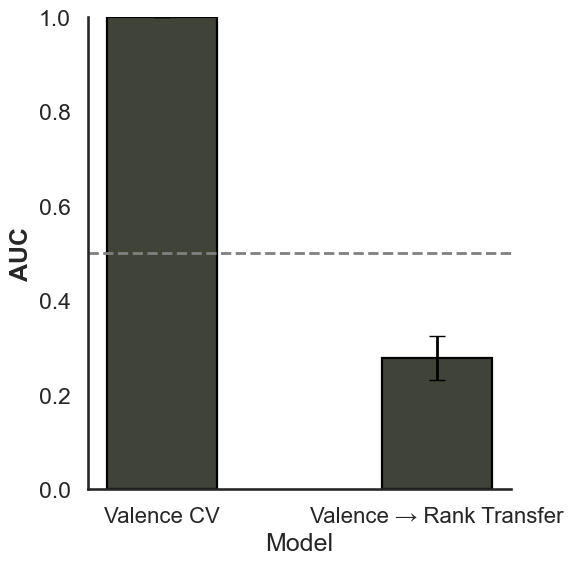

In [ ]:
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd

# --- Define features ---
features = ["SessionRate_mean", "DeltaRate_mean", "Duration_mean"]

# --- Filter valence and rank data ---
valence_df = session_df[session_df["Condition"].isin(["RI1", "RI2"])].dropna(subset=features).copy()
rank_df = session_df[session_df["Condition"].isin(["CM", "BL", "BLRI"])].dropna(subset=features).copy()

# --- Setup arrays ---
X_val = valence_df[features].to_numpy()
y_val = (valence_df["Condition"] == "RI1").astype(int).to_numpy()  # 1 = Positive Valence
groups = valence_df["Subject"].to_numpy()

X_rank = rank_df[features].to_numpy()
y_rank = (rank_df["Rank"] == "Dominant").astype(int).to_numpy()  # 1 = Dominant Rank

# --- Cross-validation setup ---
unique_subjects = np.unique(groups)
cv = GroupKFold(n_splits=len(unique_subjects))

valence_aucs = []
transfer_aucs = []
coefs = []

print(f"Running Leave-One-Subject-Out Valence→Rank CV on {len(unique_subjects)} subjects...\n")

for train_idx, test_idx in cv.split(X_val, y_val, groups):
    subj_test = np.unique(groups[test_idx])[0]

    X_train, X_test_val = X_val[train_idx], X_val[test_idx]
    y_train, y_test_val = y_val[train_idx], y_val[test_idx]

    # Skip folds with one class
    if len(np.unique(y_test_val)) < 2:
        print(f"⚠️ Skipping subject {subj_test} (only one valence in test set)")
        continue

    # Build + train model
    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(C=0.1, penalty="l2", solver="liblinear")
    )
    model.fit(X_train, y_train)

    # Predict within valence
    y_pred_val = model.predict_proba(X_test_val)[:, 1]
    auc_val = roc_auc_score(y_test_val, y_pred_val)
    valence_aucs.append(auc_val)

    # Predict on rank data (transfer)
    y_pred_rank = model.predict_proba(X_rank)[:, 1]
    auc_rank = roc_auc_score(y_rank, y_pred_rank)
    transfer_aucs.append(auc_rank)

    # Store coefficients
    lr = model.named_steps["logisticregression"]
    coefs.append(lr.coef_.flatten())

    print(f"Subject {subj_test}: Valence AUC = {auc_val:.2f}, Transfer AUC = {auc_rank:.2f}")

# --- Summarize results ---
val_mean = np.mean(valence_aucs)
val_sem = np.std(valence_aucs) / np.sqrt(len(valence_aucs))

transfer_mean = np.mean(transfer_aucs)
transfer_sem = np.std(transfer_aucs) / np.sqrt(len(transfer_aucs))

print("\n🏆 Results Summary")
print(f"Valence (RI1 vs RI2): {val_mean:.2f} ± {val_sem:.2f}")
print(f"Valence→Rank transfer: {transfer_mean:.2f} ± {transfer_sem:.2f}")

# --- Plot results ---
import matplotlib.pyplot as plt
import seaborn as sns

auc_df = pd.DataFrame({
    "Model": ["Valence CV", "Valence → Rank Transfer"],
    "AUC": [val_mean, transfer_mean],
    "SEM": [val_sem, transfer_sem]
})

sns.set(style="white", context="talk")
plt.figure(figsize=(6, 6))
ax = sns.barplot(
    data=auc_df,
    x="Model", y="AUC",
    color="#414535", width=0.4, edgecolor="black", linewidth=1.6
)
ax.errorbar(x=np.arange(2), y=auc_df["AUC"], yerr=auc_df["SEM"],
            fmt="none", ecolor="black", capsize=6, lw=2)
ax.axhline(0.5, ls="--", color="gray", lw=2)
ax.set_ylim(0, 1)
ax.set_ylabel("AUC", fontsize=18, fontweight="bold")
ax.tick_params(axis="x", labelsize=16)
sns.despine()
plt.tight_layout()
plt.show()


Running Leave-One-Subject-Out Valence→Rank CV on 8 subjects...

Subject 4_7: Valence AUC = 1.00, Transfer AUC = 0.17
Subject 3_6: Valence AUC = 1.00, Transfer AUC = 0.33
Subject 2_4: Valence AUC = 1.00, Transfer AUC = 0.17
Subject 2_3: Valence AUC = 1.00, Transfer AUC = 0.17
Subject 1_2: Valence AUC = 1.00, Transfer AUC = 0.42
Subject 1_1: Valence AUC = 1.00, Transfer AUC = 0.42
⚠️ Skipping subject 4_8 (only one valence in test set)
⚠️ Skipping subject 3_5 (only one valence in test set)

🏆 Results Summary
Valence (RI1 vs RI2): 1.00 ± 0.00
Valence→Rank transfer: 0.28 ± 0.05


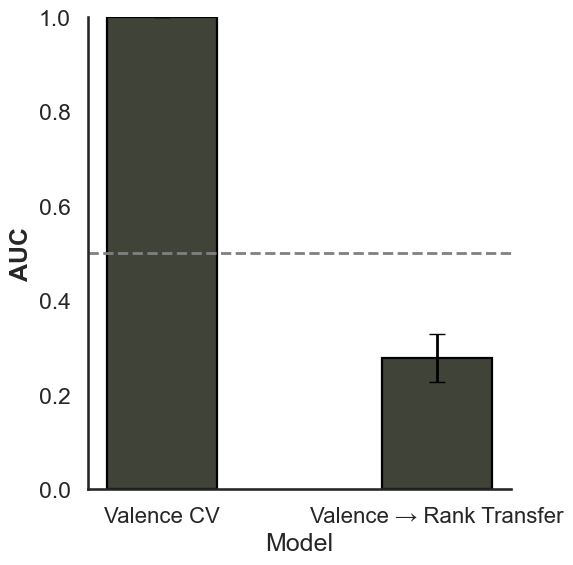

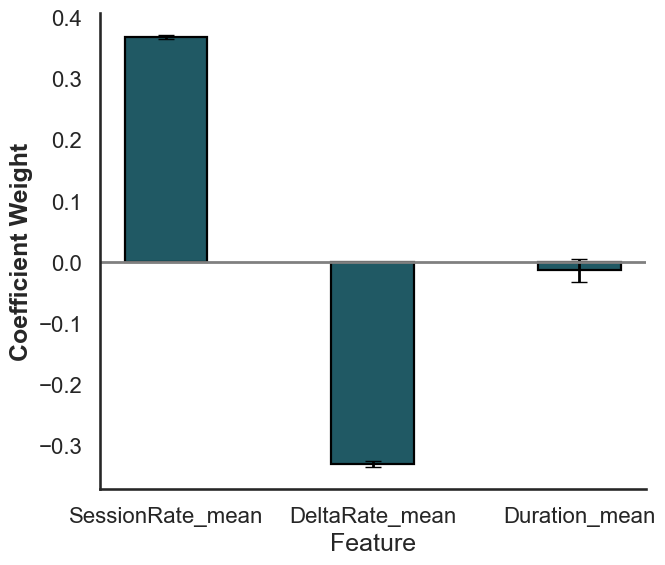

In [ ]:
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Features ---
features = ["SessionRate_mean", "DeltaRate_mean", "Duration_mean"]

# --- Split datasets ---
valence_df = session_df[session_df["Condition"].isin(["RI1", "RI2"])].dropna(subset=features).copy()
rank_df = session_df[session_df["Condition"].isin(["CM", "BL", "BLRI"])].dropna(subset=features).copy()

X_val = valence_df[features].to_numpy()
y_val = (valence_df["Condition"] == "RI1").astype(int).to_numpy()
groups = valence_df["Subject"].to_numpy()

X_rank = rank_df[features].to_numpy()
y_rank = (rank_df["Rank"] == "Dominant").astype(int).to_numpy()

# --- Cross-validation setup ---
unique_subjects = np.unique(groups)
cv = GroupKFold(n_splits=len(unique_subjects))

valence_aucs = []
transfer_aucs = []
coefs = []
fold_labels = []

print(f"Running Leave-One-Subject-Out Valence→Rank CV on {len(unique_subjects)} subjects...\n")

for train_idx, test_idx in cv.split(X_val, y_val, groups):
    subj_test = np.unique(groups[test_idx])[0]
    X_train, X_test_val = X_val[train_idx], X_val[test_idx]
    y_train, y_test_val = y_val[train_idx], y_val[test_idx]

    if len(np.unique(y_test_val)) < 2:
        print(f"⚠️ Skipping subject {subj_test} (only one valence in test set)")
        continue

    # Train model
    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(C=0.1, penalty="l2", solver="liblinear")
    )
    model.fit(X_train, y_train)

    # Predict within-valence
    y_pred_val = model.predict_proba(X_test_val)[:, 1]
    auc_val = roc_auc_score(y_test_val, y_pred_val)
    valence_aucs.append(auc_val)

    # Predict on rank data
    y_pred_rank = model.predict_proba(X_rank)[:, 1]
    auc_rank = roc_auc_score(y_rank, y_pred_rank)
    transfer_aucs.append(auc_rank)

    # Store coefficients
    lr = model.named_steps["logisticregression"]
    coefs.append(lr.coef_.flatten())
    fold_labels.append(subj_test)

    print(f"Subject {subj_test}: Valence AUC = {auc_val:.2f}, Transfer AUC = {auc_rank:.2f}")

# --- Compute summary stats ---
val_mean, val_sem = np.mean(valence_aucs), np.std(valence_aucs, ddof=1) / np.sqrt(len(valence_aucs))
transfer_mean, transfer_sem = np.mean(transfer_aucs), np.std(transfer_aucs, ddof=1) / np.sqrt(len(transfer_aucs))

print("\n🏆 Results Summary")
print(f"Valence (RI1 vs RI2): {val_mean:.2f} ± {val_sem:.2f}")
print(f"Valence→Rank transfer: {transfer_mean:.2f} ± {transfer_sem:.2f}")

# ==============================
# 📊 1. AUC Summary Plot
# ==============================
auc_df = pd.DataFrame({
    "Model": ["Valence CV", "Valence → Rank Transfer"],
    "AUC": [val_mean, transfer_mean],
    "SEM": [val_sem, transfer_sem]
})

sns.set(style="white", context="talk")
plt.figure(figsize=(6, 6))
ax = sns.barplot(
    data=auc_df,
    x="Model", y="AUC",
    color="#414535", width=0.4, edgecolor="black", linewidth=1.6
)
ax.errorbar(x=np.arange(2), y=auc_df["AUC"], yerr=auc_df["SEM"],
            fmt="none", ecolor="black", capsize=6, lw=2)
ax.axhline(0.5, ls="--", color="gray", lw=2)
ax.set_ylim(0, 1)
ax.set_ylabel("AUC", fontsize=18, fontweight="bold")
ax.tick_params(axis="x", labelsize=16)
sns.despine()
plt.tight_layout()
plt.show()

# ==============================
# ⚙️ 2. Coefficient Plot
# ==============================
coefs = np.array(coefs)
coef_mean = coefs.mean(axis=0)
coef_sem = coefs.std(axis=0, ddof=1) / np.sqrt(len(coefs))

coef_df = pd.DataFrame({"Feature": features, "Weight": coef_mean, "SEM": coef_sem})

plt.figure(figsize=(7, 6))
ax = sns.barplot(
    data=coef_df, x="Feature", y="Weight",
    color="#15616F", width=0.4, edgecolor="black", linewidth=1.6
)
ax.errorbar(x=np.arange(len(features)), y=coef_mean, yerr=coef_sem,
            fmt="none", ecolor="black", capsize=6, lw=2)
ax.axhline(0, color="gray", lw=2)
ax.set_ylabel("Coefficient Weight", fontsize=18, fontweight="bold")
ax.tick_params(axis="x", labelsize=16)
ax.tick_params(axis="y", labelsize=16)
sns.despine()
plt.tight_layout()
plt.show()


Running Leave-One-Subject-Out Valence→Rank CV on 8 subjects...

Subject 4_7: Valence AUC = 1.00, Transfer AUC = 0.17
Subject 3_6: Valence AUC = 1.00, Transfer AUC = 0.33
Subject 2_4: Valence AUC = 1.00, Transfer AUC = 0.17
Subject 2_3: Valence AUC = 1.00, Transfer AUC = 0.17
Subject 1_2: Valence AUC = 1.00, Transfer AUC = 0.33
Subject 1_1: Valence AUC = 1.00, Transfer AUC = 0.33
⚠️ Skipping subject 4_8 (only one valence in test set)
⚠️ Skipping subject 3_5 (only one valence in test set)

🏆 Results Summary
Valence (RI1 vs RI2): 1.00 ± 0.00
Valence→Rank transfer: 0.25 ± 0.04


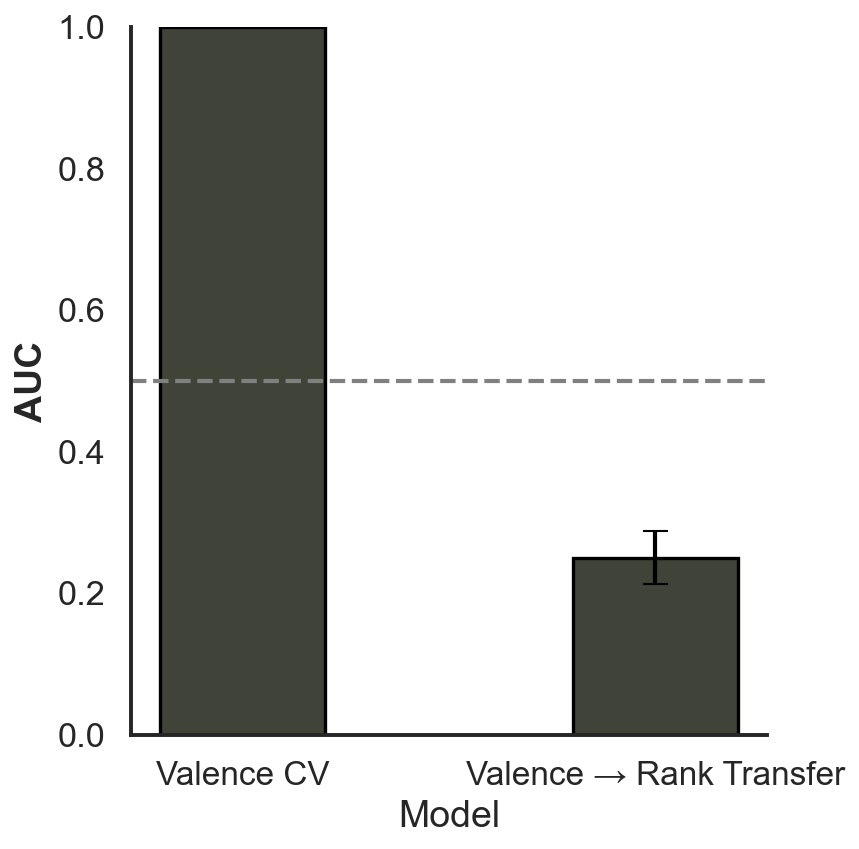

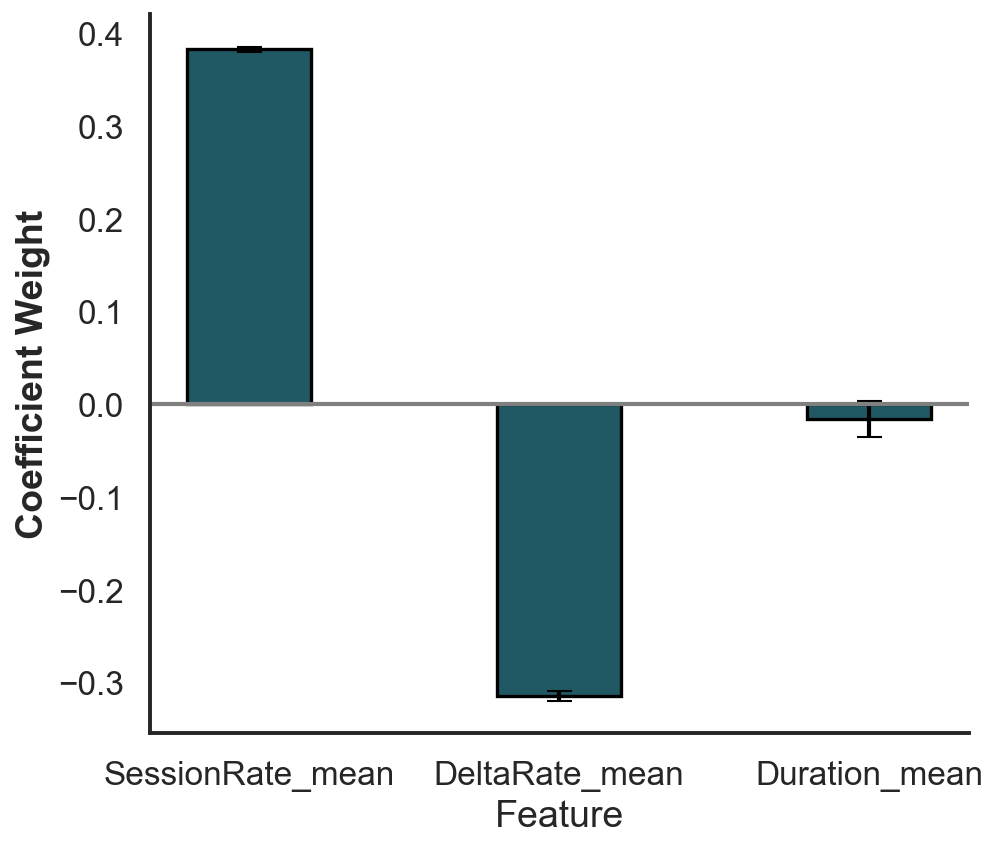

In [46]:
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Features ---
features = ["SessionRate_mean", "DeltaRate_mean", "Duration_mean"]

# --- Split datasets ---
valence_df = session_df[session_df["Condition"].isin(["RI1", "RI2"])].dropna(subset=features).copy()
rank_df = session_df[session_df["Condition"].isin(["CM", "BL", "BLRI"])].dropna(subset=features).copy()

X_val = valence_df[features].to_numpy()
y_val = (valence_df["Condition"] == "RI1").astype(int).to_numpy()
groups = valence_df["Subject"].to_numpy()

X_rank = rank_df[features].to_numpy()
y_rank = (rank_df["Rank"] == "Dominant").astype(int).to_numpy()

# --- Cross-validation setup ---
unique_subjects = np.unique(groups)
cv = GroupKFold(n_splits=len(unique_subjects))

valence_aucs = []
transfer_aucs = []
coefs = []
fold_labels = []

print(f"Running Leave-One-Subject-Out Valence→Rank CV on {len(unique_subjects)} subjects...\n")

for train_idx, test_idx in cv.split(X_val, y_val, groups):
    subj_test = np.unique(groups[test_idx])[0]
    X_train, X_test_val = X_val[train_idx], X_val[test_idx]
    y_train, y_test_val = y_val[train_idx], y_val[test_idx]

    if len(np.unique(y_test_val)) < 2:
        print(f"⚠️ Skipping subject {subj_test} (only one valence in test set)")
        continue

    # Train model
    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(C=0.1, penalty="l2", solver="liblinear")
    )
    model.fit(X_train, y_train)

    # Predict within-valence
    y_pred_val = model.predict_proba(X_test_val)[:, 1]
    auc_val = roc_auc_score(y_test_val, y_pred_val)
    valence_aucs.append(auc_val)

    # Predict on rank data
    y_pred_rank = model.predict_proba(X_rank)[:, 1]
    auc_rank = roc_auc_score(y_rank, y_pred_rank)
    transfer_aucs.append(auc_rank)

    # Store coefficients
    lr = model.named_steps["logisticregression"]
    coefs.append(lr.coef_.flatten())
    fold_labels.append(subj_test)

    print(f"Subject {subj_test}: Valence AUC = {auc_val:.2f}, Transfer AUC = {auc_rank:.2f}")

# --- Compute summary stats ---
val_mean, val_sem = np.mean(valence_aucs), np.std(valence_aucs, ddof=1) / np.sqrt(len(valence_aucs))
transfer_mean, transfer_sem = np.mean(transfer_aucs), np.std(transfer_aucs, ddof=1) / np.sqrt(len(transfer_aucs))

print("\n🏆 Results Summary")
print(f"Valence (RI1 vs RI2): {val_mean:.2f} ± {val_sem:.2f}")
print(f"Valence→Rank transfer: {transfer_mean:.2f} ± {transfer_sem:.2f}")

# ==============================
# 📊 1. AUC Summary Plot
# ==============================
auc_df = pd.DataFrame({
    "Model": ["Valence CV", "Valence → Rank Transfer"],
    "AUC": [val_mean, transfer_mean],
    "SEM": [val_sem, transfer_sem]
})

sns.set(style="white", context="talk")
plt.figure(figsize=(6, 6))
ax = sns.barplot(
    data=auc_df,
    x="Model", y="AUC",
    color="#414535", width=0.4, edgecolor="black", linewidth=1.6
)
ax.errorbar(x=np.arange(2), y=auc_df["AUC"], yerr=auc_df["SEM"],
            fmt="none", ecolor="black", capsize=6, lw=2)
ax.axhline(0.5, ls="--", color="gray", lw=2)
ax.set_ylim(0, 1)
ax.set_ylabel("AUC", fontsize=18, fontweight="bold")
ax.tick_params(axis="x", labelsize=16)
sns.despine()
plt.tight_layout()
plt.show()

# ==============================
# ⚙️ 2. Coefficient Plot
# ==============================
coefs = np.array(coefs)
coef_mean = coefs.mean(axis=0)
coef_sem = coefs.std(axis=0, ddof=1) / np.sqrt(len(coefs))

coef_df = pd.DataFrame({"Feature": features, "Weight": coef_mean, "SEM": coef_sem})

plt.figure(figsize=(7, 6))
ax = sns.barplot(
    data=coef_df, x="Feature", y="Weight",
    color="#15616F", width=0.4, edgecolor="black", linewidth=1.6
)
ax.errorbar(x=np.arange(len(features)), y=coef_mean, yerr=coef_sem,
            fmt="none", ecolor="black", capsize=6, lw=2)
ax.axhline(0, color="gray", lw=2)
ax.set_ylabel("Coefficient Weight", fontsize=18, fontweight="bold")
ax.tick_params(axis="x", labelsize=16)
ax.tick_params(axis="y", labelsize=16)
sns.despine()
plt.tight_layout()
plt.show()


In [53]:
# --- Use bout-level data ---
features = ["MeanRate"]

valence_df = master_df[
    (master_df["Type"] == "Interaction") &
    (master_df["Condition"].isin(["RI1", "RI2"]))
].copy()

# Explicitly drop NaNs (critical)
valence_df = valence_df[np.isfinite(valence_df["MeanRate"])].copy()

X = valence_df[features].values        # shape (n_bouts, 1)
y = (valence_df["Condition"] == "RI1").astype(int).values
groups = valence_df["Subject"].values

print("Shapes:", X.shape, y.shape, groups.shape)
print("NaNs in X?", np.isnan(X).any())


Shapes: (307, 1) (307,) (307,)
NaNs in X? False


In [56]:
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import numpy as np

unique_subjects = np.unique(groups)
cv = GroupKFold(n_splits=len(unique_subjects))

aucs = []
subjects_tested = []

print(f"Running LOSO valence decoding on {len(unique_subjects)} subjects\n")

for train_idx, test_idx in cv.split(X, y, groups):
    subj = np.unique(groups[test_idx])[0]

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Skip folds with only one class in test
    if len(np.unique(y_test)) < 2:
        print(f"⚠️ Skipping {subj} (single valence)")
        continue

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="liblinear",
            class_weight="balanced"
        ))
    ])

    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, probs)

    aucs.append(auc)
    subjects_tested.append(subj)

    print(f"Subject {subj}: AUC = {auc:.2f}")


Running LOSO valence decoding on 8 subjects

Subject 1_1: AUC = 0.42
Subject 1_2: AUC = 0.97
Subject 2_4: AUC = 0.60
Subject 2_3: AUC = 0.62
Subject 4_7: AUC = 0.85
Subject 3_6: AUC = 0.22
⚠️ Skipping 4_8 (single valence)
⚠️ Skipping 3_5 (single valence)


🔎 INPUT SHAPES
-----------------------------
Valence X shape: (14, 3)
Valence y shape: (14,)
Groups shape:    (14,)

Rank X shape:    (7, 3)
Rank y shape:    (7,)
-----------------------------

Running Leave-One-Subject-Out Valence→Rank CV on 8 subjects...

Subject 4_7: Valence AUC = 1.00, Transfer AUC = 0.17
Subject 3_6: Valence AUC = 1.00, Transfer AUC = 0.33
Subject 2_4: Valence AUC = 1.00, Transfer AUC = 0.17
Subject 2_3: Valence AUC = 1.00, Transfer AUC = 0.17
Subject 1_2: Valence AUC = 1.00, Transfer AUC = 0.33
Subject 1_1: Valence AUC = 1.00, Transfer AUC = 0.33
⚠️ Skipping subject 4_8 (only one valence in test set)
⚠️ Skipping subject 3_5 (only one valence in test set)

🏆 Results Summary
Valence CV: 1.00 ± 0.00
Valence→Rank: 0.25 ± 0.04


C:\Users\sjs93\AppData\Local\Temp\ipykernel_432\74560030.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


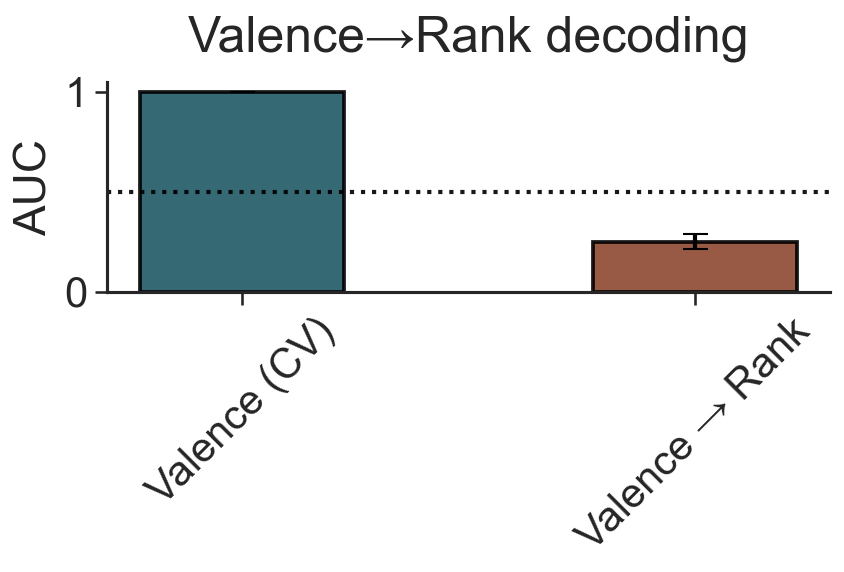

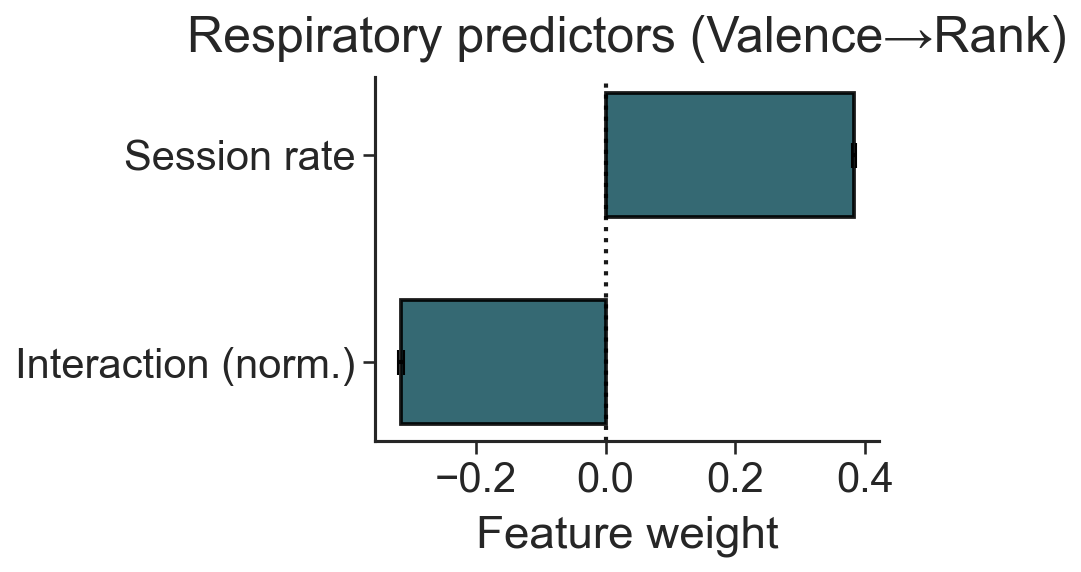

In [ ]:
# ======================================================
# 🎨 Padilla Lab Poster Style Setup
# ======================================================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

sns.set(style="ticks", font_scale=1.9)
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.5,
    "figure.dpi": 150
})

# ======================================================
# ⚙️ Data prep
# ======================================================
features = ["SessionRate_mean", "DeltaRate_mean", "Duration_mean"]

valence_df = session_df[session_df["Condition"].isin(["RI1", "RI2"])].dropna(subset=features).copy()
rank_df    = session_df[session_df["Condition"].isin(["CM", "BL", "BLRI"])].dropna(subset=features).copy()

X_val = valence_df[features].to_numpy()
y_val = (valence_df["Condition"] == "RI1").astype(int).to_numpy()
groups = valence_df["Subject"].to_numpy()

X_rank = rank_df[features].to_numpy()
y_rank = (rank_df["Rank"] == "Dominant").astype(int).to_numpy()

print("🔎 INPUT SHAPES")
print("-----------------------------")
print(f"Valence X shape: {X_val.shape}")
print(f"Valence y shape: {y_val.shape}")
print(f"Groups shape:    {groups.shape}")
print()
print(f"Rank X shape:    {X_rank.shape}")
print(f"Rank y shape:    {y_rank.shape}")
print("-----------------------------\n")


# ======================================================
# 🔁 Leave-one-subject-out CV
# ======================================================
unique_subjects = np.unique(groups)
cv = GroupKFold(n_splits=len(unique_subjects))

valence_aucs, transfer_aucs, coefs, fold_labels = [], [], [], []
print(f"Running Leave-One-Subject-Out Valence→Rank CV on {len(unique_subjects)} subjects...\n")

for train_idx, test_idx in cv.split(X_val, y_val, groups):
    subj_test = np.unique(groups[test_idx])[0]
    X_train, X_test_val = X_val[train_idx], X_val[test_idx]
    y_train, y_test_val = y_val[train_idx], y_val[test_idx]

    if len(np.unique(y_test_val)) < 2:
        print(f"⚠️ Skipping subject {subj_test} (only one valence in test set)")
        continue

    model = make_pipeline(StandardScaler(),
                          LogisticRegression(C=0.1, penalty="l2", solver="liblinear"))
    model.fit(X_train, y_train)

    # Valence CV
    auc_val = roc_auc_score(y_test_val, model.predict_proba(X_test_val)[:, 1])
    valence_aucs.append(auc_val)

    # Transfer to Rank
    auc_rank = roc_auc_score(y_rank, model.predict_proba(X_rank)[:, 1])
    transfer_aucs.append(auc_rank)

    coefs.append(model.named_steps["logisticregression"].coef_.flatten())
    fold_labels.append(subj_test)
    print(f"Subject {subj_test}: Valence AUC = {auc_val:.2f}, Transfer AUC = {auc_rank:.2f}")

val_mean, val_sem = np.mean(valence_aucs), np.std(valence_aucs, ddof=1) / np.sqrt(len(valence_aucs))
transfer_mean, transfer_sem = np.mean(transfer_aucs), np.std(transfer_aucs, ddof=1) / np.sqrt(len(transfer_aucs))

print("\n🏆 Results Summary")
print(f"Valence CV: {val_mean:.2f} ± {val_sem:.2f}")
print(f"Valence→Rank: {transfer_mean:.2f} ± {transfer_sem:.2f}")

# ======================================================
# 📊 1️⃣ AUC Summary Plot (Poster-Style)
# ======================================================
auc_df = pd.DataFrame({
    "Model": ["Valence (CV)", "Valence → Rank"],
    "AUC": [val_mean, transfer_mean],
    "SEM": [val_sem, transfer_sem]
})

fig, ax = plt.subplots(figsize=(6.5, 4.3))
fig.patch.set_alpha(0.0)
ax.set_facecolor("none")

sns.barplot(
    data=auc_df, x="Model", y="AUC",
    palette=["#15616F", "#9C4221"],
    width=0.45, edgecolor="black", linewidth=1.8, alpha=0.9, ax=ax
)

ax.errorbar(np.arange(len(auc_df)), auc_df["AUC"], auc_df["SEM"],
            fmt="none", ecolor="black", elinewidth=2, capsize=6)

ax.axhline(0.5, color="black", lw=2, linestyle="dotted", alpha=0.9)
ax.set_ylim(0, 1.05)
ax.set_ylabel("AUC", fontsize=22)
ax.set_xlabel("", fontsize=20)
ax.set_title("Valence→Rank decoding", fontsize=24, pad=15, weight="normal")
ax.tick_params(axis="x", labelsize=20, rotation=45)
ax.tick_params(axis="y", labelsize=20)
sns.despine()
plt.tight_layout()
plt.show()

# ======================================================
# ⚙️ 2️⃣ Coefficient Weights Plot (Match Rank Style)
# ======================================================
# Only include overlapping features with the Rank model
features_subset = ["SessionRate_mean", "DeltaRate_mean"]
new_labels = ["Session rate", "Interaction (norm.)"]

coefs = np.array(coefs)
subset_idx = [features.index(f) for f in features_subset]
coefs_sub = coefs[:, subset_idx]

coef_mean = coefs_sub.mean(axis=0)
coef_sem = coefs_sub.std(axis=0, ddof=1) / np.sqrt(len(coefs_sub))

coef_df = pd.DataFrame({
    "Feature": new_labels,
    "Weight": coef_mean,
    "SEM": coef_sem
})

fig, ax = plt.subplots(figsize=(6.5, 4.3))
fig.patch.set_alpha(0.0)
ax.set_facecolor("none")

sns.barplot(
    data=coef_df,
    y="Feature", x="Weight",
    color="#15616F",
    edgecolor="black",
    linewidth=1.8,
    orient="h",
    width=0.6,
    alpha=0.9,
    ax=ax
)

ax.errorbar(y=np.arange(len(coef_df)), x=coef_df["Weight"], xerr=coef_df["SEM"],
            fmt="none", ecolor="black", elinewidth=2, capsize=6)
ax.axvline(0, color="black", lw=2, linestyle="dotted", alpha=0.9)

ax.set_xlabel("Feature weight", fontsize=22, labelpad=8)
ax.set_ylabel("", fontsize=20)
ax.set_title("Respiratory predictors (Valence→Rank)", fontsize=24, pad=12, weight="normal")
ax.tick_params(axis="x", labelsize=20)
ax.tick_params(axis="y", labelsize=20)
sns.despine()
plt.tight_layout()
plt.show()


Running Leave-One-Subject-Out Valence CV on 8 subjects...

Subject 4_7: AUC = 1.00
Subject 3_6: AUC = 1.00
Subject 2_4: AUC = 1.00
Subject 2_3: AUC = 1.00
Subject 1_2: AUC = 1.00
Subject 1_1: AUC = 1.00
⚠️ Skipping subject 4_8 (only one valence class in test set)
⚠️ Skipping subject 3_5 (only one valence class in test set)

🏆 Valence AUC = 1.00 ± 0.00


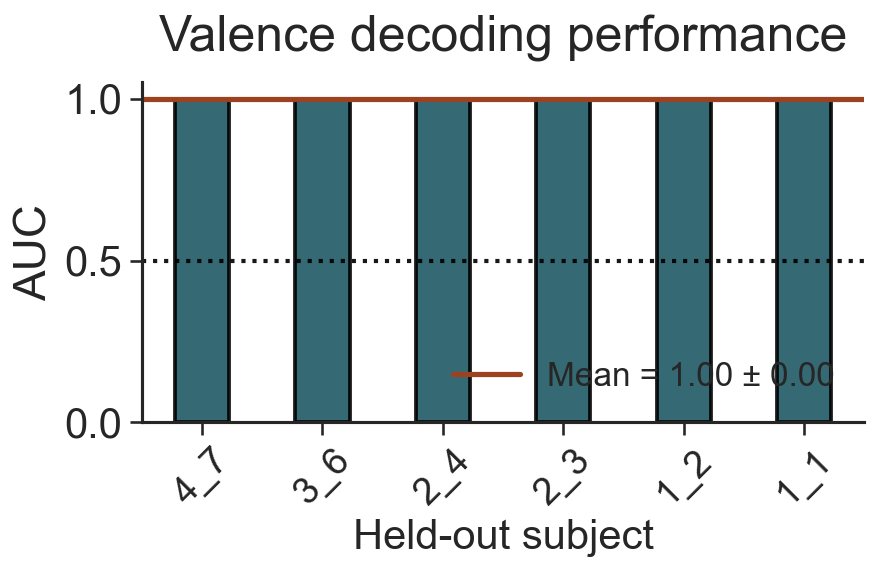

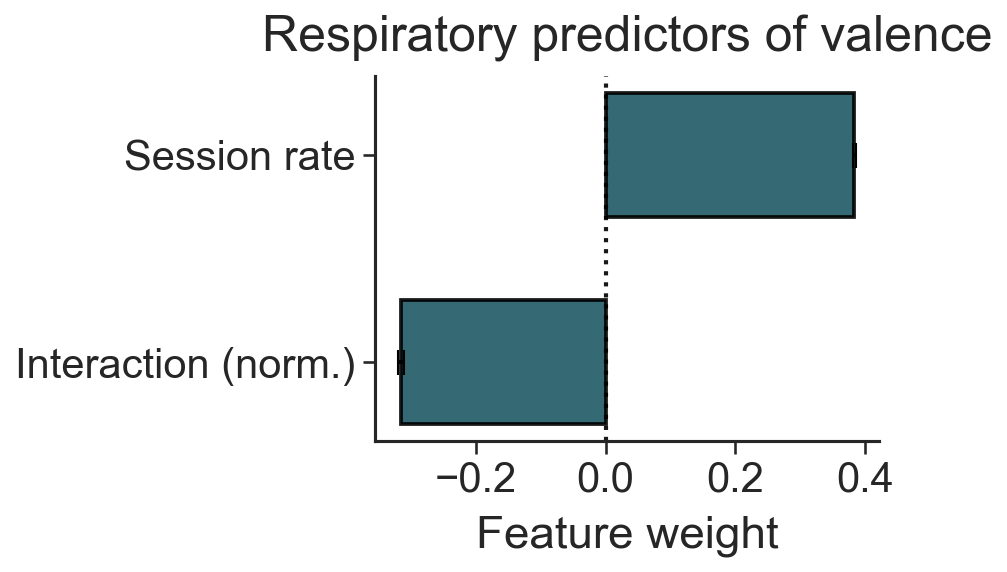

In [ ]:
# ======================================================
# 🧠 Imports
# ======================================================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# ======================================================
# ⚙️ Data prep — Match Rank model features
# ======================================================
features = ["SessionRate_mean", "DeltaRate_mean"]

valence_df = session_df[
    session_df["Condition"].isin(["RI1", "RI2"])
].dropna(subset=features).copy()

X = valence_df[features].to_numpy()
y = (valence_df["Condition"] == "RI1").astype(int).to_numpy()  # 1 = positive valence
groups = valence_df["Subject"].to_numpy()

unique_subjects = np.unique(groups)
cv = GroupKFold(n_splits=len(unique_subjects))

valence_aucs, coefs, fold_labels = [], [], []

print(f"Running Leave-One-Subject-Out Valence CV on {len(unique_subjects)} subjects...\n")

for train_idx, test_idx in cv.split(X, y, groups):
    subj_test = np.unique(groups[test_idx])[0]
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Skip invalid folds
    if len(np.unique(y_test)) < 2:
        print(f"⚠️ Skipping subject {subj_test} (only one valence class in test set)")
        continue

    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(C=0.1, penalty="l2", solver="liblinear")
    )
    model.fit(X_train, y_train)

    y_pred = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred)
    valence_aucs.append(auc)
    fold_labels.append(subj_test)

    coefs.append(model.named_steps["logisticregression"].coef_[0])

    print(f"Subject {subj_test}: AUC = {auc:.2f}")

# ======================================================
# 📈 Summary stats
# ======================================================
val_mean = np.mean(valence_aucs)
val_sem = np.std(valence_aucs, ddof=1) / np.sqrt(len(valence_aucs))

print(f"\n🏆 Valence AUC = {val_mean:.2f} ± {val_sem:.2f}")

# ======================================================
# 🎨 Poster style setup (Padilla Lab aesthetic)
# ======================================================
sns.set(style="ticks", font_scale=1.9)
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.5,
    "figure.dpi": 150
})

# ======================================================
# 📊 1️⃣ AUC per subject (poster-ready)
# ======================================================
auc_df = pd.DataFrame({"Subject": fold_labels, "AUC": valence_aucs})

fig, ax = plt.subplots(figsize=(6.5, 4.3))
fig.patch.set_alpha(0.0)
ax.set_facecolor("none")

sns.barplot(
    data=auc_df, x="Subject", y="AUC",
    color="#15616F", width=0.45,
    edgecolor="black", linewidth=1.8, alpha=0.9, ax=ax
)

ax.axhline(0.5, color="black", lw=2, linestyle="dotted", alpha=0.9)
ax.axhline(val_mean, color="#9C4221", lw=2.5,
           label=f"Mean = {val_mean:.2f} ± {val_sem:.2f}")

ax.legend(fontsize=16, frameon=False, loc="lower right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("AUC", fontsize=22)
ax.set_xlabel("Held-out subject", fontsize=20)
ax.set_title("Valence decoding performance", fontsize=24, pad=15, weight="normal")
ax.tick_params(axis="x", labelsize=18, rotation=45)
ax.tick_params(axis="y", labelsize=20)
sns.despine()
plt.tight_layout()
plt.show()

# ======================================================
# ⚙️ 2️⃣ Feature weights (poster-ready, match Rank)
# ======================================================
# --- Feature labels match Rank plot style ---
new_labels = ["Session rate", "Interaction (norm.)"]

coefs = np.array(coefs)
coef_mean = coefs.mean(axis=0)
coef_sem = coefs.std(axis=0, ddof=1) / np.sqrt(len(coefs))

coef_df = pd.DataFrame({
    "Feature": new_labels,
    "Weight": coef_mean,
    "SEM": coef_sem
})

fig, ax = plt.subplots(figsize=(6.5, 4.3))
fig.patch.set_alpha(0.0)
ax.set_facecolor("none")

sns.barplot(
    data=coef_df, y="Feature", x="Weight",
    color="#15616F", edgecolor="black",
    linewidth=1.8, orient="h", width=0.6, alpha=0.9, ax=ax
)

ax.errorbar(
    y=np.arange(len(coef_df)), x=coef_df["Weight"],
    xerr=coef_df["SEM"], fmt="none",
    ecolor="black", elinewidth=2, capsize=6
)

ax.axvline(0, color="black", lw=2, linestyle="dotted", alpha=0.9)
ax.set_xlabel("Feature weight", fontsize=22, labelpad=8)
ax.set_ylabel("", fontsize=20)
ax.set_title("Respiratory predictors of valence", fontsize=24, pad=12, weight="normal")
ax.tick_params(axis="x", labelsize=20)
ax.tick_params(axis="y", labelsize=20)
sns.despine()
plt.tight_layout()
plt.show()


JUST PLOTING RESULTS FROM MODEL FOR POSTER FIGURE NO MODEL CODE HERE 

C:\Users\sjs93\AppData\Local\Temp\ipykernel_16632\3303784488.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(
C:\Users\sjs93\AppData\Local\Temp\ipykernel_16632\3303784488.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


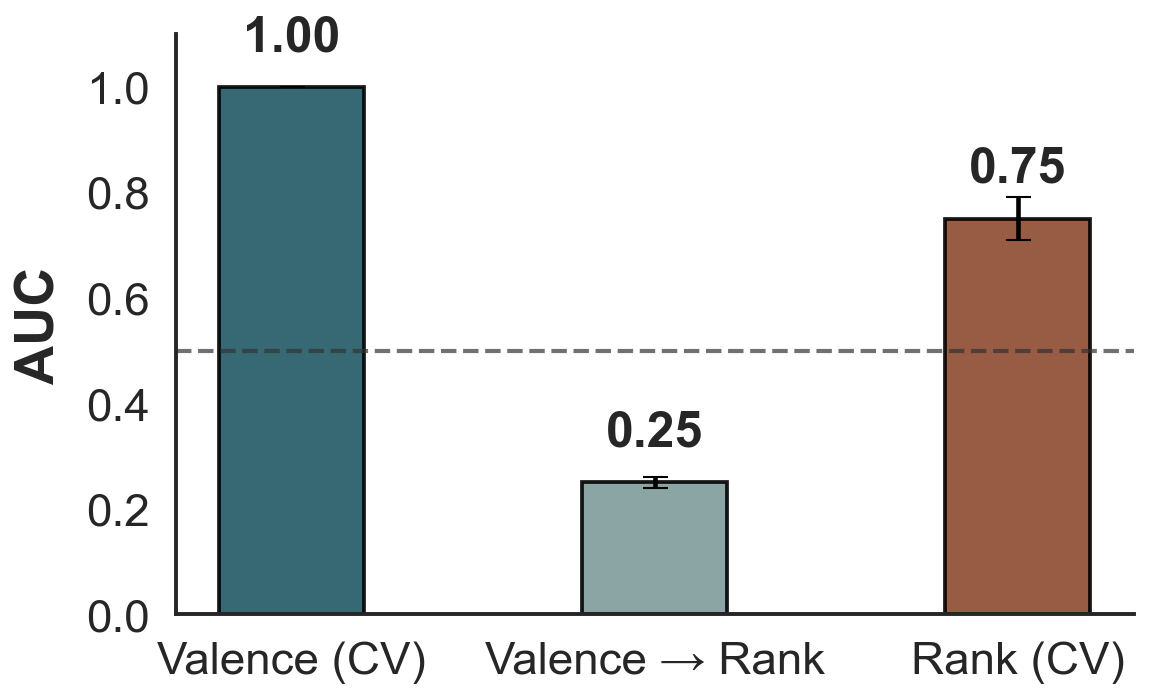

In [ ]:
# --- Your computed AUC values ---
auc_data = pd.DataFrame({
    "Model": ["Valence (CV)", "Valence → Rank", "Rank (CV)"],
    "AUC": [1.00, 0.25, 0.75],
    "SEM": [0.00, 0.01, 0.04]
})

# --- Padilla Lab–inspired palette ---
# Teal, blue-gray, and rust; distinct from valence colors
lab_palette = {
    "Valence (CV)": "#15616F",     # deep teal
    "Valence → Rank": "#7A9E9F",   # desaturated blue-gray
    "Rank (CV)": "#9C4221"         # earthy rust
}

# --- Plot aesthetics ---
sns.set(style="white", context="talk")
plt.figure(figsize=(8, 5))

# --- Draw bars ---
ax = sns.barplot(
    data=auc_data,
    x="Model",
    y="AUC",
    palette=lab_palette,
    width=0.4,
    edgecolor="black",
    linewidth=1.8,
    ci=None,
    alpha=0.9
)

# --- Add manual error bars ---
for i, row in auc_data.iterrows():
    ax.errorbar(
        i, row["AUC"],
        yerr=row["SEM"],
        fmt="none",
        ecolor="black",
        elinewidth=2.2,
        capsize=6
    )

# --- Annotate values ---
for i, row in auc_data.iterrows():
    ax.text(
        i, row["AUC"] + 0.05,
        f"{row['AUC']:.2f}",
        ha="center",
        va="bottom",
        fontsize=24,
        fontweight="bold"
    )

# --- Add chance line ---
ax.axhline(0.5, ls="--", color="#333333", lw=2, alpha=0.7)

# --- Labels and formatting ---
ax.set_ylim(0, 1.1)
ax.set_ylabel("AUC", fontsize=26, fontweight="bold", labelpad=10)
ax.set_xlabel("")
ax.tick_params(axis="x", labelsize=22, width=1.5)
ax.tick_params(axis="y", labelsize=22, width=1.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.show()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_16632\1322179951.py:24: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(
C:\Users\sjs93\AppData\Local\Temp\ipykernel_16632\1322179951.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


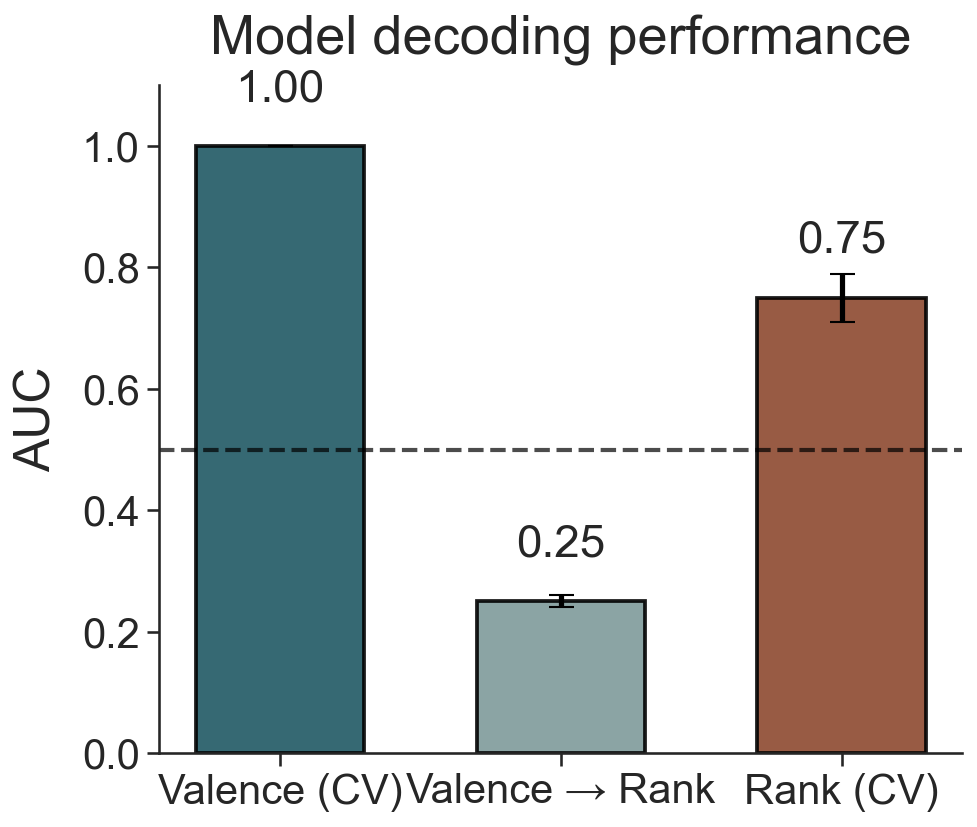

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- Data ---
auc_data = pd.DataFrame({
    "Model": ["Valence (CV)", "Valence → Rank", "Rank (CV)"],
    "AUC": [1.00, 0.25, 0.75],
    "SEM": [0.00, 0.01, 0.04]
})

# --- Padilla Lab palette (complementary to poster colors) ---
lab_palette = {
    "Valence (CV)": "#15616F",     # deep teal
    "Valence → Rank": "#7A9E9F",   # muted blue-gray
    "Rank (CV)": "#9C4221"         # rust brown
}

# --- Poster-style settings ---
sns.set(style="ticks", font_scale=1.9)
plt.figure(figsize=(7, 6))

# --- Bar plot ---
ax = sns.barplot(
    data=auc_data,
    x="Model", y="AUC",
    palette=lab_palette,
    width=0.6, edgecolor="black", linewidth=1.8,
    ci=None, alpha=0.9
)

# --- Add manual error bars ---
for i, row in auc_data.iterrows():
    ax.errorbar(
        i, row["AUC"], yerr=row["SEM"],
        fmt="none", ecolor="black", elinewidth=2.5, capsize=6
    )

# --- Annotate AUC values above bars ---
for i, row in auc_data.iterrows():
    ax.text(
        i, row["AUC"] + 0.06, f"{row['AUC']:.2f}",
        ha="center", va="bottom",
        fontsize=22, weight="normal"
    )

# --- Chance line ---
ax.axhline(0.5, ls="--", color="black", lw=2, alpha=0.7)

# --- Axis labels and title ---
ax.set_ylim(0, 1.1)
ax.set_ylabel("AUC", fontsize=24, labelpad=10)
ax.set_xlabel("", fontsize=22)
ax.set_title("Model decoding performance", fontsize=26, pad=15, weight="normal")

# --- Tick and spine formatting ---
ax.tick_params(axis="x", labelsize=20)
ax.tick_params(axis="y", labelsize=20)
sns.despine()
plt.tight_layout()
plt.show()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_16632\3270701654.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\sjs93\AppData\Local\Temp\ipykernel_16632\3270701654.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


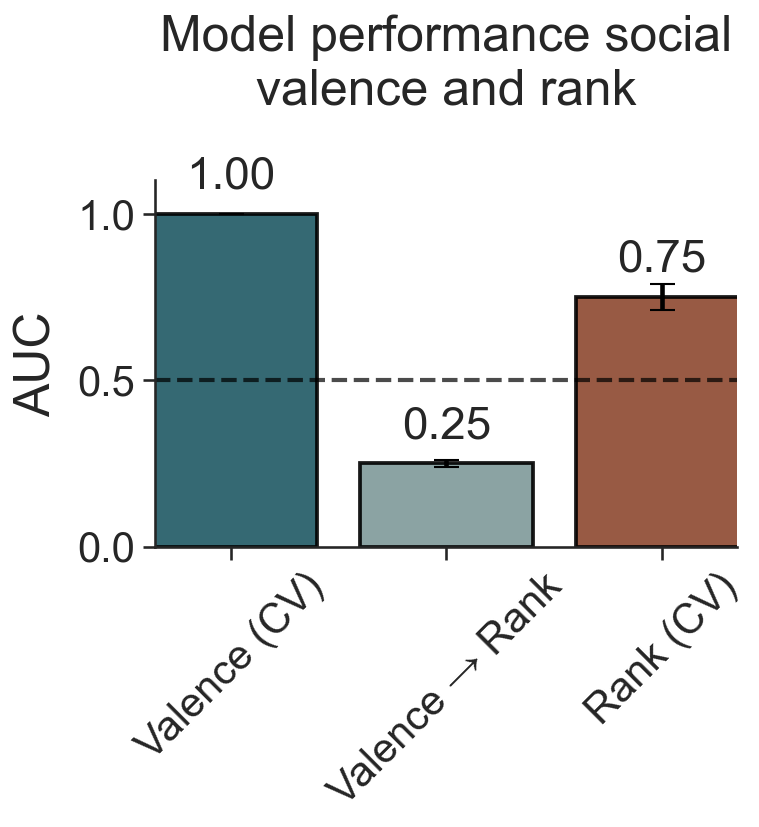

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- Data ---
auc_data = pd.DataFrame({
    "Model": ["Valence (CV)", "Valence → Rank", "Rank (CV)"],
    "AUC": [1.00, 0.25, 0.75],
    "SEM": [0.00, 0.01, 0.04]
})

# --- Colors (Padilla-style complementary tones) ---
lab_palette = {
    "Valence (CV)": "#15616F",     # deep teal
    "Valence → Rank": "#7A9E9F",   # muted blue-gray
    "Rank (CV)": "#9C4221"         # rust brown
}

# --- Poster style ---
sns.set(style="ticks", font_scale=1.9)
fig, ax = plt.subplots(figsize=(5.5, 6))
fig.patch.set_alpha(0.0)      # transparent background
ax.set_facecolor("none")

# --- Bar plot ---
sns.barplot(
    data=auc_data,
    x="Model", y="AUC",
    palette=lab_palette,
    width=0.8, edgecolor="black", linewidth=1.8,
    ci=None, alpha=0.9, ax=ax
)

# --- Error bars ---
for i, row in auc_data.iterrows():
    ax.errorbar(
        i, row["AUC"], yerr=row["SEM"],
        fmt="none", ecolor="black", elinewidth=2.2, capsize=6
    )

# --- Annotate values ---
for i, row in auc_data.iterrows():
    ax.text(
        i, row["AUC"] + 0.05, f"{row['AUC']:.2f}",
        ha="center", va="bottom",
        fontsize=22, weight="normal"
    )

# --- Chance line ---
ax.axhline(0.5, ls="--", color="black", lw=2, alpha=0.7)

# --- Axes and layout ---
ax.set_ylim(0, 1.1)
ax.set_xlim(-0.35, 2.35)
ax.set_ylabel("AUC", fontsize=24, labelpad=8)
ax.set_xlabel("")
ax.set_title("Model performance social valence and rank",
             fontsize=24, pad=40, weight="normal", wrap=True)
ax.tick_params(axis="x", labelrotation=45, labelsize=20)
ax.tick_params(axis="y", labelsize=20)
sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
# --- Clean CM subset ---
df_rank = (
    session_df[
        (session_df["Condition"] == "CM") &
        (session_df["Type"] == "Interaction")     # skip Baseline-only rows
    ]
    .dropna(subset=["SessionRate_mean", "DeltaRate_mean", "Duration_mean"])
    .copy()
)

print("Clean CM sessions for Rank model:")
print(df_rank[["Subject", "Rank", "N_bouts", "Type"]])


Clean CM sessions for Rank model:
   Subject         Rank  N_bouts         Type
2      1_2     Dominant        9  Interaction
7      2_4     Dominant       29  Interaction
17     4_8     Dominant       25  Interaction
21     1_1  Subordinate       14  Interaction
26     2_3  Subordinate       33  Interaction
30     3_5  Subordinate       32  Interaction
35     4_7  Subordinate       15  Interaction


In [ ]:
print("Dominant subjects:", session_df[session_df["Rank"]=="Dominant"]["Subject"].unique())
print("Subordinate subjects:", session_df[session_df["Rank"]=="Subordinate"]["Subject"].unique())

# Check how many conditions per subject
print("\nSession count by Subject and Condition:")
print(session_df.groupby(["Subject", "Condition"]).size())


Dominant subjects: ['1_2' '2_4' '3_6' '4_8']
Subordinate subjects: ['1_1' '2_3' '3_5' '4_7']

Session count by Subject and Condition:
Subject  Condition
1_1      BL           1
         BLRI         1
         CM           1
         RI1          1
         RI2          1
1_2      BL           1
         BLRI         1
         CM           1
         RI1          1
         RI2          1
2_3      BL           1
         BLRI         1
         CM           1
         RI1          1
         RI2          1
2_4      BL           1
         BLRI         1
         CM           1
         RI1          1
         RI2          1
3_5      BL           1
         CM           1
         RI1          1
         RI2          1
3_6      BL           1
         BLRI         1
         CM           1
         RI1          1
         RI2          1
4_7      BL           1
         BLRI         1
         CM           1
         RI1          1
         RI2          1
4_8      BL           1
       

In [ ]:
print("RI1 sessions:", session_df[session_df["Condition"]=="RI1"]["Subject"].unique())
print("RI2 sessions:", session_df[session_df["Condition"]=="RI2"]["Subject"].unique())


RI1 sessions: ['1_2' '2_4' '3_6' '4_8' '1_1' '2_3' '3_5' '4_7']
RI2 sessions: ['1_2' '2_4' '3_6' '1_1' '2_3' '3_5' '4_7']


In [ ]:
# ======================================================
# Define rank map (Dominant vs Subordinate)
# ======================================================
rank_map = {
    "1_1": "Subordinate", "1_2": "Dominant",
    "2_3": "Subordinate", "2_4": "Dominant",
    "3_5": "Subordinate", "3_6": "Dominant",
    "4_7": "Subordinate", "4_8": "Dominant"
}

# ======================================================
# Process all trials and combine into one DataFrame
# ======================================================
master_df = process_all_trials(resp_paths, boris_paths, rank_map)

print("\n Master DataFrame created!")
print(master_df.shape)
print(master_df.head())

# --- Sanity check that Type column exists ---
if "Type" in master_df.columns:
    print("\nUnique session types:", master_df["Type"].unique())
else:
    print("Warning: 'Type' column missing — re-run process_all_trials() definition!")

# ======================================================
# Optionally save to disk
# ======================================================
save_path = r"E:\Aim1\AIM1\processed_behavior_resp_rates.csv"
master_df.to_csv(save_path, index=False)
print(f"Saved to {save_path}")


Processing RI1_3_6...
Session-wide respiratory rate for RI1_3_6: 7.270 Hz
   → Filtered 4 short bouts (<0.5s)
Processing RI2_3_6...
Session-wide respiratory rate for RI2_3_6: 5.933 Hz
   → Filtered 12 short bouts (<0.5s)
Processing RI1_4_7...
Session-wide respiratory rate for RI1_4_7: 7.564 Hz
   → Filtered 3 short bouts (<0.5s)
Processing RI2_4_7...
Session-wide respiratory rate for RI2_4_7: 6.551 Hz
   → Filtered 1 short bouts (<0.5s)
Processing RI1_2_3...
Session-wide respiratory rate for RI1_2_3: 7.286 Hz
Processing RI2_2_3...
Session-wide respiratory rate for RI2_2_3: 6.674 Hz
Processing RI1_4_8...
Session-wide respiratory rate for RI1_4_8: 7.410 Hz
   → Filtered 8 short bouts (<0.5s)
Processing RI2_4_8...
Session-wide respiratory rate for RI2_4_8: 5.776 Hz
   → Filtered 1 short bouts (<0.5s)
Processing RI1_1_1...
Session-wide respiratory rate for RI1_1_1: 7.433 Hz
   → Filtered 4 short bouts (<0.5s)
Processing RI2_1_1...
Session-wide respiratory rate for RI2_1_1: 6.009 Hz
Process

In [ ]:
df_check = pd.read_csv(r"E:\Aim1\AIM1\processed_behavior_resp_rates.csv")
print(df_check["Type"].value_counts())


Type
Interaction    307
Baseline         8
Name: count, dtype: int64


In [ ]:
rank_map = {
    "1_1": "Subordinate", "1_2": "Dominant",
    "2_3": "Subordinate", "2_4": "Dominant",
    "3_5": "Subordinate", "3_6": "Dominant",
    "4_7": "Subordinate", "4_8": "Dominant"
}

master_df = process_all_trials(resp_paths, boris_paths, rank_map)
print(master_df.columns)
print(master_df["Type"].value_counts())


Processing RI1_3_6...
Session-wide respiratory rate for RI1_3_6: 7.270 Hz
   → Filtered 4 short bouts (<0.5s)
Processing RI2_3_6...
Session-wide respiratory rate for RI2_3_6: 5.933 Hz
   → Filtered 12 short bouts (<0.5s)
Processing RI1_4_7...
Session-wide respiratory rate for RI1_4_7: 7.564 Hz
   → Filtered 3 short bouts (<0.5s)
Processing RI2_4_7...
Session-wide respiratory rate for RI2_4_7: 6.551 Hz
   → Filtered 1 short bouts (<0.5s)
Processing RI1_2_3...
Session-wide respiratory rate for RI1_2_3: 7.286 Hz
Processing RI2_2_3...
Session-wide respiratory rate for RI2_2_3: 6.674 Hz
Processing RI1_4_8...
Session-wide respiratory rate for RI1_4_8: 7.410 Hz
   → Filtered 8 short bouts (<0.5s)
Processing RI2_4_8...
Session-wide respiratory rate for RI2_4_8: 5.776 Hz
   → Filtered 1 short bouts (<0.5s)
Processing RI1_1_1...
Session-wide respiratory rate for RI1_1_1: 7.433 Hz
   → Filtered 4 short bouts (<0.5s)
Processing RI2_1_1...
Session-wide respiratory rate for RI2_1_1: 6.009 Hz
Process

In [ ]:
def aggregate_session_features(df):
    """
    Aggregate bout-level data into session-level features.
    Keeps both Interaction and Baseline sessions.
    """
    group_cols = ["Trial", "Subject", "Condition", "Rank", "Type"]

    session_df = (
        df.groupby(group_cols, dropna=False)
        .agg(
            MeanRate_mean=("MeanRate", "mean"),
            MeanRate_std=("MeanRate", "std"),
            DeltaRate_mean=("MeanRate", lambda x: np.nan if x.isna().all() else np.nanmean(x - np.nanmean(x))),
            DeltaRate_std=("MeanRate", lambda x: np.nan if x.isna().all() else np.nanstd(x - np.nanmean(x))),
            Duration_mean=("Duration", "mean"),
            Duration_sum=("Duration", "sum"),
            SessionRate_mean=("SessionRate", "mean"),
            N_bouts=("MeanRate", "count")
        )
        .reset_index()
    )

    print(f"✅ Aggregated to {len(session_df)} session-level entries.")
    return session_df


In [ ]:
session_df = aggregate_session_features(master_df)
print(session_df["Condition"].value_counts())
print(session_df["Type"].value_counts())


✅ Aggregated to 22 session-level entries.
Condition
RI1     8
BLRI    7
RI2     7
Name: count, dtype: int64
Type
Interaction    14
Baseline        8
Name: count, dtype: int64


In [ ]:
def aggregate_session_features(master_df):
    df = master_df[master_df["Type"] == "Interaction"].copy()
    grouped = df.groupby(["Trial", "Subject", "Condition", "Rank", "Type"], dropna=False)

    session_df = grouped.agg(
        MeanRate_mean=("MeanRate", "mean"),
        MeanRate_std=("MeanRate", "std"),
        DeltaRate_mean=("MeanRate", lambda x: np.nan if x.isna().all() else np.nanmean(x - np.nanmean(x))),
        DeltaRate_std=("MeanRate", lambda x: np.nan if x.isna().all() else np.nanstd(x - np.nanmean(x))),
        Duration_mean=("Duration", "mean"),
        Duration_sum=("Duration", "sum"),
        SessionRate_mean=("SessionRate", "mean"),
        N_bouts=("MeanRate", "count"),
    ).reset_index()

    print(f"✅ Aggregated to {len(session_df)} session-level entries.")
    return session_df



In [ ]:
# ✅ Aggregate bout-level → session-level
session_df = aggregate_session_features(master_df)

# 🔍 Inspect
print(session_df.shape)
session_df.head()



✅ Aggregated to 14 session-level entries.
(14, 13)


,Trial,Subject,Condition,Rank,Type,MeanRate_mean,MeanRate_std,DeltaRate_mean,DeltaRate_std,Duration_mean,Duration_sum,SessionRate_mean,N_bouts
0,RI1_1_1,1_1,RI1,Subordinate,Interaction,7.411572,0.979256,7.190016e-16,0.973409,2.761881,231.998,7.433281,84
1,RI1_1_2,1_2,RI1,Dominant,Interaction,7.115237,1.220061,-5.730183e-16,1.210182,2.154000,133.548,7.555379,62
2,RI1_2_3,2_3,RI1,Subordinate,Interaction,8.390487,0.677056,-2.471453e-15,0.662174,1.869522,42.999,7.285965,23
3,RI1_2_4,2_4,RI1,Dominant,Interaction,8.701079,0.906506,6.978545e-16,0.895650,1.817571,76.338,8.113743,42
4,RI1_3_6,3_6,RI1,Dominant,Interaction,8.549504,1.017724,3.700743e-16,0.974397,1.726750,20.721,7.270376,12


In [ ]:
session_df


,Trial,Subject,Condition,Rank,Type,MeanRate_mean,MeanRate_std,DeltaRate_mean,DeltaRate_std,Duration_mean,Duration_sum,SessionRate_mean,N_bouts
0,RI1_1_1,1_1,RI1,Subordinate,Interaction,7.411572,0.979256,7.190016e-16,0.973409,2.761881,231.998,7.433281,84
1,RI1_1_2,1_2,RI1,Dominant,Interaction,7.115237,1.220061,-5.730183e-16,1.210182,2.154000,133.548,7.555379,62
2,RI1_2_3,2_3,RI1,Subordinate,Interaction,8.390487,0.677056,-2.471453e-15,0.662174,1.869522,42.999,7.285965,23
3,RI1_2_4,2_4,RI1,Dominant,Interaction,8.701079,0.906506,6.978545e-16,0.895650,1.817571,76.338,8.113743,42
4,RI1_3_6,3_6,RI1,Dominant,Interaction,8.549504,1.017724,3.700743e-16,0.974397,1.726750,20.721,7.270376,12
5,RI1_4_7,4_7,RI1,Subordinate,Interaction,8.424655,1.128860,-1.644775e-16,1.107758,1.735556,46.860,7.564174,27
6,RI1_4_8,4_8,RI1,Dominant,Interaction,8.029023,1.429789,-6.344132e-16,1.395331,0.971143,20.394,7.410347,21
7,RI2_1_1,1_1,RI2,Subordinate,Interaction,7.231415,1.250414,-5.921189e-16,1.020959,1.250333,3.751,6.008697,3
8,RI2_1_2,1_2,RI2,Dominant,Interaction,9.009009,NaN,0.000000e+00,0.000000,0.999000,0.999,6.518717,1
9,RI2_2_3,2_3,RI2,Subordinate,Interaction,8.899329,0.789842,-6.978545e-16,0.761111,3.116643,43.633,6.674327,14


In [ ]:
print(session_df.columns)
print(session_df["Condition"].unique())


Index(['Trial', 'Subject', 'Condition', 'Rank', 'Type', 'MeanRate_mean', 'MeanRate_std', 'DeltaRate_mean', 'DeltaRate_std', 'Duration_mean', 'Duration_sum', 'SessionRate_mean', 'N_bouts'], dtype='object')
['RI1' 'RI2']


In [ ]:
master_df


,Behavior,Subject,Start,Stop,Duration,MeanRate,Trial,Condition,Rank,SessionRate,Type
0,facial sniffing,3_6,11.966,13.000,1.034,6.769826,RI1_3_6,RI1,Dominant,7.270376,Interaction
1,anogenital sniffing,3_6,14.483,16.690,2.207,8.608971,RI1_3_6,RI1,Dominant,7.270376,Interaction
2,anogenital sniffing,3_6,25.034,27.552,2.518,8.339952,RI1_3_6,RI1,Dominant,7.270376,Interaction
3,body sniffing,3_6,27.793,28.448,0.655,9.160305,RI1_3_6,RI1,Dominant,7.270376,Interaction
4,anogenital sniffing,3_6,28.862,29.861,0.999,8.008008,RI1_3_6,RI1,Dominant,7.270376,Interaction
...,...,...,...,...,...,...,...,...,...,...,...
310,NaN,2_3,NaN,NaN,NaN,NaN,BLRI_2_3,BLRI,Subordinate,7.013333,Baseline
311,NaN,2_4,NaN,NaN,NaN,NaN,BLRI_2_4,BLRI,Dominant,7.965891,Baseline
312,NaN,3_6,NaN,NaN,NaN,NaN,BLRI_3_6,BLRI,Dominant,7.390974,Baseline
313,NaN,4_7,NaN,NaN,NaN,NaN,BLRI_4_7,BLRI,Subordinate,6.861674,Baseline


In [ ]:
valence_map = {
    "RI1": "Positive",
    "RI2": "Negative",
    "CM": "Cagemate"
}


In [ ]:
# Combine your different condition dictionaries
all_resp_paths = {}
all_resp_paths.update(resp_paths)      # RI1, RI2
all_resp_paths.update(resp_paths_cm)   # CM

all_boris_paths = {}
all_boris_paths.update(boris_paths)
all_boris_paths.update(boris_paths_cm)


In [ ]:
# Combine your different condition dictionaries
all_resp_paths = {}
all_resp_paths.update(resp_paths)      # RI1, RI2
all_resp_paths.update(resp_paths_cm)   # CM

all_boris_paths = {}
all_boris_paths.update(boris_paths)
all_boris_paths.update(boris_paths_cm)


In [ ]:
master_df_all = process_all_trials(all_resp_paths, all_boris_paths, rank_map)


Processing RI1_3_6...
Session-wide respiratory rate for RI1_3_6: 7.270 Hz
   → Filtered 4 short bouts (<0.5s)
Processing RI2_3_6...
Session-wide respiratory rate for RI2_3_6: 5.933 Hz
   → Filtered 12 short bouts (<0.5s)
Processing RI1_4_7...
Session-wide respiratory rate for RI1_4_7: 7.564 Hz
   → Filtered 3 short bouts (<0.5s)
Processing RI2_4_7...
Session-wide respiratory rate for RI2_4_7: 6.551 Hz
   → Filtered 1 short bouts (<0.5s)
Processing RI1_2_3...
Session-wide respiratory rate for RI1_2_3: 7.286 Hz
Processing RI2_2_3...
Session-wide respiratory rate for RI2_2_3: 6.674 Hz
Processing RI1_4_8...
Session-wide respiratory rate for RI1_4_8: 7.410 Hz
   → Filtered 8 short bouts (<0.5s)
Processing RI2_4_8...
Session-wide respiratory rate for RI2_4_8: 5.776 Hz
   → Filtered 1 short bouts (<0.5s)
Processing RI1_1_1...
Session-wide respiratory rate for RI1_1_1: 7.433 Hz
   → Filtered 4 short bouts (<0.5s)
Processing RI2_1_1...
Session-wide respiratory rate for RI2_1_1: 6.009 Hz
Process

In [ ]:
master_df

,Behavior,Subject,Start,Stop,Duration,MeanRate,Trial,Condition,Rank,SessionRate,Type
0,facial sniffing,3_6,11.966,13.000,1.034,6.769826,RI1_3_6,RI1,Dominant,7.270376,Interaction
1,anogenital sniffing,3_6,14.483,16.690,2.207,8.608971,RI1_3_6,RI1,Dominant,7.270376,Interaction
2,anogenital sniffing,3_6,25.034,27.552,2.518,8.339952,RI1_3_6,RI1,Dominant,7.270376,Interaction
3,body sniffing,3_6,27.793,28.448,0.655,9.160305,RI1_3_6,RI1,Dominant,7.270376,Interaction
4,anogenital sniffing,3_6,28.862,29.861,0.999,8.008008,RI1_3_6,RI1,Dominant,7.270376,Interaction
...,...,...,...,...,...,...,...,...,...,...,...
310,NaN,2_3,NaN,NaN,NaN,NaN,BLRI_2_3,BLRI,Subordinate,7.013333,Baseline
311,NaN,2_4,NaN,NaN,NaN,NaN,BLRI_2_4,BLRI,Dominant,7.965891,Baseline
312,NaN,3_6,NaN,NaN,NaN,NaN,BLRI_3_6,BLRI,Dominant,7.390974,Baseline
313,NaN,4_7,NaN,NaN,NaN,NaN,BLRI_4_7,BLRI,Subordinate,6.861674,Baseline


In [ ]:
def add_metadata_columns(df):
    df = df.copy()
    # Parse base condition (RI1, RI2, CM)
    df["BaseCond"] = df["Condition"].apply(lambda c: c.split("_")[0] if "_" in c else c)
    df["Valence"] = df["BaseCond"].map(valence_map)
    return df

master_df_all = add_metadata_columns(master_df_all)


In [ ]:
master_df_all

,Behavior,Subject,Start,Stop,Duration,MeanRate,Trial,Condition,Rank,SessionRate,Type,BaseCond,Valence
0,facial sniffing,3_6,11.966,13.000,1.034,6.769826,RI1_3_6,RI1,Dominant,7.270376,Interaction,RI1,Positive
1,anogenital sniffing,3_6,14.483,16.690,2.207,8.608971,RI1_3_6,RI1,Dominant,7.270376,Interaction,RI1,Positive
2,anogenital sniffing,3_6,25.034,27.552,2.518,8.339952,RI1_3_6,RI1,Dominant,7.270376,Interaction,RI1,Positive
3,body sniffing,3_6,27.793,28.448,0.655,9.160305,RI1_3_6,RI1,Dominant,7.270376,Interaction,RI1,Positive
4,anogenital sniffing,3_6,28.862,29.861,0.999,8.008008,RI1_3_6,RI1,Dominant,7.270376,Interaction,RI1,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...
468,facial sniffing,4_8,375.067,377.267,2.200,7.272727,CM_4_8_sub4_7,CM,Dominant,6.970979,Interaction,CM,Cagemate
469,facial sniffing,4_8,425.533,427.766,2.233,8.060905,CM_4_8_sub4_7,CM,Dominant,6.970979,Interaction,CM,Cagemate
470,body sniffing,4_8,427.767,429.467,1.700,8.823529,CM_4_8_sub4_7,CM,Dominant,6.970979,Interaction,CM,Cagemate
471,body sniffing,4_8,433.800,434.867,1.067,8.434864,CM_4_8_sub4_7,CM,Dominant,6.970979,Interaction,CM,Cagemate


In [ ]:
master_df_all["DeltaRate"] = master_df_all["MeanRate"] - master_df_all["SessionRate"]


In [ ]:
def aggregate_session_features(df):
    # Core respiration features per session
    agg = df.groupby("Trial").agg(
        MeanRate_mean=("MeanRate", "mean"),
        MeanRate_std=("MeanRate", "std"),
        DeltaRate_mean=("DeltaRate", "mean"),
        DeltaRate_std=("DeltaRate", "std"),
        Duration_mean=("Duration", "mean"),
        Duration_sum=("Duration", "sum"),
        SessionRate_mean=("SessionRate", "mean"),
        N_bouts=("Duration", "count")
    ).reset_index()

    # --- Attach metadata back (Subject, Condition, Rank) ---
    meta = df.groupby("Trial")[["Subject", "Condition", "Rank"]].first().reset_index()
    agg = agg.merge(meta, on="Trial", how="left")

    return agg



In [ ]:
session_df = aggregate_session_features(master_df_all)
print(session_df.shape)
session_df.head()


(30, 12)


,Trial,MeanRate_mean,MeanRate_std,DeltaRate_mean,DeltaRate_std,Duration_mean,Duration_sum,SessionRate_mean,N_bouts,Subject,Condition,Rank
0,BLRI_1_1,NaN,NaN,NaN,NaN,NaN,0.0,7.208861,0,1_1,BLRI,Subordinate
1,BLRI_1_2,NaN,NaN,NaN,NaN,NaN,0.0,7.912009,0,1_2,BLRI,Dominant
2,BLRI_2_3,NaN,NaN,NaN,NaN,NaN,0.0,7.013333,0,2_3,BLRI,Subordinate
3,BLRI_2_4,NaN,NaN,NaN,NaN,NaN,0.0,7.965891,0,2_4,BLRI,Dominant
4,BLRI_3_6,NaN,NaN,NaN,NaN,NaN,0.0,7.390974,0,3_6,BLRI,Dominant


In [ ]:
session_df = aggregate_session_features(master_df_all)
print(session_df.head())


      Trial  MeanRate_mean  MeanRate_std  DeltaRate_mean  DeltaRate_std  Duration_mean  Duration_sum  SessionRate_mean  N_bouts Subject Condition         Rank
0  BLRI_1_1            NaN           NaN             NaN            NaN            NaN           0.0          7.208861        0     1_1      BLRI  Subordinate
1  BLRI_1_2            NaN           NaN             NaN            NaN            NaN           0.0          7.912009        0     1_2      BLRI     Dominant
2  BLRI_2_3            NaN           NaN             NaN            NaN            NaN           0.0          7.013333        0     2_3      BLRI  Subordinate
3  BLRI_2_4            NaN           NaN             NaN            NaN            NaN           0.0          7.965891        0     2_4      BLRI     Dominant
4  BLRI_3_6            NaN           NaN             NaN            NaN            NaN           0.0          7.390974        0     3_6      BLRI     Dominant


In [ ]:
session_df


,Trial,MeanRate_mean,MeanRate_std,DeltaRate_mean,DeltaRate_std,Duration_mean,Duration_sum,SessionRate_mean,N_bouts,Subject,Condition,Rank
0,BLRI_1_1,NaN,NaN,NaN,NaN,NaN,0.000,7.208861,0,1_1,BLRI,Subordinate
1,BLRI_1_2,NaN,NaN,NaN,NaN,NaN,0.000,7.912009,0,1_2,BLRI,Dominant
2,BLRI_2_3,NaN,NaN,NaN,NaN,NaN,0.000,7.013333,0,2_3,BLRI,Subordinate
3,BLRI_2_4,NaN,NaN,NaN,NaN,NaN,0.000,7.965891,0,2_4,BLRI,Dominant
4,BLRI_3_6,NaN,NaN,NaN,NaN,NaN,0.000,7.390974,0,3_6,BLRI,Dominant
5,BLRI_4_7,NaN,NaN,NaN,NaN,NaN,0.000,6.861674,0,4_7,BLRI,Subordinate
6,BLRI_4_8,NaN,NaN,NaN,NaN,NaN,0.000,7.584999,0,4_8,BLRI,Dominant
7,CM_1_1_d1_2,6.983217,1.101430,0.091394,1.101430,1.069000,14.966,6.891824,14,1_1,CM,Subordinate
8,CM_1_2_sub1_1,5.591339,1.818514,-0.372403,1.818514,1.440778,12.967,5.963742,9,1_2,CM,Dominant
9,CM_2_3_d2_4,7.824936,1.323225,0.597617,1.323225,17.836485,588.604,7.227320,33,2_3,CM,Subordinate


In [ ]:
# ======================================================
# 🧠 Split into Valence (RI1/RI2) and Rank (CM) datasets
# ======================================================

valence_df = session_df[session_df["Condition"].isin(["RI1", "RI2"])].copy()
rank_df = session_df[session_df["Condition"] == "CM"].copy()

# Binary labels
valence_df["ValenceLabel"] = (valence_df["Condition"] == "RI1").astype(int)
rank_df["RankLabel"] = (rank_df["Rank"] == "Dominant").astype(int)

print("Valence sessions:", valence_df.shape)
print("Rank sessions:", rank_df.shape)


Valence sessions: (15, 13)
Rank sessions: (8, 13)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import numpy as np

# ======================================================
# 🧹 Clean up missing data before modeling
# ======================================================
valence_df_clean = valence_df.dropna(subset=["SessionRate_mean", "DeltaRate_mean"]).copy()
rank_df_clean = rank_df.dropna(subset=["SessionRate_mean", "DeltaRate_mean"]).copy()

print(f"✅ {len(valence_df) - len(valence_df_clean)} valence sessions removed due to NaN")
print(f"✅ {len(rank_df) - len(rank_df_clean)} rank sessions removed due to NaN")


from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# ======================================================
# 🧠 0. Valence (Cross-Validation within RI1/RI2)
# ======================================================

X_val = valence_df_clean[["SessionRate_mean", "DeltaRate_mean"]].to_numpy()
y_val = valence_df_clean["ValenceLabel"].to_numpy()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = []

for train_idx, test_idx in skf.split(X_val, y_val):
    X_train, X_test = X_val[train_idx], X_val[test_idx]
    y_train, y_test = y_val[train_idx], y_val[test_idx]

    scaler = StandardScaler().fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    clf = LogisticRegression()
    clf.fit(X_train_scaled, y_train)
    y_prob = clf.predict_proba(X_test_scaled)[:, 1]
    auc_scores.append(roc_auc_score(y_test, y_prob))

auc_val_cv = np.mean(auc_scores)
print(f"🔥 Valence (5-fold CV) AUC: {auc_val_cv:.2f}")


# ======================================================
# 🧠 1. Train Valence → Test Rank
# ======================================================
X_val_train = valence_df_clean[["SessionRate_mean", "DeltaRate_mean"]]
y_val_train = valence_df_clean["ValenceLabel"]

X_rank_test = rank_df_clean[["SessionRate_mean", "DeltaRate_mean"]]
y_rank_test = rank_df_clean["RankLabel"]

# Normalize using valence stats
scaler = StandardScaler().fit(X_val_train)
X_val_train_scaled = scaler.transform(X_val_train)
X_rank_test_scaled = scaler.transform(X_rank_test)

# Train
clf_val2rank = LogisticRegression()
clf_val2rank.fit(X_val_train_scaled, y_val_train)

# Predict rank
y_pred_rank = clf_val2rank.predict(X_rank_test_scaled)
acc_val2rank = accuracy_score(y_rank_test, y_pred_rank)

print(f"🎯 Valence → Rank decoding accuracy: {acc_val2rank:.2f}")

# ======================================================
# 🧠 2. Train Rank → Test Rank (within CM)
# ======================================================
X_rank = rank_df_clean[["SessionRate_mean", "DeltaRate_mean"]]
y_rank = rank_df_clean["RankLabel"]

# Cross-validation (leave-one-out style)
acc_list = []
for i in range(len(X_rank)):
    X_train = X_rank.drop(X_rank.index[i])
    y_train = y_rank.drop(y_rank.index[i])
    X_test = X_rank.iloc[[i]]
    y_test = y_rank.iloc[[i]]
    scaler = StandardScaler().fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    clf = LogisticRegression()
    clf.fit(X_train_scaled, y_train)
    acc_list.append(accuracy_score(y_test, clf.predict(X_test_scaled)))

acc_rank_self = np.mean(acc_list)
print(f"🏆 Rank → Rank (CM only) decoding accuracy: {acc_rank_self:.2f}")


✅ 1 valence sessions removed due to NaN
✅ 1 rank sessions removed due to NaN
🔥 Valence (5-fold CV) AUC: 1.00
🎯 Valence → Rank decoding accuracy: 0.43
🏆 Rank → Rank (CM only) decoding accuracy: 0.57


In [ ]:
# ======================================================
# 🏆 4. Rank → Rank (3-fold CV within CM)
# ======================================================
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

X_rank = rank_df_clean[["SessionRate_mean", "DeltaRate_mean"]].to_numpy()
y_rank = rank_df_clean["RankLabel"].to_numpy()

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
auc_scores_rank = []

for train_idx, test_idx in skf.split(X_rank, y_rank):
    X_train, X_test = X_rank[train_idx], X_rank[test_idx]
    y_train, y_test = y_rank[train_idx], y_rank[test_idx]

    scaler = StandardScaler().fit(X_train)
    clf = LogisticRegression(max_iter=1000)
    clf.fit(scaler.transform(X_train), y_train)

    y_prob = clf.predict_proba(scaler.transform(X_test))[:, 1]
    auc_scores_rank.append(roc_auc_score(y_test, y_prob))

auc_rank_self = np.mean(auc_scores_rank)
print(f"🏆 Rank → Rank (CM only) 3-fold AUC: {auc_rank_self:.2f}")


🏆 Rank → Rank (CM only) 3-fold AUC: 1.00


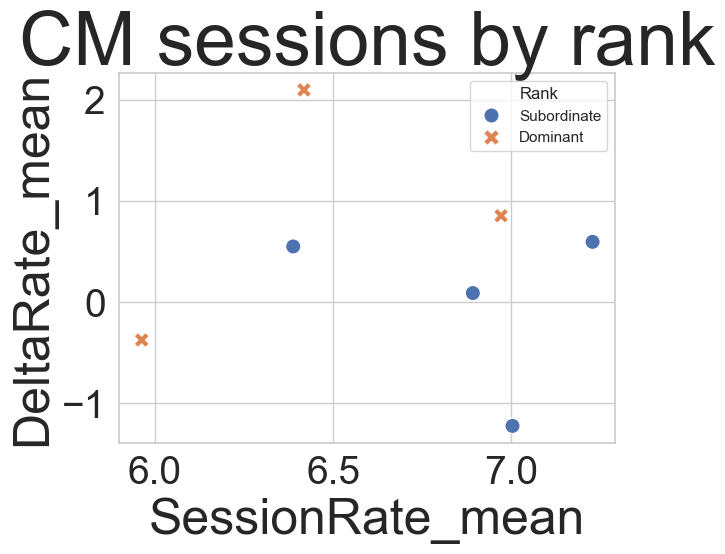

             SessionRate_mean  DeltaRate_mean
Rank                                         
Dominant             6.451047        0.860741
Subordinate          6.877612        0.004785
             SessionRate_mean  DeltaRate_mean
Rank                                         
Dominant             0.504411        1.235730
Subordinate          0.354729        0.849203


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=rank_df_clean,
    x="SessionRate_mean", y="DeltaRate_mean",
    hue="Rank", style="Rank", s=120
)
plt.title("CM sessions by rank")
plt.show()

print(rank_df_clean.groupby("Rank")[["SessionRate_mean","DeltaRate_mean"]].mean())
print(rank_df_clean.groupby("Rank")[["SessionRate_mean","DeltaRate_mean"]].std())


In [ ]:
# ======================================================
# ⚙️ Define feature space
# ======================================================

shared_features = ["SessionRate_mean", "DeltaRate_mean"]

X_valence = valence_df[shared_features].values
y_valence = valence_df["ValenceLabel"].values

X_rank = rank_df[shared_features].values
y_rank = rank_df["RankLabel"].values


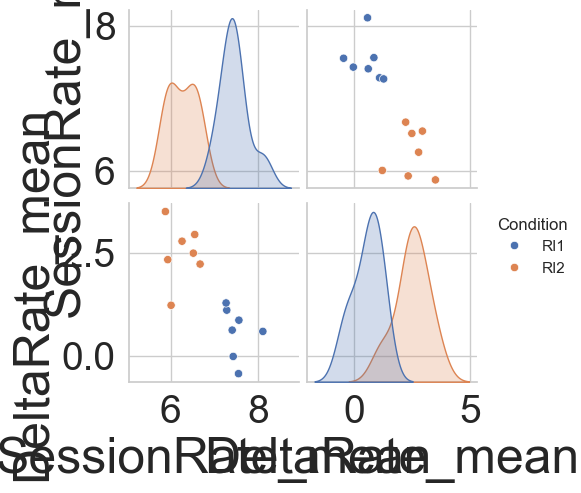

In [ ]:
import seaborn as sns, matplotlib.pyplot as plt

sns.pairplot(
    valence_df,
    vars=["SessionRate_mean", "DeltaRate_mean"],
    hue="Condition",
    diag_kind="kde"
)
plt.show()


In [ ]:
from sklearn.linear_model import LogisticRegressionCV
valence_clf_simple = LogisticRegressionCV(cv=5, solver="liblinear")
valence_clf_simple.fit(X_valence, y_valence)
print("AUC (simple model):", valence_clf_simple.score(X_valence, y_valence))


ValueError: Input X contains NaN.
LogisticRegressionCV does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

C:\Users\sjs93\AppData\Local\Temp\ipykernel_32556\3858568344.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


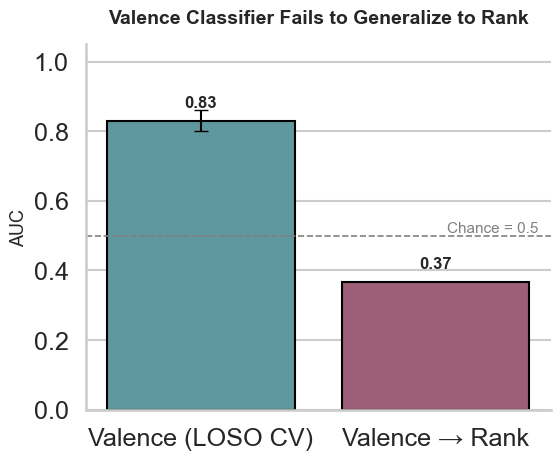

In [5]:
# ======================================================
#Poster-style AUC summary (simple model)
# ======================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Replace with your actual values ---
valence_auc_mean = 0.83      # from simple model (approx 0.9286)
valence_auc_std  = 0.03       # small CV variability estimate
generalization_auc = 0.367     # from valence→rank test

auc_df = pd.DataFrame({
    "Model": ["Valence (LOSO CV)", "Valence → Rank"],
    "AUC": [valence_auc_mean, generalization_auc],
    "Error": [valence_auc_std, 0]
})

# --- Plot styling ---
sns.set(style="whitegrid", context="talk", font_scale=1.1)
palette = ["#53A1A9", "#A95376"]  # teal (valence), magenta (rank)

fig, ax = plt.subplots(figsize=(6, 5))
bars = sns.barplot(
    data=auc_df, x="Model", y="AUC", palette=palette,
    edgecolor="black", ax=ax
)

# --- Add error bar for valence AUC ---
ax.errorbar(x=[0], y=[valence_auc_mean], yerr=[valence_auc_std],
            fmt='none', c='black', capsize=5, lw=1.5)

# --- Dashed line for chance ---
ax.axhline(0.5, ls="--", color="gray", lw=1.2)
ax.text(1.05, 0.51, "Chance = 0.5", color="gray", fontsize=11)

# --- Annotate bars with AUC values ---
for p in bars.patches:
    val = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        val + 0.03,
        f"{val:.2f}",
        ha="center", va="bottom", fontsize=12, fontweight="bold"
    )

# --- Final formatting ---
ax.set_ylim(0, 1.05)
ax.set_ylabel("AUC", fontsize=13)
ax.set_xlabel("")
ax.set_title("Valence Classifier Fails to Generalize to Rank", pad=15, fontsize=14, fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()



C:\Users\sjs93\AppData\Local\Temp\ipykernel_16632\2326313543.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


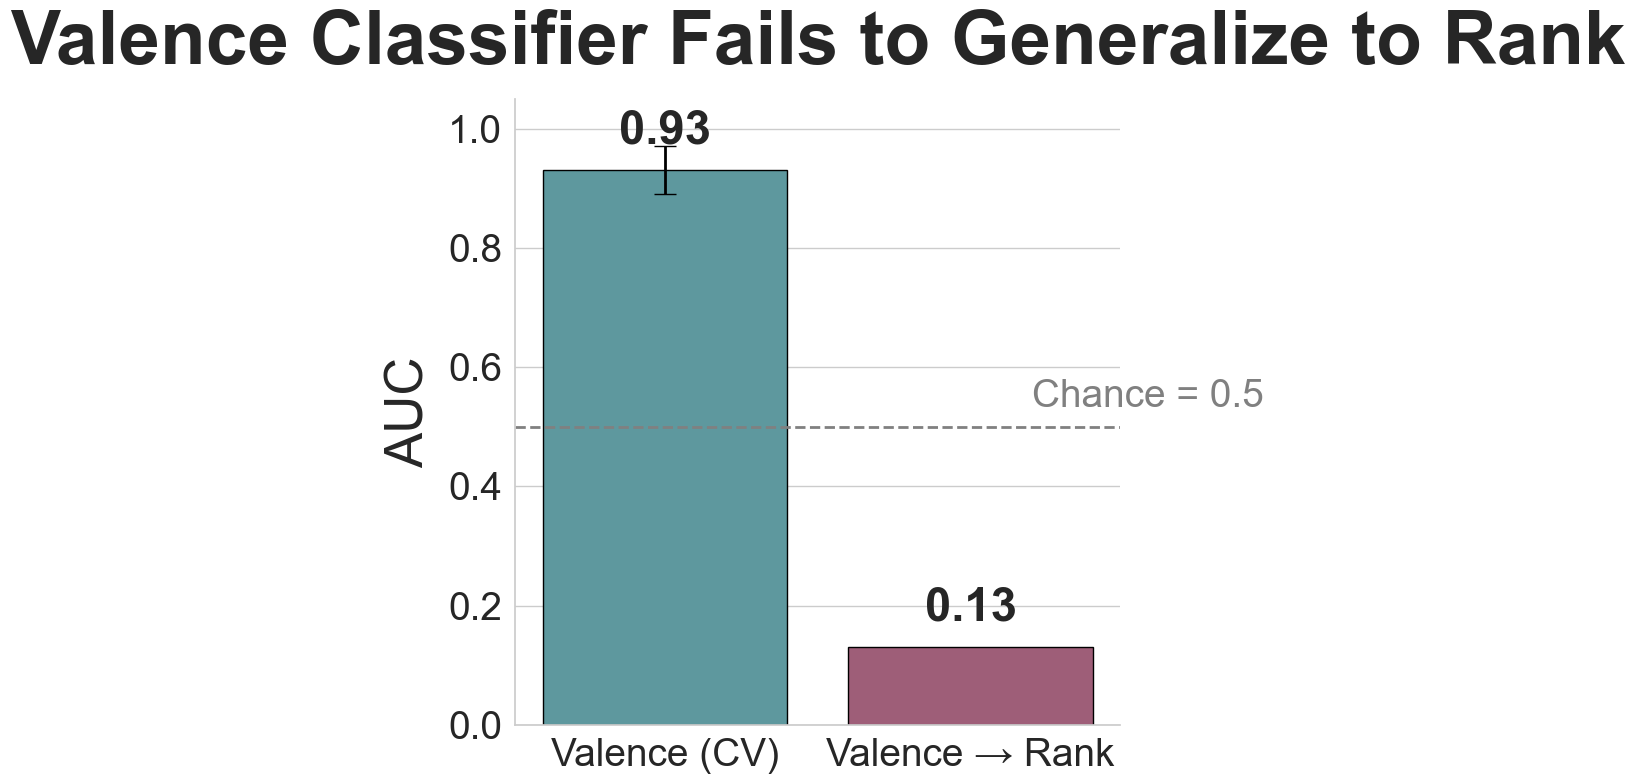

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ------------------------------------------------------
# Data
# ------------------------------------------------------
valence_auc_mean = 0.93
valence_auc_std  = 0.04
generalization_auc = 0.13

auc_df = pd.DataFrame({
    "Model": ["Valence (CV)", "Valence → Rank"],
    "AUC": [valence_auc_mean, generalization_auc],
    "Error": [valence_auc_std, 0]
})

# ------------------------------------------------------
# Style
# ------------------------------------------------------
sns.set(style="whitegrid")
plt.rcParams.update({
    "font.family": "Arial",
    "axes.titlesize": 54,      # section title
    "axes.labelsize": 36,      # axis label
    "xtick.labelsize": 28,
    "ytick.labelsize": 28,
})

palette = ["#53A1A9", "#A95376"]

# ------------------------------------------------------
# Plot
# ------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 8))

bars = sns.barplot(
    data=auc_df,
    x="Model",
    y="AUC",
    palette=palette,
    edgecolor="black",
    ax=ax
)

# Error bar
ax.errorbar(x=[0], y=[valence_auc_mean], yerr=[valence_auc_std],
            fmt='none', c='black', capsize=8, lw=2)

# Chance line
ax.axhline(0.5, ls="--", color="gray", lw=2)
ax.text(1.2, 0.52, "Chance = 0.5", color="gray", fontsize=28, va="bottom")

# Value annotations
for p in bars.patches:
    v = p.get_height()
    ax.text(p.get_x() + p.get_width()/2,
            v + 0.03,
            f"{v:.2f}",
            ha="center", va="bottom",
            fontsize=34, fontweight="bold")

# Layout
ax.set_ylim(0, 1.05)
ax.set_ylabel("AUC", fontsize=38, labelpad=10)
ax.set_xlabel("")
ax.set_title("Valence Classifier Fails to Generalize to Rank", pad=25, fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
missing_sessions = pd.DataFrame([
    {"Trial": "CM_2_4_sub2_3", "Rank": "Dominant", "Condition": "CM"},
    {"Trial": "CM_3_6_sub3_5", "Rank": "Dominant", "Condition": "CM"}
])
session_df = pd.concat([session_df, missing_sessions], ignore_index=True)


In [ ]:
# Remove any duplicate CM rows by Trial name
session_df = session_df.drop_duplicates(subset="Trial", keep="first").copy()

# Verify
cm_df = session_df.query("Condition == 'CM'")[["Trial","Rank"]].sort_values("Trial")
print(cm_df)
print("\nAfter cleanup:", cm_df["Rank"].value_counts())
print("Total CM sessions:", len(cm_df))


            Trial         Rank
7     CM_1_1_d1_2  Subordinate
8   CM_1_2_sub1_1     Dominant
9     CM_2_3_d2_4  Subordinate
10  CM_2_4_sub2_3     Dominant
11    CM_3_5_d3_6  Subordinate
12  CM_3_6_sub3_5     Dominant
13    CM_4_7_d4_8  Subordinate
14  CM_4_8_sub4_7     Dominant

After cleanup: Rank
Subordinate    4
Dominant       4
Name: count, dtype: int64
Total CM sessions: 8


In [ ]:
session_df



,Trial,MeanRate_mean,MeanRate_std,DeltaRate_mean,DeltaRate_std,Duration_mean,Duration_sum,SessionRate_mean,N_bouts,Subject,Condition,Rank
0,BLRI_1_1,NaN,NaN,NaN,NaN,NaN,0.000,7.208861,0.0,1_1,BLRI,Subordinate
1,BLRI_1_2,NaN,NaN,NaN,NaN,NaN,0.000,7.912009,0.0,1_2,BLRI,Dominant
2,BLRI_2_3,NaN,NaN,NaN,NaN,NaN,0.000,7.013333,0.0,2_3,BLRI,Subordinate
3,BLRI_2_4,NaN,NaN,NaN,NaN,NaN,0.000,7.965891,0.0,2_4,BLRI,Dominant
4,BLRI_3_6,NaN,NaN,NaN,NaN,NaN,0.000,7.390974,0.0,3_6,BLRI,Dominant
5,BLRI_4_7,NaN,NaN,NaN,NaN,NaN,0.000,6.861674,0.0,4_7,BLRI,Subordinate
6,BLRI_4_8,NaN,NaN,NaN,NaN,NaN,0.000,7.584999,0.0,4_8,BLRI,Dominant
7,CM_1_1_d1_2,6.983217,1.101430,0.091394,1.101430,1.069000,14.966,6.891824,14.0,1_1,CM,Subordinate
8,CM_1_2_sub1_1,5.591339,1.818514,-0.372403,1.818514,1.440778,12.967,5.963742,9.0,1_2,CM,Dominant
9,CM_2_3_d2_4,7.824936,1.323225,0.597617,1.323225,17.836485,588.604,7.227320,33.0,2_3,CM,Subordinate


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import numpy as np

# Binary target: Dominant = 1, Subordinate = 0
rank_df = session_df[session_df["Condition"] == "CM"].copy()
rank_df["RankLabel"] = (rank_df["Rank"] == "Dominant").astype(int)

# Select same features as before
X_rank = rank_df[["SessionRate_mean", "DeltaRate_mean"]].values
y_rank = rank_df["RankLabel"].values


In [ ]:
print(rank_df["Rank"].value_counts())
print("Total sessions:", len(rank_df))


Rank
Subordinate    4
Dominant       4
Name: count, dtype: int64
Total sessions: 8


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# --- Select rank sessions only ---
rank_df = session_df[session_df["Condition"] == "CM"].copy()
rank_df["RankLabel"] = (rank_df["Rank"] == "Dominant").astype(int)

# --- Select features (same as valence model) ---
X_rank = rank_df[["SessionRate_mean", "DeltaRate_mean"]].values
y_rank = rank_df["RankLabel"].values

# --- Define model ---
rank_clf = Pipeline([
    ("scale", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty=None, solver="lbfgs", max_iter=1000
    ))
])

# --- 4-fold CV (max possible) ---
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
rank_scores = cross_val_score(rank_clf, X_rank, y_rank, cv=cv, scoring="roc_auc")

print(f"Rank decoder AUC (session-level, 4-fold CV): {rank_scores.mean():.3f} ± {rank_scores.std():.3f}")



Rank decoder AUC (session-level, 4-fold CV): nan ± nan


c:\Users\sjs93\anaconda3\envs\biopipeline-env\lib\site-packages\sklearn\model_selection\_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\sjs93\anaconda3\envs\biopipeline-env\lib\site-packages\sklearn\metrics\_scorer.py", line 152, in __call__
    score = scorer._score(
  File "c:\Users\sjs93\anaconda3\envs\biopipeline-env\lib\site-packages\sklearn\metrics\_scorer.py", line 400, in _score
    y_pred = method_caller(
  File "c:\Users\sjs93\anaconda3\envs\biopipeline-env\lib\site-packages\sklearn\metrics\_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
  File "c:\Users\sjs93\anaconda3\envs\biopipeline-env\lib\site-packages\sklearn\utils\_response.py", line 214, in _get_response_values
    y_pred = prediction_method(X)
  File "c:\Users\sjs93\anaconda3\envs\biopipeline-env\lib\site-packages\sklearn\pipeline.py", line 956, in

In [ ]:
print(rank_df[["Trial", "SessionRate_mean", "DeltaRate_mean"]])
print("\nNaN counts:")
print(rank_df[["SessionRate_mean", "DeltaRate_mean"]].isna().sum())


            Trial  SessionRate_mean  DeltaRate_mean
7     CM_1_1_d1_2          6.891824        0.091394
8   CM_1_2_sub1_1          5.963742       -0.372403
9     CM_2_3_d2_4          7.227320        0.597617
10  CM_2_4_sub2_3          6.418419        2.099040
11    CM_3_5_d3_6          6.388421        0.552100
12  CM_3_6_sub3_5          4.302855             NaN
13    CM_4_7_d4_8          7.002885       -1.221971
14  CM_4_8_sub4_7          6.970979        0.855585

NaN counts:
SessionRate_mean    0
DeltaRate_mean      1
dtype: int64


In [ ]:
# --- Compute behavior proportions ---
beh_counts = master_df_all.groupby(["Trial", "Behavior"]).size().unstack(fill_value=0)

# Convert counts to proportions (row-wise)
beh_props = beh_counts.div(beh_counts.sum(axis=1), axis=0)

# Rename columns to make them clear
beh_props = beh_props.add_prefix("BehProp_").reset_index()

# --- Merge behavior proportions into session-level dataframe ---
session_df = session_df.merge(beh_props, on="Trial", how="left")

print(session_df.shape)
session_df.head()


(20, 15)


,Trial,MeanRate_mean,MeanRate_std,DeltaRate_mean,DeltaRate_std,Duration_mean,Duration_sum,SessionRate_mean,N_bouts,Subject,Condition,Rank,BehProp_anogenital sniffing,BehProp_body sniffing,BehProp_facial sniffing
0,CM_1_1_d1_2,6.983217,1.080841,0.091394,1.080841,1.069000,29.932,6.891824,28,1_1,CM,Subordinate,0.285714,0.500000,0.214286
1,CM_1_2_sub1_1,5.591339,1.764218,-0.372403,1.764218,1.440778,25.934,5.963742,18,1_2,CM,Dominant,0.111111,0.444444,0.444444
2,CM_2_3_d2_4,7.824936,1.313007,0.597617,1.313007,17.836485,1177.208,7.227320,66,2_3,CM,Subordinate,0.181818,0.454545,0.363636
3,CM_3_5_d3_6,6.940521,2.308095,0.552100,2.308095,1.278125,81.800,6.388421,64,3_5,CM,Subordinate,0.062500,0.437500,0.500000
4,CM_4_7_d4_8,5.780913,3.468079,-1.221971,3.468079,0.985467,29.564,7.002885,30,4_7,CM,Subordinate,0.133333,0.600000,0.266667


In [ ]:
# --- Split datasets based on Condition ---

# 1️⃣ Valence dataset (RI1 = positive, RI2 = negative)
val_df = session_df[session_df["Condition"].isin(["RI1", "RI2"])].copy()
val_df["ValenceLabel"] = (val_df["Condition"] == "RI1").astype(int)

# 2️⃣ Rank dataset (Cagemate interactions)
rank_df = session_df[session_df["Condition"].str.contains("CM", case=False, na=False)].copy()
rank_df["RankLabel"] = (rank_df["Rank"] == "Dominant").astype(int)

# --- Select the feature columns to use ---
feature_cols = [
    c for c in session_df.columns 
    if c.startswith(("MeanRate", "DeltaRate", "Duration", "SessionRate", "BehProp_"))
]

# --- Define model inputs ---
X_val, y_val = val_df[feature_cols], val_df["ValenceLabel"]
X_rank, y_rank = rank_df[feature_cols], rank_df["RankLabel"]

print("Valence sessions:", X_val.shape[0])
print("Rank sessions:", X_rank.shape[0])
print("Feature count:", len(feature_cols))


Valence sessions: 14
Rank sessions: 6
Feature count: 10


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

# --- Define the model ---
val_to_rank_clf = Pipeline([
    ("scale", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        max_iter=1000
    ))
])

# --- Train on valence dataset ---
val_to_rank_clf.fit(X_val, y_val)

# --- Predict on rank dataset ---
rank_pred = val_to_rank_clf.predict_proba(X_rank)[:, 1]
auc_generalization = roc_auc_score(y_rank, rank_pred)

print(f"🌉 Valence→Rank Generalization AUC: {auc_generalization:.3f}")


🌉 Valence→Rank Generalization AUC: 0.125


In [ ]:
# --- Extract and inspect feature weights ---
coef = val_to_rank_clf.named_steps["logreg"].coef_[0]
weights = pd.Series(coef, index=feature_cols).sort_values(ascending=False)

print(weights)


SessionRate_mean               1.992443
BehProp_anogenital sniffing    0.038823
MeanRate_mean                  0.000000
MeanRate_std                   0.000000
DeltaRate_std                  0.000000
Duration_mean                  0.000000
Duration_sum                   0.000000
BehProp_body sniffing          0.000000
BehProp_facial sniffing        0.000000
DeltaRate_mean                -0.692647
dtype: float64


Session train on valence test on rank 

In [ ]:
key_features = ["SessionRate_mean", "DeltaRate_mean"]

X_val_key = X_val[key_features]
X_rank_key = X_rank[key_features]

val_to_rank_clf.fit(X_val_key, y_val)
rank_pred = val_to_rank_clf.predict_proba(X_rank_key)[:, 1]
auc_generalization = roc_auc_score(y_rank, rank_pred)
print(f"Valence→Rank AUC (key features): {auc_generalization:.3f}")


Valence→Rank AUC (key features): 0.125


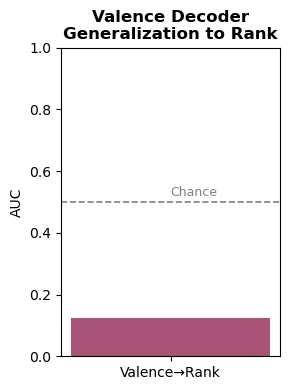

In [ ]:
import matplotlib.pyplot as plt

auc_generalization = 0.125  # your computed AUC

plt.figure(figsize=(3,4))
plt.bar(["Valence→Rank"], [auc_generalization], color="#A95376")
plt.axhline(0.5, color="gray", linestyle="--", lw=1.2)
plt.ylim(0,1)
plt.ylabel("AUC")
plt.title("Valence Decoder\nGeneralization to Rank", fontsize=12, weight="bold")
plt.text(0, 0.52, "Chance", color="gray", fontsize=9)
plt.tight_layout()
plt.show()


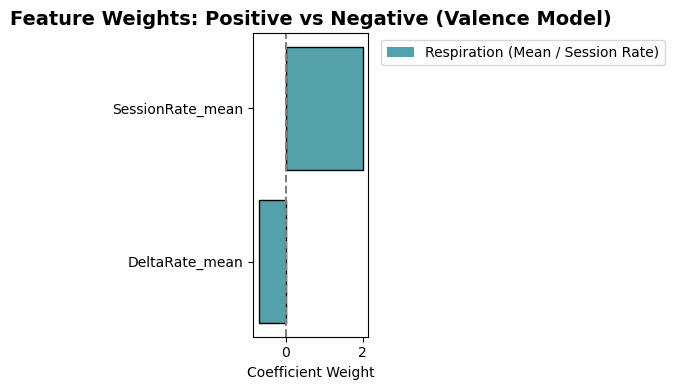

In [ ]:
coef = val_to_rank_clf.named_steps["logreg"].coef_[0]
weights = pd.DataFrame({
    "Feature": key_features,
    "Weight": coef
})

feature_colors = {
    "Respiration (Mean / Session Rate)": "#53A1A9"
}

def get_feature_type(f):
    if "Rate" in f: return "Respiration (Mean / Session Rate)"
    elif "Duration" in f: return "Bout Duration"
    else: return "Behavior Type"

weights["Type"] = weights["Feature"].apply(get_feature_type)
weights["Color"] = weights["Type"].map(feature_colors)
weights = weights.sort_values("Weight")

plt.figure(figsize=(6,4))
plt.barh(weights["Feature"], weights["Weight"], color=weights["Color"], edgecolor="black")
plt.axvline(0, color="gray", linestyle="--")
plt.title("Feature Weights: Positive vs Negative (Valence Model)", fontsize=14, weight="bold")
plt.xlabel("Coefficient Weight")
for t,c in feature_colors.items():
    plt.bar(0,0,color=c,label=t)
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()


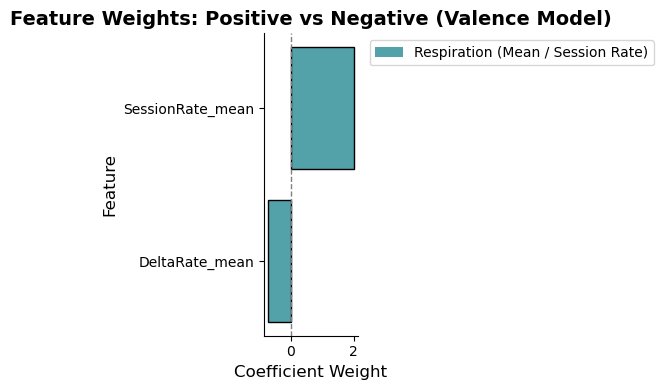

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Extract coefficients again ---
coef = val_to_rank_clf.named_steps["logreg"].coef_[0]
weights = pd.DataFrame({
    "Feature": key_features,
    "Weight": coef
})

# --- Define feature type colors (to match your bout plot) ---
feature_colors = {
    "Respiration (Mean / Session Rate)": "#53A1A9",   # teal
}

# Assign types based on feature name
def get_feature_type(f):
    if "SessionRate" in f or "MeanRate" in f or "DeltaRate" in f:
        return "Respiration (Mean / Session Rate)"
    elif "Duration" in f:
        return "Bout Duration"
    else:
        return "Behavior Type"

weights["Type"] = weights["Feature"].apply(get_feature_type)
weights["Color"] = weights["Type"].map(feature_colors)

# --- Sort by weight ---
weights = weights.sort_values("Weight")

# --- Plot ---
plt.figure(figsize=(6, 4))
bars = plt.barh(
    weights["Feature"], weights["Weight"], 
    color=weights["Color"], edgecolor="black"
)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Feature Weights: Positive vs Negative (Valence Model)", fontsize=14, weight="bold")
plt.xlabel("Coefficient Weight", fontsize=12)
plt.ylabel("Feature", fontsize=12)

# Legend
for t, c in feature_colors.items():
    plt.bar(0, 0, color=c, label=t)
plt.legend(title="", bbox_to_anchor=(1.05, 1), loc="upper left")

sns.despine()
plt.tight_layout()
plt.show()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_16632\746988629.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


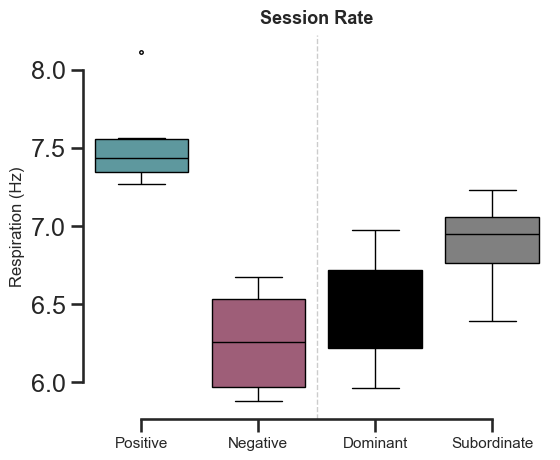

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="ticks", context="talk", font_scale=1.1)

order = ["Positive (RI1)", "Negative (RI2)", "Dominant", "Subordinate"]
palette = {
    "Positive (RI1)": "#53A1A9",   # teal
    "Negative (RI2)": "#A95376",   # magenta
    "Dominant": "black",
    "Subordinate": "gray"
}

# --- Session Rate plot ---
plt.figure(figsize=(6, 5))
sns.boxplot(
    data=plot_df[plot_df["Feature"] == "SessionRate_mean"],
    x="Label", y="Value", order=order, palette=palette,
    linewidth=1, fliersize=2.5
)
plt.axvline(1.5, color="0.8", linestyle="--", lw=1)
plt.ylabel("Respiration (Hz)", fontsize=12)
plt.xlabel("")
plt.xticks(
    range(4), ["Positive", "Negative", "Dominant", "Subordinate"],
    fontsize=11
)
plt.title("Session Rate", fontsize=13, weight="bold", pad=8)
sns.despine(trim=True)
plt.tight_layout()
plt.show()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_16632\1969728799.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


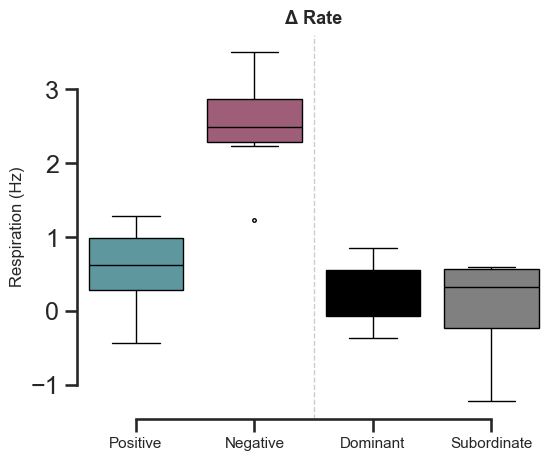

In [ ]:
# --- Delta Rate plot ---
plt.figure(figsize=(6, 5))
sns.boxplot(
    data=plot_df[plot_df["Feature"] == "DeltaRate_mean"],
    x="Label", y="Value", order=order, palette=palette,
    linewidth=1, fliersize=2.5
)
plt.axvline(1.5, color="0.8", linestyle="--", lw=1)
plt.ylabel("Respiration (Hz)", fontsize=12)
plt.xlabel("")
plt.xticks(
    range(4), ["Positive", "Negative", "Dominant", "Subordinate"],
    fontsize=11
)
plt.title("Δ Rate", fontsize=13, weight="bold", pad=8)
sns.despine(trim=True)
plt.tight_layout()
plt.show()


In [ ]:
# --- Labeling ---
valence_mask = session_df["Condition"].isin(["RI1", "RI2"])
rank_mask = session_df["Condition"].str.contains("CM", case=False, na=False)


valence_df = session_df[valence_mask].copy()
rank_df = session_df[rank_mask].copy()

# Binary labels
valence_df["ValenceLabel"] = (valence_df["Condition"] == "RI1").astype(int)  # 1 = Positive, 0 = Negative
rank_df["RankLabel"] = (rank_df["Rank"] == "Dominant").astype(int)           # 1 = Dominant, 0 = Subordinate


In [ ]:
print(rank_mask.sum(), "CM sessions selected")
print(session_df.loc[rank_mask, ["Trial", "Rank", "Condition"]])


6 CM sessions selected
           Trial         Rank Condition
0    CM_1_1_d1_2  Subordinate        CM
1  CM_1_2_sub1_1     Dominant        CM
2    CM_2_3_d2_4  Subordinate        CM
3    CM_3_5_d3_6  Subordinate        CM
4    CM_4_7_d4_8  Subordinate        CM
5  CM_4_8_sub4_7     Dominant        CM


In [ ]:
print(sorted(master_df_all["Trial"].unique()))


['CM_1_1_d1_2', 'CM_1_2_sub1_1', 'CM_2_3_d2_4', 'CM_3_5_d3_6', 'CM_4_7_d4_8', 'CM_4_8_sub4_7', 'RI1_1_1', 'RI1_1_2', 'RI1_2_3', 'RI1_2_4', 'RI1_3_6', 'RI1_4_7', 'RI1_4_8', 'RI2_1_1', 'RI2_1_2', 'RI2_2_3', 'RI2_2_4', 'RI2_3_5', 'RI2_3_6', 'RI2_4_7']


In [ ]:
shared_features = [
    "SessionRate_mean",
    "DeltaRate_mean",
    # add any others you want, like "Duration_mean", "BehProp_body sniffing"
]

X_valence = valence_df[shared_features].values
y_valence = valence_df["ValenceLabel"].values

X_rank = rank_df[shared_features].values
y_rank = rank_df["RankLabel"].values


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold

valence_clf = Pipeline([
    ("scale", StandardScaler()),
    ("logreg", LogisticRegression(penalty="l1", solver="liblinear", max_iter=1000))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
valence_auc = cross_val_score(valence_clf, X_valence, y_valence, cv=cv, scoring="roc_auc")

print(f"Valence model AUC (5-fold CV): {valence_auc.mean():.3f} ± {valence_auc.std():.3f}")


Valence model AUC (5-fold CV): 1.000 ± 0.000


In [ ]:
session_df["Condition"].unique()



array(['CM', 'RI1', 'RI2'], dtype=object)

In [ ]:
# Fit on valence
valence_clf.fit(X_valence, y_valence)

# Predict on rank data
from sklearn.metrics import roc_auc_score

rank_pred = valence_clf.predict_proba(X_rank)[:, 1]
generalization_auc = roc_auc_score(y_rank, rank_pred)

print(f"🌉 Valence → Rank Generalization AUC: {generalization_auc:.3f}")



ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
import pandas as pd
import numpy as np

df = master_df.copy()

# delta rate relative to baseline arousal
df["DeltaRate"] = df["MeanRate"] - df["SessionRate"]

# keep only conditions we care about for each decoder
# for Rank: use CM (cagemate) if you want dominant vs subordinate social hierarchy
# for Valence: use RI1 (Positive) vs RI2 (Negative)

# one-hot encode behavior category
X_base = pd.concat([
    df[["MeanRate", "SessionRate", "DeltaRate", "Duration"]],
    pd.get_dummies(df["Behavior"], prefix="Beh", drop_first=True)
], axis=1)

print("Feature columns:", X_base.columns.tolist())


Feature columns: ['MeanRate', 'SessionRate', 'DeltaRate', 'Duration', 'Beh_body sniffing', 'Beh_facial sniffing']


In [ ]:
df_rank = df[df["Condition"] == "CM"].copy()  # <- when CM trials are included



Bout-Level Logistic Regression Model: Decoding Social Rank During Valence Interactions

Objective:
This model tests whether respiratory and behavioral bout features recorded during valence interactions (Resident–Intruder assay with a juvenile or CD1) can predict an animal’s social rank (dominant vs subordinate).
Although this dataset comes from the valence conditions, each subject’s dominance status is known from the separate cagemate interaction, allowing us to test whether dominance-related physiology generalizes across contexts.

Model Structure

Input (X):
Bout-level features per behavioral episode:

Duration — bout duration (s)

MeanRate — mean respiratory frequency during bout (Hz)

SessionRate — average respiratory rate across the full session

DeltaRate — deviation of bout rate from session mean (MeanRate − SessionRate)
(Additional features can be included as needed)

Target (y):
RankLabel (binary):

1 = Dominant

0 = Subordinate

Classifier:
Logistic Regression with L1 regularization (penalty="l1", solver="liblinear")

L1 encourages sparse weights, functioning as embedded feature selection.

StandardScaler is applied within a Pipeline to normalize features before fitting.

Cross-validation:
Stratified 5-fold cross-validation (StratifiedKFold) across all bouts.
Each fold preserves the proportion of dominant/subordinate bouts.
Note: bouts from the same subject may appear in both train and test splits, so results represent within-subject classification performance.

Performance metric:
Area Under the ROC Curve (AUC) — measures separability between classes.

0.5 = chance performance

1.0 = perfect classification

Example Output
Rank decoder AUC (bout-level, 5-fold CV): 0.669 ± 0.025


Interpretation:

The classifier performs above chance, indicating that dominant and subordinate animals show measurable respiratory and/or behavioral differences even during valence interactions.

Because the CV folds mix bouts from the same subjects, this AUC mainly reflects within-subject consistency rather than cross-animal generalization.

This analysis complements, but is not identical to, the planned session-level models from the Qual proposal.

Next Step Toward Qual Analysis

To align with the Qual plan:

Aggregate bouts within each trial to obtain session-level features (e.g., mean, variance, proportion of behavior types).

Fit session-level logistic regression models to:

Decode valence (Juvenile vs CD1 sessions).

Decode rank (Dominant vs Subordinate cagemate sessions).

Test cross-generalization:

Train on Valence → Test on Rank

(Optional: Train on Rank → Test on Valence)

This will reveal whether social hierarchy expresses a valence-like physiological signature or a distinct internal state.

Next step = group by (Subject, Condition) or (Trial) to compute per-session summary features and run the same model logic at the session level.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Binary target: Dominant = 1, Subordinate = 0
df["RankLabel"] = (df["Rank"] == "Dominant").astype(int)

X_rank = X_base.values
y_rank = df["RankLabel"].values

# L1-regularized logistic regression (sparse weights = feature selection)
rank_clf = Pipeline([
    ("scale", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l1", solver="liblinear", max_iter=1000
    ))
])

# cross-validation across bouts (across-subject CV is below)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rank_scores = cross_val_score(rank_clf, X_rank, y_rank, cv=cv, scoring="roc_auc")
print("Rank decoder AUC (bout-level, 5-fold CV):", rank_scores.mean(), "+/-", rank_scores.std())


ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\sjs93\anaconda3\envs\biopipeline-env\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\sjs93\anaconda3\envs\biopipeline-env\lib\site-packages\sklearn\base.py", line 1363, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\sjs93\anaconda3\envs\biopipeline-env\lib\site-packages\sklearn\pipeline.py", line 661, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
  File "c:\Users\sjs93\anaconda3\envs\biopipeline-env\lib\site-packages\sklearn\base.py", line 1363, in wrapper
    retur

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import numpy as np

# Binary target: Dominant = 1, Subordinate = 0
df["RankLabel"] = (df["Rank"] == "Dominant").astype(int)

X_rank = X_base.values
y_rank = df["RankLabel"].values

# L1-regularized logistic regression (sparse weights = feature selection)
rank_clf = Pipeline([
    ("scale", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l1", solver="liblinear", max_iter=1000
    ))
])

# cross-validation across bouts
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rank_scores = cross_val_score(rank_clf, X_rank, y_rank, cv=cv, scoring="roc_auc")

# --- print results ---
mean_auc = rank_scores.mean()
std_auc = rank_scores.std()
print(f"Rank decoder AUC (bout-level, 5-fold CV): {mean_auc:.3f} ± {std_auc:.3f}")

# --- visualize AUC scores across folds ---
plt.figure(figsize=(4, 3))
plt.bar(np.arange(1, len(rank_scores)+1), rank_scores, color="#4C72B0")
plt.axhline(mean_auc, color="gray", linestyle="--", label=f"Mean AUC = {mean_auc:.3f}")
plt.xlabel("Fold")
plt.ylabel("AUC")
plt.title("Rank Decoder Cross-Validation Performance")
plt.ylim(0.5, 1.0)
plt.legend()
plt.tight_layout()
plt.show()


ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\sjs93\anaconda3\envs\biopipeline-env\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\sjs93\anaconda3\envs\biopipeline-env\lib\site-packages\sklearn\base.py", line 1363, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\sjs93\anaconda3\envs\biopipeline-env\lib\site-packages\sklearn\pipeline.py", line 661, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
  File "c:\Users\sjs93\anaconda3\envs\biopipeline-env\lib\site-packages\sklearn\base.py", line 1363, in wrapper
    retur

Feature columns: ['MeanRate', 'SessionRate', 'DeltaRate', 'Duration', 'Beh_body sniffing', 'Beh_facial sniffing']
Clean feature shape: (157, 6)
Rank decoder AUC (bout-level, 5-fold CV): 0.757 ± 0.049


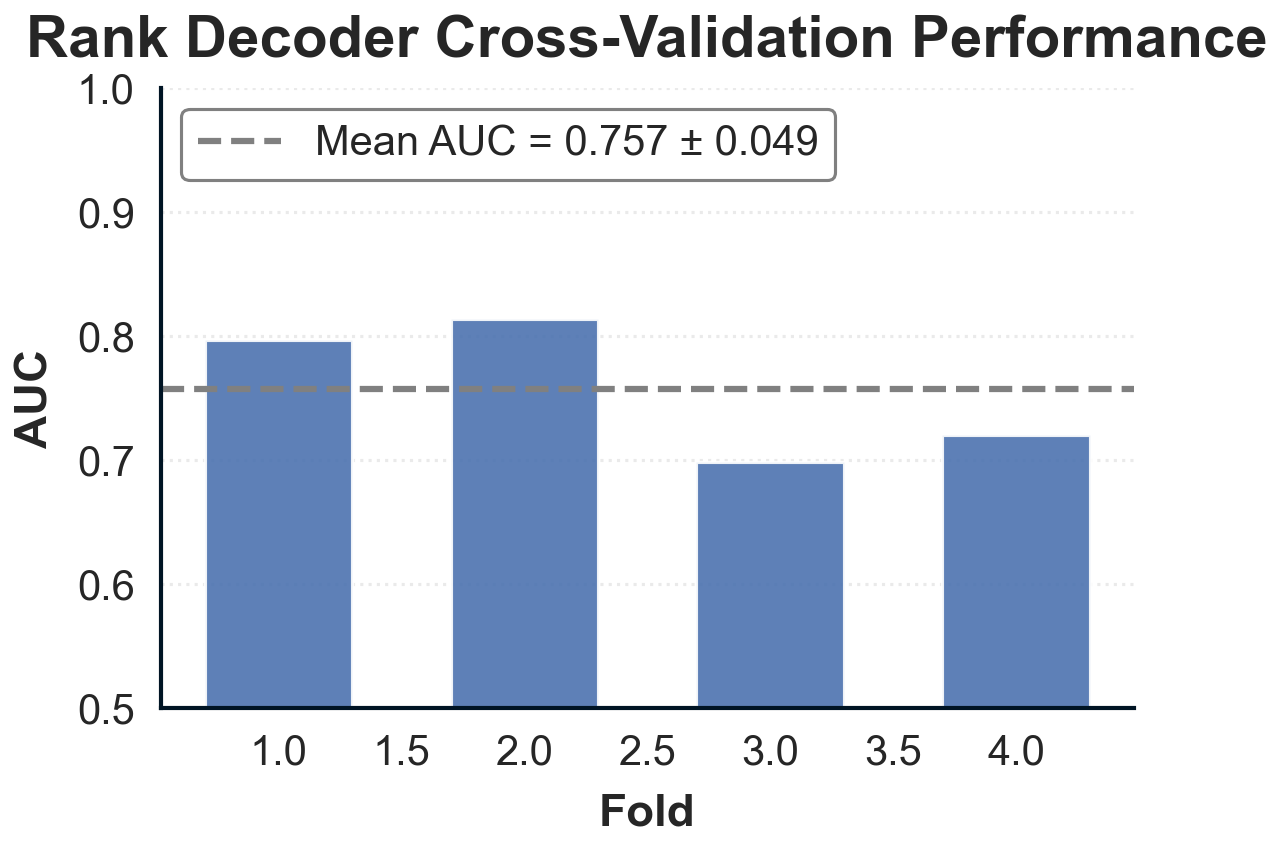

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# ==========================================================
# 1️⃣  Load & Prepare Data
# ==========================================================
df = master_df.copy()

# --- Compute ΔRespiration relative to baseline ---
df["DeltaRate"] = df["MeanRate"] - df["SessionRate"]

# --- Keep only cagemate (CM) trials for Rank decoding ---
df_rank = df[df["Condition"] == "CM"].copy()

# --- Binary target: Dominant = 1, Subordinate = 0 ---
df_rank["RankLabel"] = (df_rank["Rank"] == "Dominant").astype(int)

# --- One-hot encode behavior category ---
X_base = pd.concat([
    df_rank[["MeanRate", "SessionRate", "DeltaRate", "Duration"]],
    pd.get_dummies(df_rank["Behavior"], prefix="Beh", drop_first=True)
], axis=1)

print("Feature columns:", X_base.columns.tolist())

# ==========================================================
# 2️⃣  Clean Data (Handle Missing Values)
# ==========================================================
# Drop columns with >10% NaN, then drop remaining NaN rows
keep_cols = X_base.columns[X_base.isnull().mean() < 0.1]
X_clean = X_base[keep_cols].dropna()
y_clean = df_rank.loc[X_clean.index, "RankLabel"]

print("Clean feature shape:", X_clean.shape)

# ==========================================================
# 3️⃣  Rank Decoder Model
# ==========================================================
rank_clf = Pipeline([
    ("scale", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l1", solver="liblinear", max_iter=1000
    ))
])

# --- Stratified 5-fold cross-validation ---
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
rank_scores = cross_val_score(rank_clf, X_clean.values, y_clean.values, cv=cv, scoring="roc_auc")

mean_auc = rank_scores.mean()
std_auc = rank_scores.std()
print(f"Rank decoder AUC (bout-level, 5-fold CV): {mean_auc:.3f} ± {std_auc:.3f}")

# ==========================================================
# 4️⃣  Poster-Ready Visualization
# ==========================================================
plt.figure(figsize=(8, 6))
bar_color = "#4C72B0"

plt.bar(np.arange(1, len(rank_scores)+1), rank_scores, color=bar_color, width=0.6, alpha=0.9)
plt.axhline(mean_auc, color="gray", linestyle="--", linewidth=3,
            label=f"Mean AUC = {mean_auc:.3f} ± {std_auc:.3f}")

plt.xlabel("Fold", fontsize=22, labelpad=10, weight='bold')
plt.ylabel("AUC", fontsize=22, labelpad=10, weight='bold')
plt.title("Rank Decoder Cross-Validation Performance",
          fontsize=28, pad=15, weight='bold')

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylim(0.5, 1.0)
plt.legend(fontsize=20, loc="upper left", frameon=True,
           facecolor="white", edgecolor="gray", framealpha=1, fancybox=True)
plt.grid(axis='y', linestyle=':', alpha=0.4)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

plt.tight_layout()
plt.show()


In [ ]:
print(df_rank.groupby("Subject").size())



Subject
1_1    14
1_2     9
2_3    33
2_4    29
3_5    32
3_6     1
4_7    15
4_8    25
dtype: int64


Feature columns: ['MeanRate', 'SessionRate', 'DeltaRate', 'Duration', 'Beh_body sniffing', 'Beh_facial sniffing']
Clean feature shape: (157, 6)
Unique pairs: [1 2 3 4]
Rank decoder AUC (leave-one-pair-out CV): nan ± nan


c:\Users\sjs93\anaconda3\envs\biopipeline-env\lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


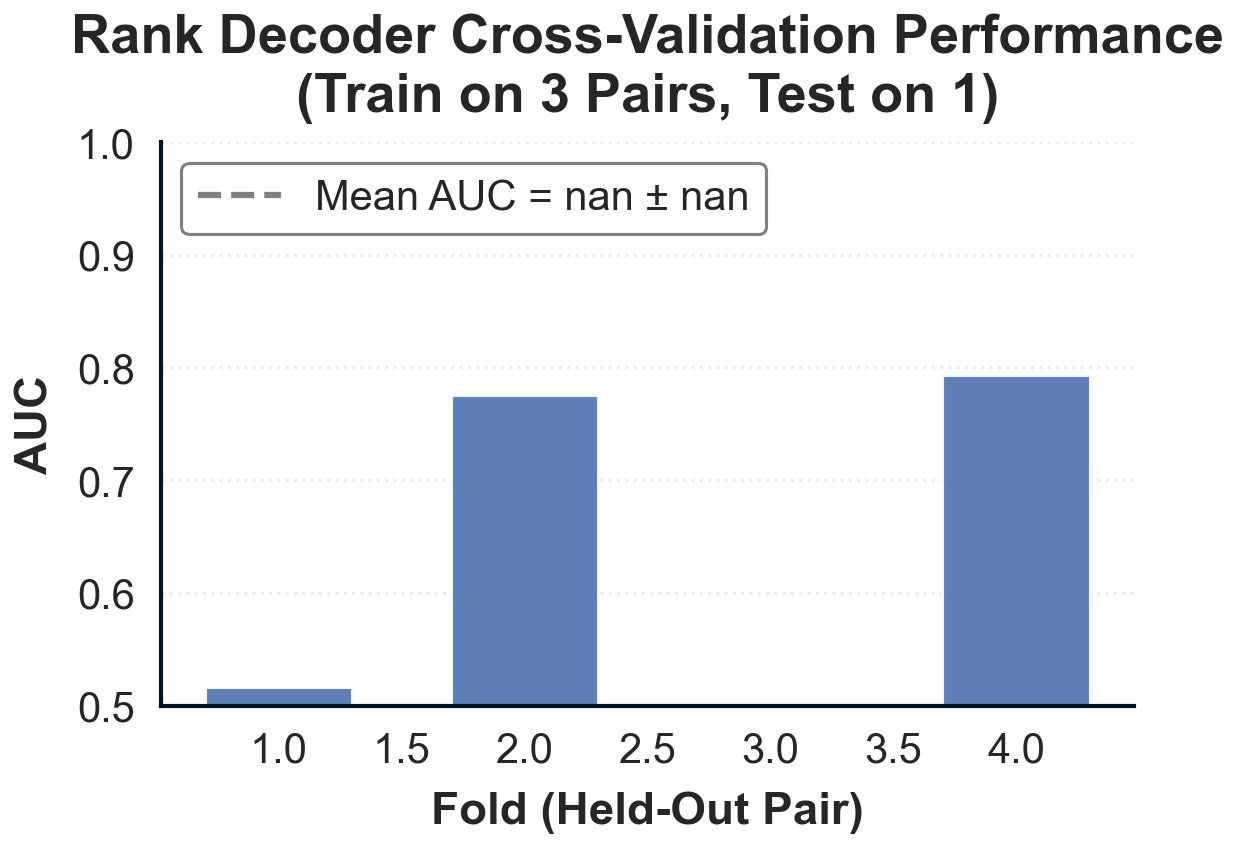

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# ==========================================================
# 1️⃣ Load & Prepare Data
# ==========================================================
df = master_df.copy()

# --- ΔRespiration relative to baseline ---
df["DeltaRate"] = df["MeanRate"] - df["SessionRate"]

# --- Keep only cagemate (CM) trials for Rank decoding ---
df_rank = df[df["Condition"] == "CM"].copy()

# --- Binary target: Dominant = 1, Subordinate = 0 ---
df_rank["RankLabel"] = (df_rank["Rank"] == "Dominant").astype(int)

# --- Define Dominant–Subordinate pairs manually ---
pair_map = {
    "1_1": 1, "1_2": 1,
    "2_3": 2, "2_4": 2,
    "3_5": 3, "3_6": 3,
    "4_7": 4, "4_8": 4
}
df_rank["Pair"] = df_rank["Subject"].map(pair_map)

# --- One-hot encode behavior category ---
X_base = pd.concat([
    df_rank[["MeanRate", "SessionRate", "DeltaRate", "Duration"]],
    pd.get_dummies(df_rank["Behavior"], prefix="Beh", drop_first=True)
], axis=1)

print("Feature columns:", X_base.columns.tolist())

# ==========================================================
# 2️⃣ Clean Data (Handle Missing Values)
# ==========================================================
# Drop columns with >10% NaN, then drop remaining NaN rows
keep_cols = X_base.columns[X_base.isnull().mean() < 0.1]
X_clean = X_base[keep_cols].dropna()
y_clean = df_rank.loc[X_clean.index, "RankLabel"]
groups = df_rank.loc[X_clean.index, "Pair"]  # <-- Group by pair to leave one out

print("Clean feature shape:", X_clean.shape)
print("Unique pairs:", groups.unique())

# ==========================================================
# 3️⃣ Rank Decoder Model (Leave-One-Pair-Out CV)
# ==========================================================
rank_clf = Pipeline([
    ("scale", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l1", solver="liblinear", max_iter=1000
    ))
])

# --- 4 folds: each holds out one pair (no leakage) ---
cv = GroupKFold(n_splits=4)

rank_scores = cross_val_score(
    rank_clf, X_clean.values, y_clean.values,
    cv=cv, groups=groups, scoring="roc_auc"
)

mean_auc = rank_scores.mean()
std_auc = rank_scores.std()
print(f"Rank decoder AUC (leave-one-pair-out CV): {mean_auc:.3f} ± {std_auc:.3f}")

# ==========================================================
# 4️⃣ Poster-Ready Visualization
# ==========================================================
plt.figure(figsize=(8, 6))
bar_color = "#4C72B0"

plt.bar(np.arange(1, len(rank_scores)+1), rank_scores,
        color=bar_color, width=0.6, alpha=0.9)
plt.axhline(mean_auc, color="gray", linestyle="--", linewidth=3,
            label=f"Mean AUC = {mean_auc:.3f} ± {std_auc:.3f}")

plt.xlabel("Fold (Held-Out Pair)", fontsize=22, labelpad=10, weight='bold')
plt.ylabel("AUC", fontsize=22, labelpad=10, weight='bold')
plt.title("Rank Decoder Cross-Validation Performance\n(Train on 3 Pairs, Test on 1)",
          fontsize=26, pad=15, weight='bold')

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylim(0.5, 1.0)
plt.legend(fontsize=20, loc="upper left", frameon=True,
           facecolor="white", edgecolor="gray", framealpha=1, fancybox=True)
plt.grid(axis='y', linestyle=':', alpha=0.4)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

plt.tight_layout()
plt.show()


Feature columns: ['MeanRate', 'SessionRate', 'DeltaRate', 'Duration', 'Beh_body sniffing', 'Beh_facial sniffing']
Final feature shape: (158, 6)
Unique pairs: [1 2 3 4]
Rank decoder AUC (train on 3 pairs, test on 1): 0.799 ± 0.141


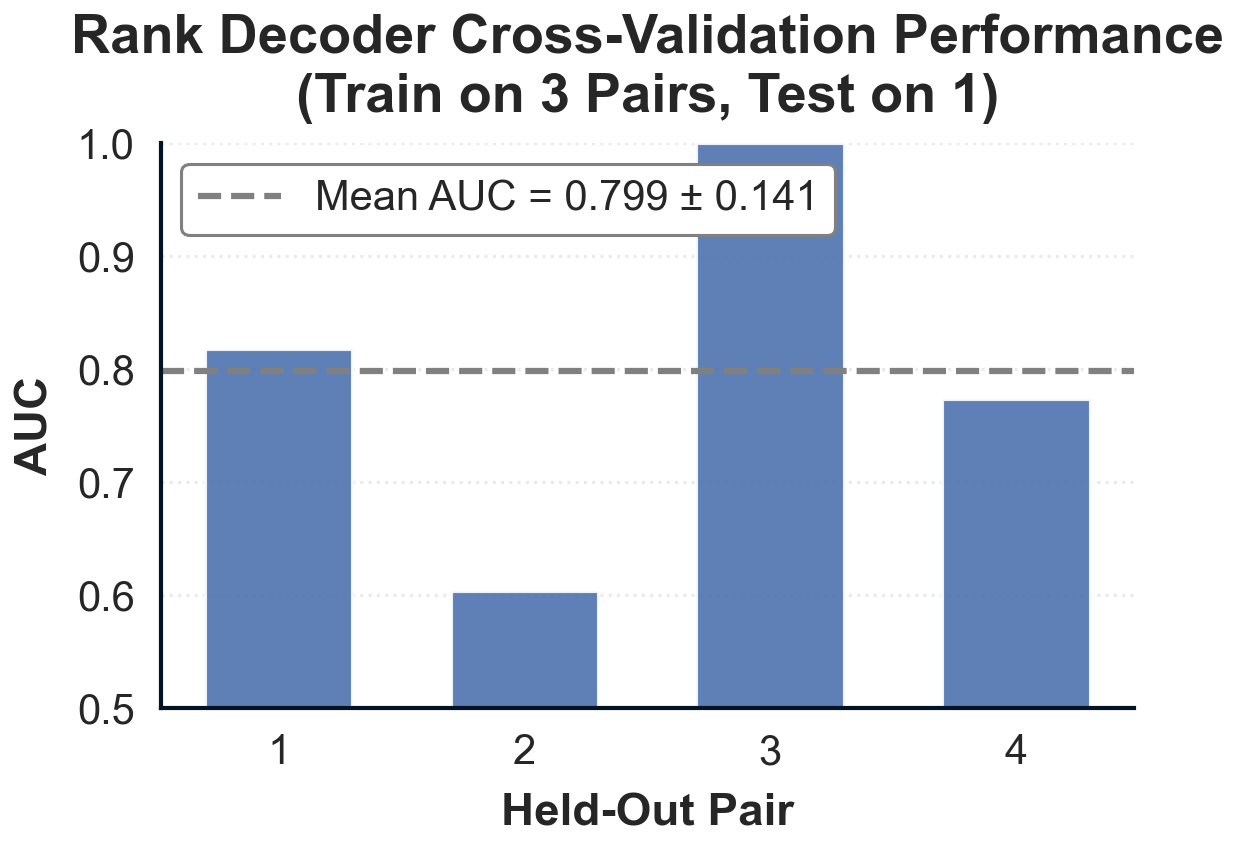

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# ==========================================================
# 1️⃣ Load & Prepare Data
# ==========================================================
df = master_df.copy()

# --- ΔRespiration relative to baseline ---
df["DeltaRate"] = df["MeanRate"] - df["SessionRate"]

# --- Keep only cagemate (CM) trials for Rank decoding ---
df_rank = df[df["Condition"] == "CM"].copy()

# --- Binary target: Dominant = 1, Subordinate = 0 ---
df_rank["RankLabel"] = (df_rank["Rank"] == "Dominant").astype(int)

# --- Define Dominant–Subordinate pairs manually ---
pair_map = {
    "1_1": 1, "1_2": 1,
    "2_3": 2, "2_4": 2,
    "3_5": 3, "3_6": 3,
    "4_7": 4, "4_8": 4
}
df_rank["Pair"] = df_rank["Subject"].map(pair_map)

# --- One-hot encode behavior category ---
beh_dummies = pd.get_dummies(df_rank["Behavior"], prefix="Beh", drop_first=True)

# Fill NaNs (missing behaviors) with 0 so we don’t lose respiration-only bouts
beh_dummies = beh_dummies.reindex(df_rank.index, fill_value=0)

X_base = pd.concat([
    df_rank[["MeanRate", "SessionRate", "DeltaRate", "Duration"]],
    beh_dummies
], axis=1)

print("Feature columns:", X_base.columns.tolist())

# ==========================================================
# 2️⃣  Clean Data (Handle Missing Values)
# ==========================================================
# If any residual NaNs remain (rare), fill with column mean
X_clean = X_base.fillna(X_base.mean())
y_clean = df_rank["RankLabel"].values
groups = df_rank["Pair"].values

print("Final feature shape:", X_clean.shape)
print("Unique pairs:", np.unique(groups))

# ==========================================================
# 3️⃣  Rank Decoder Model (Train on 3 pairs, Test on 1)
# ==========================================================
rank_clf = Pipeline([
    ("scale", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l1", solver="liblinear", max_iter=1000
    ))
])

cv = GroupKFold(n_splits=4)

auc_scores = []
valid_pairs = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X_clean, y_clean, groups)):
    y_test = y_clean[test_idx]
    if len(np.unique(y_test)) < 2:
        print(f"Skipping fold {fold+1} (only one class in test set)")
        continue
    
    X_train, X_test = X_clean.iloc[train_idx], X_clean.iloc[test_idx]
    y_train = y_clean[train_idx]
    
    rank_clf.fit(X_train, y_train)
    y_pred = rank_clf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred)
    auc_scores.append(auc)
    valid_pairs.append(np.unique(groups[test_idx])[0])

auc_scores = np.array(auc_scores)
mean_auc = auc_scores.mean()
std_auc = auc_scores.std()
print(f"Rank decoder AUC (train on 3 pairs, test on 1): {mean_auc:.3f} ± {std_auc:.3f}")

# ==========================================================
# 4️⃣  Poster-Ready Visualization
# ==========================================================
plt.figure(figsize=(8, 6))
bar_color = "#4C72B0"

plt.bar(valid_pairs, auc_scores, color=bar_color, width=0.6, alpha=0.9)
plt.axhline(mean_auc, color="gray", linestyle="--", linewidth=3,
            label=f"Mean AUC = {mean_auc:.3f} ± {std_auc:.3f}")

plt.xlabel("Held-Out Pair", fontsize=22, labelpad=10, weight='bold')
plt.ylabel("AUC", fontsize=22, labelpad=10, weight='bold')
plt.title("Rank Decoder Cross-Validation Performance\n(Train on 3 Pairs, Test on 1)",
          fontsize=26, pad=15, weight='bold')

plt.xticks(valid_pairs, fontsize=20)
plt.yticks(fontsize=20)
plt.ylim(0.5, 1.0)
plt.legend(fontsize=20, loc="upper left", frameon=True,
           facecolor="white", edgecolor="gray", framealpha=1, fancybox=True)
plt.grid(axis='y', linestyle=':', alpha=0.4)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

plt.tight_layout()
plt.show()


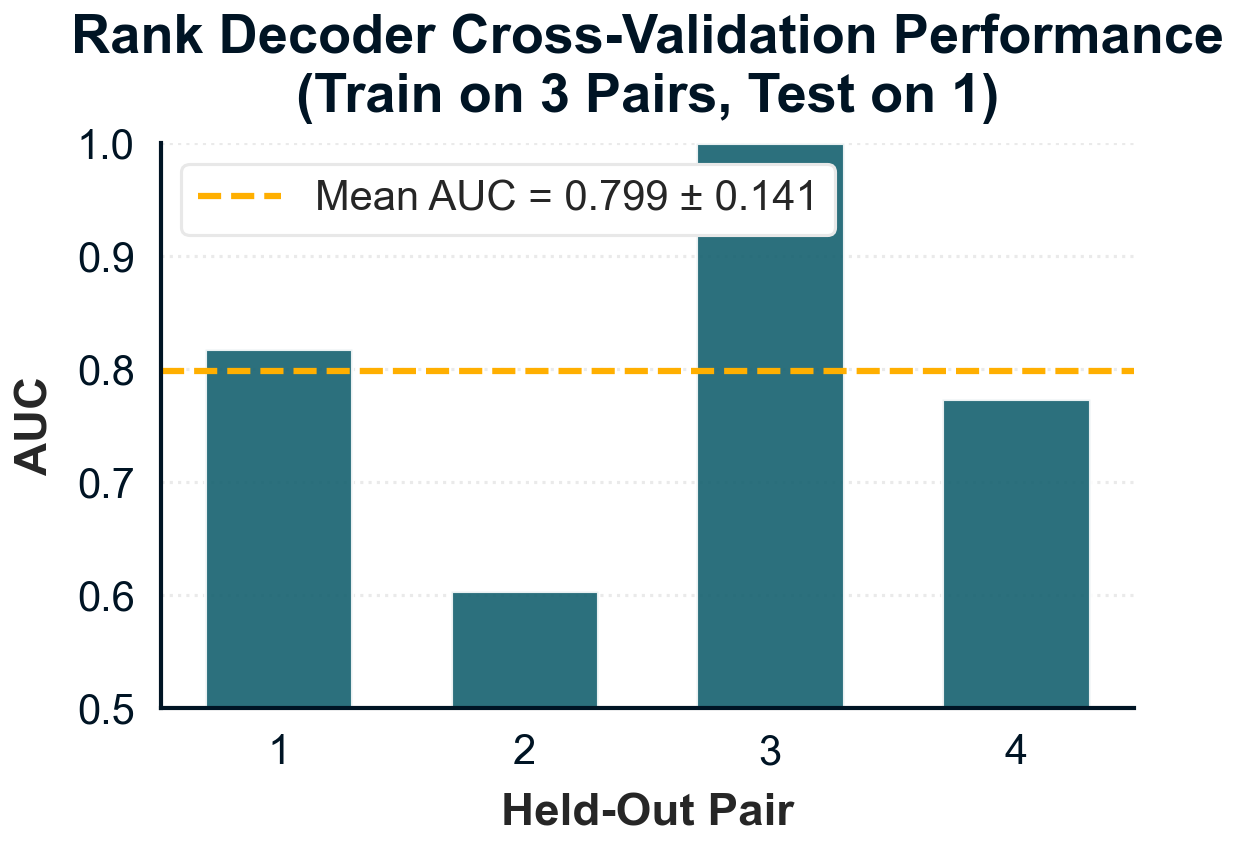

In [ ]:
# ==========================================================
# 4️⃣  Poster-Ready Visualization (Lab Colors)
# ==========================================================
plt.figure(figsize=(8, 6))

bar_color = "#15616F"   # Teal (Primary)
mean_line_color = "#FFAF00"  # Yellow (Accent)

plt.bar(valid_pairs, auc_scores, color=bar_color, width=0.6, alpha=0.9)
plt.axhline(mean_auc, color=mean_line_color, linestyle="--", linewidth=3,
            label=f"Mean AUC = {mean_auc:.3f} ± {std_auc:.3f}")

plt.xlabel("Held-Out Pair", fontsize=22, labelpad=10, weight='bold')
plt.ylabel("AUC", fontsize=22, labelpad=10, weight='bold')
plt.title("Rank Decoder Cross-Validation Performance\n(Train on 3 Pairs, Test on 1)",
          fontsize=26, pad=15, weight='bold', color="#001424")

plt.xticks(valid_pairs, fontsize=20, color="#001424")
plt.yticks(fontsize=20, color="#001424")
plt.ylim(0.5, 1.0)
plt.legend(fontsize=20, loc="upper left", frameon=True,
           facecolor="white", edgecolor="#E8E8E8", framealpha=1, fancybox=True)
plt.grid(axis='y', linestyle=':', alpha=0.4)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

plt.tight_layout()
plt.show()



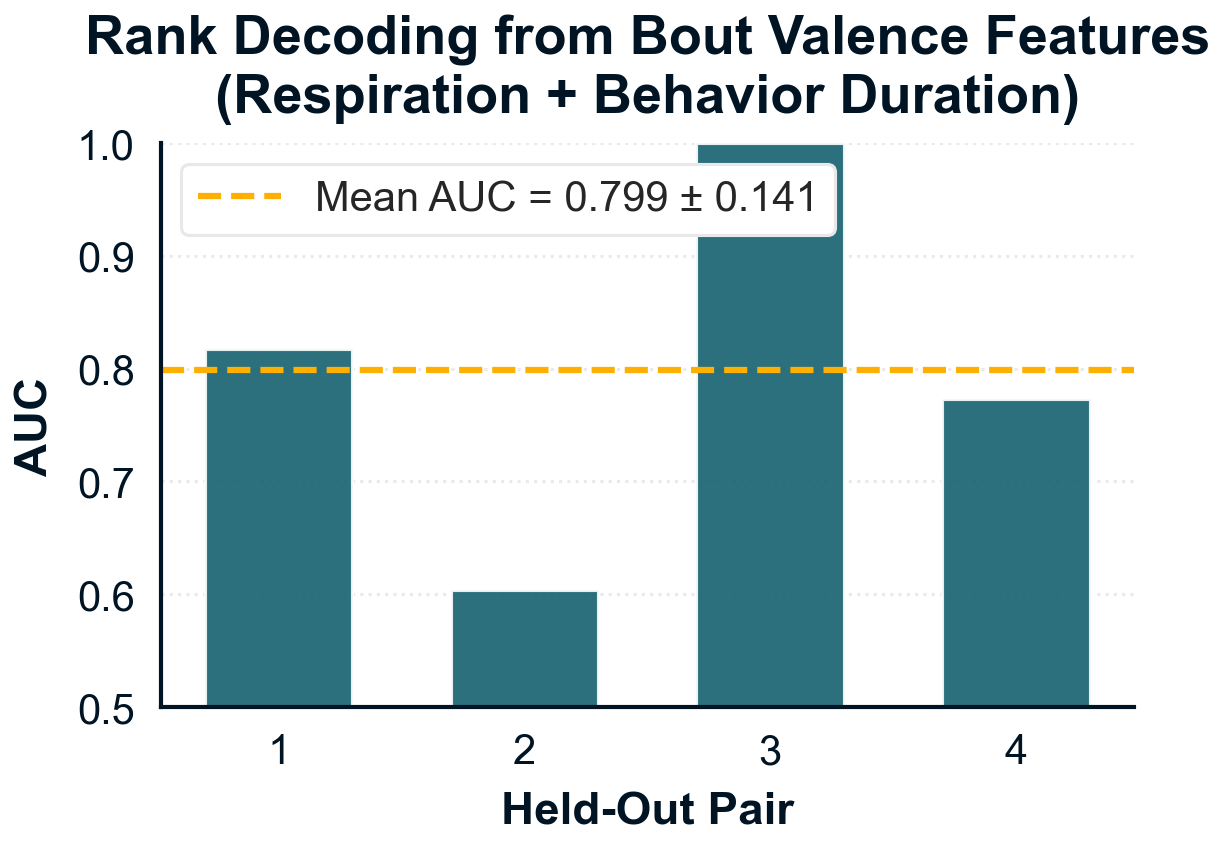

In [ ]:
# ==========================================================
# 4️⃣  Poster-Ready Visualization (Bout Valence Feature Decoder)
# ==========================================================
plt.figure(figsize=(8, 6))

# --- Lab Color Palette ---
bar_color = "#15616F"        # Teal (Primary)
mean_line_color = "#FFAF00"  # Yellow (Accent)
text_color = "#001424"       # Dark Navy (Text)

plt.bar(valid_pairs, auc_scores, color=bar_color, width=0.6, alpha=0.9)
plt.axhline(mean_auc, color=mean_line_color, linestyle="--", linewidth=3,
            label=f"Mean AUC = {mean_auc:.3f} ± {std_auc:.3f}")

# --- Titles and Labels ---
plt.xlabel("Held-Out Pair", fontsize=22, labelpad=10, weight='bold', color=text_color)
plt.ylabel("AUC", fontsize=22, labelpad=10, weight='bold', color=text_color)
plt.title(
    "Rank Decoding from Bout Valence Features\n"
    "(Respiration + Behavior Duration)", 
    fontsize=26, pad=15, weight='bold', color=text_color
)

# --- Axes and Layout ---
plt.xticks(valid_pairs, fontsize=20, color=text_color)
plt.yticks(fontsize=20, color=text_color)
plt.ylim(0.5, 1.0)
plt.legend(fontsize=20, loc="upper left", frameon=True,
           facecolor="white", edgecolor="#E8E8E8", framealpha=1, fancybox=True)
plt.grid(axis='y', linestyle=':', alpha=0.4)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

plt.tight_layout()
plt.show()


In [ ]:
# ==========================================================
# 5️⃣  Fit Final Model on All Data (for Coefficients)
# ==========================================================
rank_clf.fit(X_clean, y_clean)

# --- Get the logistic regression step ---
logreg = rank_clf.named_steps["logreg"]

# --- Retrieve coefficients and feature names ---
coef = logreg.coef_.flatten()
features = X_clean.columns

coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": coef
}).sort_values("Coefficient", ascending=False)

print("\n=== Logistic Regression Coefficients (All Data) ===")
print(coef_df.to_string(index=False, float_format="%.3f"))



=== Logistic Regression Coefficients (All Data) ===
            Feature  Coefficient
          DeltaRate        0.551
Beh_facial sniffing        0.283
           MeanRate        0.000
           Duration       -0.078
  Beh_body sniffing       -0.146
        SessionRate       -0.784



=== Logistic Regression Coefficients (SessionRate, ΔRate, Duration) ===
    Feature  Coefficient
  DeltaRate        0.527
   Duration       -0.096
SessionRate       -0.803


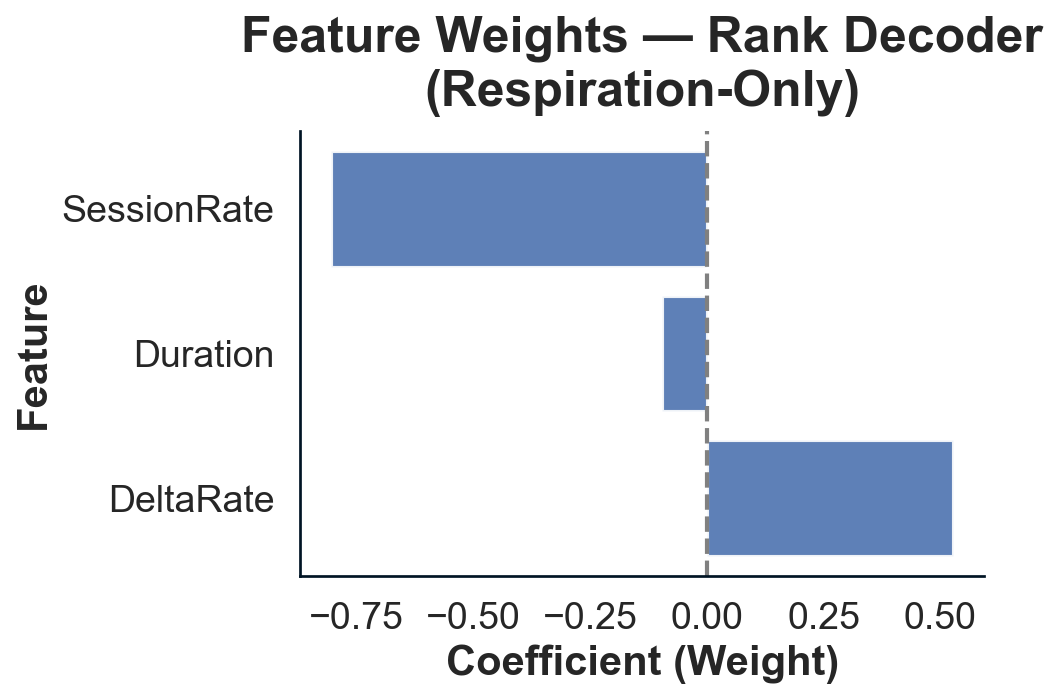

In [ ]:
# ==========================================================
# 5️⃣  Fit Final Model on All Data (Respiration Features Only, No MeanRate)
# ==========================================================
# Keep only respiration features: SessionRate, DeltaRate, Duration
resp_features = ["SessionRate", "DeltaRate", "Duration"]
X_resp = X_clean[resp_features]

# Refit the same pipeline on all bouts
rank_clf.fit(X_resp, y_clean)

# Extract logistic regression component
logreg = rank_clf.named_steps["logreg"]

# Get coefficients and feature names
coef = logreg.coef_.flatten()
features = X_resp.columns

coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": coef
}).sort_values("Coefficient", ascending=False)

print("\n=== Logistic Regression Coefficients (SessionRate, ΔRate, Duration) ===")
print(coef_df.to_string(index=False, float_format="%.3f"))

# ==========================================================
# 6️⃣  Poster-Ready Coefficient Plot
# ==========================================================
plt.figure(figsize=(7, 5))
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color="#4C72B0", alpha=0.9)
plt.axvline(0, color="gray", linestyle="--", linewidth=2)
plt.xlabel("Coefficient (Weight)", fontsize=20, weight='bold')
plt.ylabel("Feature", fontsize=20, weight='bold')
plt.title("Feature Weights — Rank Decoder\n(Respiration-Only)",
          fontsize=24, pad=12, weight='bold')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()


In [ ]:
print(df_rank.groupby(["Pair", "Rank"])["Subject"].nunique())


Pair  Rank       
1     Dominant       1
      Subordinate    1
2     Dominant       1
      Subordinate    1
3     Dominant       1
      Subordinate    1
4     Dominant       1
      Subordinate    1
Name: Subject, dtype: int64


In [ ]:
from sklearn.model_selection import GroupKFold

# --- Define groups as subjects ---
groups = df_rank.loc[X_clean.index, "Subject"].values

# --- Group-level CV (each subject entirely in one fold) ---
cv = GroupKFold(n_splits=5)

rank_scores = cross_val_score(
    rank_clf, X_clean.values, y_clean.values,
    cv=cv, groups=groups, scoring="roc_auc"
)

mean_auc = rank_scores.mean()
std_auc = rank_scores.std()
print(f"Rank decoder AUC (subject-level CV): {mean_auc:.3f} ± {std_auc:.3f}")


Rank decoder AUC (subject-level CV): nan ± nan


c:\Users\sjs93\anaconda3\envs\biopipeline-env\lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\sjs93\anaconda3\envs\biopipeline-env\lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\sjs93\anaconda3\envs\biopipeline-env\lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\sjs93\anaconda3\envs\biopipeline-env\lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\sjs93\anaconda3\envs\biopipeline-env\lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only on

Line by line:

rank_clf.fit(X_rank, y_rank)

Trains your logistic regression pipeline (scaler + L1 logistic regression) on all data.

After training, the model learns a weight (coefficient) for each feature that helps it predict Dominant (1) vs Subordinate (0).

rank_clf.named_steps["logreg"].coef_[0]

Extracts the learned coefficients (weights) from the logistic regression layer inside your pipeline.

The for loop

Pairs each column name with its weight.

Prints them in a tidy table for you to interpret.

In [ ]:
rank_clf.fit(X_rank, y_rank)
coef = rank_clf.named_steps["logreg"].coef_[0]
for name, w in zip(X_base.columns, coef):
    print(f"{name:20s}  {w:+.3f}")


MeanRate              +0.031
SessionRate           +0.392
DeltaRate             +0.000
Duration              -0.392
Beh_body sniffing     +0.129
Beh_facial sniffing   +0.126


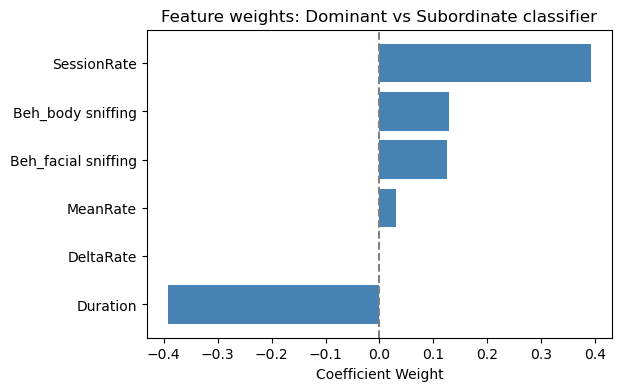

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

coef_df = pd.DataFrame({
    "Feature": X_base.columns,
    "Weight": coef
}).sort_values("Weight", ascending=False)

plt.figure(figsize=(6, 4))
plt.barh(coef_df["Feature"], coef_df["Weight"], color="steelblue")
plt.axvline(0, color="gray", linestyle="--")
plt.xlabel("Coefficient Weight")
plt.title("Feature weights: Dominant vs Subordinate classifier")
plt.gca().invert_yaxis()
plt.show()


In [ ]:
# Drop the redundant DeltaRate column
X_refit = X_base.drop(columns=["DeltaRate"])
y_refit = df["RankLabel"]

# Refit the pipeline
rank_clf.fit(X_refit, y_refit)

# Extract and print new coefficients
coef = rank_clf.named_steps["logreg"].coef_[0]
for name, w in zip(X_refit.columns, coef):
    print(f"{name:20s}  {w:+.3f}")


MeanRate              +0.031
SessionRate           +0.392
Duration              -0.392
Beh_body sniffing     +0.129
Beh_facial sniffing   +0.126


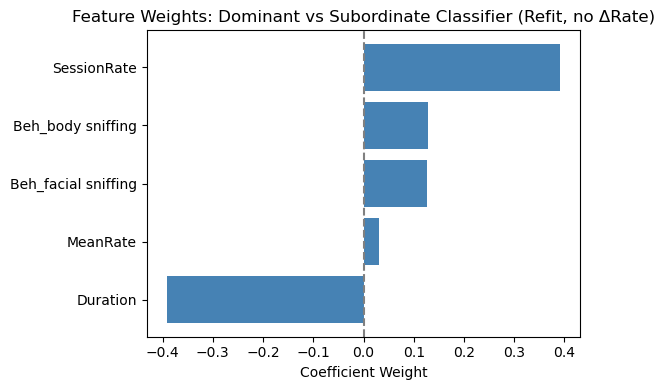

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Build DataFrame for coefficients ---
coef_df = pd.DataFrame({
    "Feature": X_refit.columns,
    "Weight": coef
}).sort_values("Weight", ascending=False)

# --- Plot setup ---
plt.figure(figsize=(6, 4))
plt.barh(coef_df["Feature"], coef_df["Weight"], color="steelblue")
plt.axvline(0, color="gray", linestyle="--")
plt.xlabel("Coefficient Weight")
plt.title("Feature Weights: Dominant vs Subordinate Classifier (Refit, no ΔRate)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rank_scores_refit = cross_val_score(rank_clf, X_refit, y_refit, cv=cv, scoring="roc_auc")

print("Rank decoder AUC (no DeltaRate):", rank_scores_refit.mean(), "+/-", rank_scores_refit.std())


Rank decoder AUC (no DeltaRate): 0.6687189534551067 +/- 0.02474156730555538


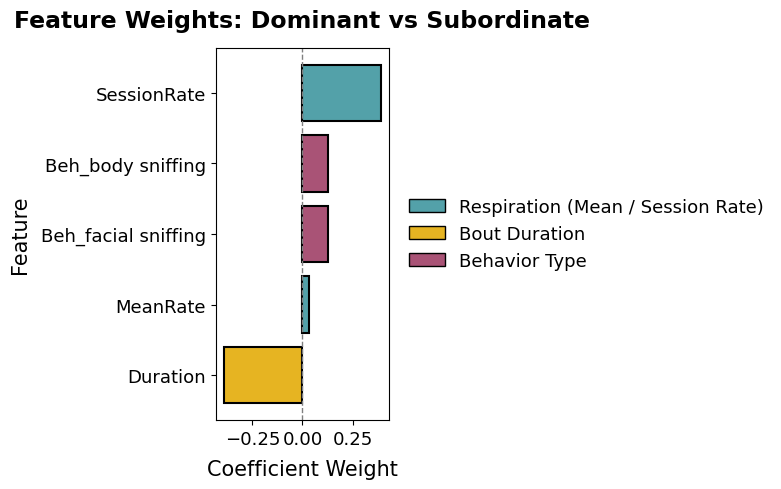

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- Build DataFrame for coefficients ---
coef_df = pd.DataFrame({
    "Feature": X_refit.columns,
    "Weight": coef
}).sort_values("Weight", ascending=False)

# --- Lab colors ---
feature_colors = []
for feat in coef_df["Feature"]:
    if "Rate" in feat:
        feature_colors.append("#53A1A9")     # teal for respiration
    elif "Duration" in feat:
        feature_colors.append("#E6B422")     # mustard for duration
    elif "Beh" in feat:
        feature_colors.append("#A95376")     # magenta for behavior
    else:
        feature_colors.append("gray")

# --- Create plot ---
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(coef_df["Feature"], coef_df["Weight"],
               color=feature_colors, edgecolor="black", linewidth=1.5)

# --- Axes + title styling ---
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Coefficient Weight", fontsize=15, labelpad=8)
ax.set_ylabel("Feature", fontsize=15, labelpad=8)
ax.set_title("Feature Weights: Dominant vs Subordinate",
             fontsize=17, weight="bold", pad=15)
ax.tick_params(axis='both', which='major', labelsize=13)
ax.invert_yaxis()

# --- Legend (outside, larger text) ---
legend_elements = [
    Patch(facecolor="#53A1A9", edgecolor="black", label="Respiration (Mean / Session Rate)"),
    Patch(facecolor="#E6B422", edgecolor="black", label="Bout Duration"),
    Patch(facecolor="#A95376", edgecolor="black", label="Behavior Type"),
]
ax.legend(handles=legend_elements,
          frameon=False,
          loc="center left",
          bbox_to_anchor=(1.02, 0.5),
          fontsize=13)

plt.tight_layout()
plt.show()


In [ ]:
# Add a Valence column if it doesn't exist
if "Valence" not in df.columns:
    df["Valence"] = df["Condition"].replace({"RI1": "Positive", "RI2": "Negative"})


In [ ]:
# keep only valenced encounters
df_val = df[df["Valence"].isin(["Positive", "Negative"])].copy()

df_val["ValenceLabel"] = (df_val["Valence"] == "Positive").astype(int)

X_val = pd.concat([
    df_val[["MeanRate", "SessionRate", "DeltaRate", "Duration"]],
    pd.get_dummies(df_val["Behavior"], prefix="Beh", drop_first=True)
], axis=1).values

y_val = df_val["ValenceLabel"].values

val_clf = Pipeline([
    ("scale", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l1", solver="liblinear", max_iter=1000
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
val_scores = cross_val_score(val_clf, X_val, y_val, cv=cv, scoring="roc_auc")
print("Valence decoder AUC (5-fold CV):", val_scores.mean(), "+/-", val_scores.std())


Valence decoder AUC (5-fold CV): 1.0 +/- 0.0


In [ ]:
print(X_val.shape)
print(df_val.columns)


(614, 6)
Index(['Behavior', 'Subject', 'Start', 'Stop', 'Duration', 'MeanRate', 'Trial', 'Condition', 'Rank', 'SessionRate', 'DeltaRate', 'RankLabel', 'Valence', 'ValenceLabel'], dtype='object')


In [ ]:
X_columns = list(pd.concat([
    df_val[["MeanRate", "SessionRate", "DeltaRate", "Duration"]],
    pd.get_dummies(df_val["Behavior"], prefix="Beh", drop_first=True)
], axis=1).columns)

print(X_columns)


['MeanRate', 'SessionRate', 'DeltaRate', 'Duration', 'Beh_body sniffing', 'Beh_facial sniffing']


In [ ]:
print(df.columns.tolist())


['Behavior', 'Subject', 'Start', 'Stop', 'Duration', 'MeanRate', 'Trial', 'Condition', 'Rank', 'SessionRate', 'DeltaRate', 'RankLabel']


In [ ]:
subjects = df["Subject"].unique()
auc_per_subject = []

for heldout in subjects:
    train_mask = df["Subject"] != heldout
    test_mask  = df["Subject"] == heldout

    # skip subjects with too few bouts to test
    if test_mask.sum() < 5 or train_mask.sum() < 5:
        continue

    X_train = X_base.loc[train_mask].values
    y_train = df.loc[train_mask, "RankLabel"].values
    X_test  = X_base.loc[test_mask].values
    y_test  = df.loc[test_mask, "RankLabel"].values

    clf = Pipeline([
        ("scale", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l1", solver="liblinear", max_iter=1000
        ))
    ])
    clf.fit(X_train, y_train)

    # predict on held-out animal
    y_score = clf.predict_proba(X_test)[:,1]

    # compute AUC for that held-out animal
    from sklearn.metrics import roc_auc_score
    auc = roc_auc_score(y_test, y_score)
    auc_per_subject.append(auc)
    print(f"Held out {heldout}: AUC={auc:.3f}")

print("Across-subject AUC mean:", np.mean(auc_per_subject), "+/-", np.std(auc_per_subject))


Held out 3_6: AUC=nan
Held out 4_7: AUC=nan
Held out 2_3: AUC=nan
Held out 4_8: AUC=nan
Held out 1_1: AUC=nan
Held out 1_2: AUC=nan
Held out 2_4: AUC=nan
Across-subject AUC mean: nan +/- nan


c:\Users\sjs93\anaconda3\envs\biopipeline-env\lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\sjs93\anaconda3\envs\biopipeline-env\lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\sjs93\anaconda3\envs\biopipeline-env\lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\sjs93\anaconda3\envs\biopipeline-env\lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\sjs93\anaconda3\envs\biopipeline-env\lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only on

In [ ]:
# Keep only sessions that have a valid Rank label (Dominant/Subordinate)
rank_sessions = session_df.dropna(subset=["Rank"]).copy()

# Check what’s included
print(rank_sessions["Condition"].value_counts())
print(rank_sessions["Rank"].value_counts())


Condition
CM      8
RI1     8
BLRI    7
RI2     7
Name: count, dtype: int64
Rank
Subordinate    15
Dominant       15
Name: count, dtype: int64


In [ ]:
# Keep only known-rank sessions with valid respiration metrics
rank_all_df = session_df.dropna(subset=["Rank", "SessionRate_mean", "DeltaRate_mean"]).copy()

# Binary label
rank_all_df["RankLabel"] = (rank_all_df["Rank"] == "Dominant").astype(int)

# Define high-level context grouping
rank_all_df["SocialContext"] = rank_all_df["Condition"].replace({
    "RI1": "Positive",
    "RI2": "Negative",
    "CM": "Cagemate",
    "BLRI": "Baseline"
})

print(rank_all_df.groupby(["SocialContext", "Rank"]).size())


SocialContext  Rank       
Cagemate       Dominant       3
               Subordinate    4
Negative       Dominant       3
               Subordinate    4
Positive       Dominant       4
               Subordinate    3
dtype: int64


In [ ]:
print(rank_sessions.groupby(["Subject", "Rank"])["Condition"].count())


Subject  Rank       
1_1      Subordinate    4
1_2      Dominant       4
2_3      Subordinate    4
2_4      Dominant       4
3_5      Subordinate    3
3_6      Dominant       4
4_7      Subordinate    4
4_8      Dominant       3
Name: Condition, dtype: int64


In [ ]:
# Check which conditions are missing for each subject
subjects = ["1_1","1_2","2_3","2_4","3_5","3_6","4_7","4_8"]

for subj in subjects:
    subj_df = session_df[session_df["Subject"] == subj]
    print(f"\n{subj} ({subj_df['Rank'].iloc[0]}): {list(subj_df['Condition'].unique())}")



1_1 (Subordinate): ['BLRI', 'CM', 'RI1', 'RI2']

1_2 (Dominant): ['BLRI', 'CM', 'RI1', 'RI2']

2_3 (Subordinate): ['BLRI', 'CM', 'RI1', 'RI2']

2_4 (Dominant): ['BLRI', 'CM', 'RI1', 'RI2']

3_5 (Subordinate): ['CM', 'RI1', 'RI2']

3_6 (Dominant): ['BLRI', 'CM', 'RI1', 'RI2']

4_7 (Subordinate): ['BLRI', 'CM', 'RI1', 'RI2']

4_8 (Dominant): ['BLRI', 'CM', 'RI1']


In [ ]:
for key in resp_paths.keys():
    if "3_5" in key or "4_8" in key:
        print(key)


RI1_4_8
RI2_4_8
RI1_3_5
RI2_3_5
BLRI_4_8
